# 초능력자 봇 A100 파라미터 실험실 v3.6

## v3.5 전체 변수 유지 + 차원압축 탐색 비교

이 노트북은 v3.5의 변수 체계(힌트, 콤보, 주유물/보관함, 정밀 배틀)를 그대로 유지하면서, 아래 분석을 추가합니다.

- 전체 변수 직접 탐색 결과 진단
- 민감도 분석
- 그룹별 PCA
- PLS 기반 supervised 차원압축
- surrogate 기반 active-subspace/중요 변수 축소 탐색
- `전체 변수 탐색` vs `차원압축 탐색` 성능 비교
- 최종 후보를 다시 원래 게임 파라미터로 복원

중요: 차원압축은 최종 적용값이 아니라 탐색/진단 도구입니다. 최종 개발자 전달값은 항상 원래 파라미터 이름으로 복원됩니다.


In [1]:
# ================================================================
# 0. 기본 설정
# ================================================================

import os, re, math, json, time, warnings, gc
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    import torch
except Exception as e:
    raise RuntimeError("PyTorch가 필요합니다. Colab 런타임을 GPU로 설정해주세요.") from e

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.set_float32_matmul_precision("high")

# ------------------------------------------------
# 실행 규모
# ------------------------------------------------
# QUICK_MODE=True: 작동 확인용
# QUICK_MODE=False: A100 본실험용

QUICK_MODE = False

if QUICK_MODE:
    STAGE1_N_PARAM = 512
    STAGE2_N_PARAM = 1024
    STAGE3_TOP_N = 50
    STAGE1_R_MC = 2
    STAGE2_R_MC = 2
    STAGE3_R_MC = 8
    STAGE1_BATCH_SIZE = 128
    STAGE2_BATCH_SIZE = 128
    STAGE3_BATCH_SIZE = 32
    T_DAYS = 60
else:
    STAGE1_N_PARAM = 65536
    STAGE2_N_PARAM = 131072
    STAGE3_TOP_N = 500
    STAGE1_R_MC = 4
    STAGE2_R_MC = 4
    STAGE3_R_MC = 64
    STAGE1_BATCH_SIZE = 512      # v3.5는 인벤토리+배틀 근사가 추가되어 384~512 권장
    STAGE2_BATCH_SIZE = 512
    STAGE3_BATCH_SIZE = 64
    T_DAYS = 180

OUT_DIR = Path("/content/chaoneung_param_lab_v35_battle_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("OUT_DIR:", OUT_DIR)

# 대량 실행 중 중간 저장
SAVE_EVERY_BATCH = True
KEEP_TOP_K = 5000

# 목표 제약
TARGET_D20_MIN = 250_000
TARGET_D20_MAX = 2_000_000
TARGET_LATE_SHARE_MAX = 0.70

TARGET_REACH_D5 = 0.42
TARGET_REACH_D10 = 0.13
MAX_REACH_D15 = 0.035
MAX_REACH_D20 = 0.001

MAX_HAS_A = 0.025
MAX_HAS_S = 0.001

TARGET_SINK = 0.76
MAX_P99_P50 = 7.0

# 보관/비용감소 안전 상한
MAX_STORAGE_RATIO_EFF = 0.65
MAX_COST_REDUCE = 0.30
MAX_REWARD_BONUS = 0.80

# 배틀 기본 운영 규칙
BATTLE_DAILY_LIMIT = 15
MAX_BATTLE_P99_GAIN_RATIO = 0.45
MAX_BATTLE_P99_LOSS_RATIO = 0.35

print({
    "STAGE1_N_PARAM": STAGE1_N_PARAM,
    "STAGE2_N_PARAM": STAGE2_N_PARAM,
    "STAGE3_TOP_N": STAGE3_TOP_N,
    "T_DAYS": T_DAYS,
})

DEVICE: cuda
GPU: NVIDIA A100-SXM4-40GB
OUT_DIR: /content/chaoneung_param_lab_v35_battle_outputs
{'STAGE1_N_PARAM': 65536, 'STAGE2_N_PARAM': 131072, 'STAGE3_TOP_N': 500, 'T_DAYS': 180}


In [2]:
# ================================================================
# 1. 전체 데이터 덤프 로드
# ================================================================

TXT_PATH = Path("/content/초능력자봇_전체데이터_ML용.txt")

if not TXT_PATH.exists():
    txt_files = list(Path("/content").glob("*.txt"))
    if len(txt_files) == 0:
        raise FileNotFoundError("초능력자봇 전체 데이터 TXT 파일을 /content에 업로드해주세요.")
    TXT_PATH = txt_files[0]

raw_text = TXT_PATH.read_text(encoding="utf-8", errors="ignore")
print("loaded:", TXT_PATH)
print("text length:", len(raw_text))

loaded: /content/초능력자봇_전체데이터_ML용.txt
text length: 210896


In [3]:
# ================================================================
# 2. Production 유저 데이터 파싱 + synthetic tail + 세그먼트
# ================================================================

def parse_int_from_pattern(pattern, text, default=None):
    m = re.search(pattern, text)
    if not m:
        return default
    return int(m.group(1).replace(",", ""))

reported_total_users = parse_int_from_pattern(r"total_users:\s*([0-9,]+)", raw_text, 6945)
reported_active_users = parse_int_from_pattern(r"active_users\s*\(total>0\):\s*([0-9,]+)", raw_text, 4690)
reported_total_correct = parse_int_from_pattern(r"total_correct:\s*([0-9,]+)", raw_text, 57073)
reported_total_played = parse_int_from_pattern(r"total_played:\s*([0-9,]+)", raw_text, 169928)

print("reported:", reported_total_users, reported_active_users, reported_total_correct, reported_total_played)

ranking_pattern = re.compile(
    r"^([^,\n]+),\s*([0-9]+),\s*([0-9]+),\s*([0-9]+),\s*([0-9.]+),\s*([^\n\r]+)$",
    re.MULTILINE
)

rows = []
for m in ranking_pattern.finditer(raw_text):
    nickname = m.group(1).strip()
    if nickname.lower() in ["nickname", "user_id"]:
        continue
    if not nickname.startswith("능력자") and "운영진" not in nickname and "부운영진" not in nickname:
        continue
    rows.append(dict(
        nickname=nickname,
        score=int(m.group(2)),
        correct=int(m.group(3)),
        total=int(m.group(4)),
        accuracy=float(m.group(5)),
        last_attendance=m.group(6).strip(),
        source="parsed",
    ))

users = pd.DataFrame(rows)
if users.empty:
    raise ValueError("랭킹 유저 데이터를 파싱하지 못했습니다. TXT 형식을 확인해주세요.")

# ------------------------------------------------
# synthetic tail: TXT가 잘려 일부 유저만 파싱된 경우 보정
# ------------------------------------------------
n_missing = max(0, reported_total_users - len(users))

if n_missing > 0:
    print(f"synthetic tail 생성: {n_missing}명")
    rng = np.random.default_rng(42)

    bins = np.array([0, 100, 500, 1000, 5000, 10000, 50000, 100000, 160824], dtype=float)
    counts = np.array([3706, 1851, 603, 620, 97, 64, 3, 1], dtype=float)
    probs = counts / counts.sum()

    sampled_bins = rng.choice(len(counts), size=n_missing, p=probs)
    scores = np.zeros(n_missing)

    for b in range(len(counts)):
        idxb = sampled_bins == b
        lo, hi = bins[b], bins[b + 1]
        if idxb.sum() == 0:
            continue
        if hi > 5000:
            scores[idxb] = np.exp(rng.uniform(np.log(max(lo, 1)), np.log(hi), idxb.sum()))
        else:
            scores[idxb] = rng.uniform(lo, hi, idxb.sum())

    scores = np.round(scores).astype(int)
    correct = np.maximum(0, rng.poisson(lam=np.clip(scores / 75, 0.05, 80))).astype(int)
    total = correct + rng.poisson(lam=np.clip(correct * 2.0 + 1, 1, 160)).astype(int)
    total = np.maximum(total, correct)
    accuracy = np.where(total > 0, correct / np.maximum(total, 1) * 100, 0)

    last_options = np.array(["없음", "2026-05-01", "2026-05-02", "2026-05-03", "2026-05-04", "2026-05-05"])
    last_probs = np.array([0.62, 0.05, 0.07, 0.08, 0.12, 0.06])
    last_attendance = rng.choice(last_options, size=n_missing, p=last_probs)

    synth = pd.DataFrame(dict(
        nickname=[f"synthetic_{i:05d}" for i in range(n_missing)],
        score=scores,
        correct=correct,
        total=total,
        accuracy=accuracy,
        last_attendance=last_attendance,
        source="synthetic_tail",
    ))
    users = pd.concat([users, synth], ignore_index=True)
else:
    print("synthetic tail 생성 없음")

# ------------------------------------------------
# 파생변수
# ------------------------------------------------
for col in ["score", "correct", "total", "accuracy"]:
    users[col] = pd.to_numeric(users[col], errors="coerce").fillna(0.0).astype(float)

users["accuracy_frac"] = np.where(users["accuracy"] > 1, users["accuracy"] / 100.0, users["accuracy"])
users["accuracy_frac"] = users["accuracy_frac"].clip(0, 1)
users["is_active"] = users["total"] > 0
users["recent_active"] = users["last_attendance"].astype(str).str.contains("2026-05-0[3-5]", regex=True).astype(int)
users["log_score"] = np.log1p(users["score"])
users["log_correct"] = np.log1p(users["correct"])
users["log_total"] = np.log1p(users["total"])

def robust_rank(s):
    return s.rank(pct=True, method="average").fillna(0.0)

activity_score = (
    0.35 * robust_rank(users["log_score"])
    + 0.35 * robust_rank(users["log_correct"])
    + 0.15 * robust_rank(users["accuracy_frac"])
    + 0.15 * users["recent_active"]
)
users["activity_score"] = activity_score

users["segment"] = pd.cut(
    users["activity_score"],
    bins=[-0.001, 0.40, 0.75, 0.95, 0.99, 1.001],
    labels=["low", "mid", "high", "whale", "ultra"],
)
users["segment"] = users["segment"].astype("object")
users.loc[~users["is_active"], "segment"] = "inactive"
users["segment"] = users["segment"].fillna("inactive").astype(str)

SEGMENT_ID_MAP = {"inactive":0, "low":1, "mid":2, "high":3, "whale":4, "ultra":5}
users["segment_id"] = users["segment"].map(SEGMENT_ID_MAP).fillna(2).astype(int)

SEGMENT_SPEND_MAP = {"inactive":0.03, "low":0.12, "mid":0.30, "high":0.55, "whale":0.70, "ultra":0.75}
users["base_spend_prop"] = users["segment"].map(SEGMENT_SPEND_MAP).fillna(0.25).astype(float)

base_daily_correct_np = (
    0.03
    + 0.012 * np.log1p(users["correct"].to_numpy(float))
    + 0.045 * users["recent_active"].to_numpy(float)
    + 0.035 * users["accuracy_frac"].to_numpy(float)
)
base_daily_correct_np = np.clip(base_daily_correct_np, 0.01, 3.0).astype(np.float32)
users["base_daily_correct"] = base_daily_correct_np

users = users.sort_values(["score", "correct"], ascending=False).reset_index(drop=True)
users.to_csv(OUT_DIR/"parsed_users_segments_v34.csv", index=False, encoding="utf-8-sig")

print("users:", len(users))
display(users["segment"].value_counts().reset_index())
display(users.head(20))

reported: 6945 4690 57073 169928
synthetic tail 생성: 2240명
users: 6945


,segment,count
0,mid,3170
1,low,2704
2,high,773
3,inactive,227
4,whale,65
5,ultra,6


,nickname,score,correct,total,accuracy,last_attendance,source,accuracy_frac,is_active,recent_active,log_score,log_correct,log_total,activity_score,segment,segment_id,base_spend_prop,base_daily_correct
0,운영진_f26fe5,830492301.0,91.0,144.0,63.200000,"4,14,12,1,2026-05-03,빛의 성배,2,17,117,79,14,1,1,0",parsed,0.632000,True,1,20.537529,4.521789,4.976734,0.983179,whale,4,0.70,0.151381
1,능력자_ea4997,160824.0,3161.0,3230.0,97.900000,2026-05-01,parsed,0.979000,True,0,11.988072,8.058960,8.080547,0.844399,high,3,0.55,0.160973
2,능력자_e35997,99340.0,165.0,165.0,100.000000,"1,8,10,0,2026-04-27,별자리 나침반,2,9,289,155,59,3,1,2",parsed,1.000000,True,0,11.506314,5.111988,5.111988,0.844626,high,3,0.55,0.126344
3,synthetic_02210,97951.0,89.0,232.0,38.362069,2026-05-03,synthetic_tail,0.383621,True,1,11.492233,4.499810,5.451038,0.959766,whale,4,0.70,0.142424
4,능력자_d5dcad,75403.0,988.0,1688.0,58.500000,2026-05-03,parsed,0.585000,True,1,11.230616,6.896694,7.431892,0.987700,whale,4,0.70,0.178235
5,능력자_66a071,61145.0,1165.0,1288.0,90.500000,2026-05-04,parsed,0.905000,True,1,11.021020,7.061334,7.161622,0.994071,ultra,5,0.75,0.191411
6,부운영진_6a1c4c,53397.0,948.0,1039.0,91.200000,2026-05-04,parsed,0.912000,True,1,10.885529,6.855409,6.946976,0.993902,ultra,5,0.75,0.189185
7,synthetic_01383,49352.0,73.0,199.0,36.683417,없음,synthetic_tail,0.366834,True,0,10.806754,4.304065,5.298317,0.802898,high,3,0.55,0.094488
8,synthetic_00177,47925.0,85.0,242.0,35.123967,없음,synthetic_tail,0.351240,True,0,10.777413,4.454347,5.493061,0.802833,high,3,0.55,0.095746
9,synthetic_01108,47594.0,86.0,243.0,35.390947,없음,synthetic_tail,0.353909,True,0,10.770483,4.465908,5.497168,0.803614,high,3,0.55,0.095978


In [4]:
# ================================================================
# 3. 기준 파라미터와 유물/효과 타입 정의
# ================================================================

BASE = dict(
    base_effect=np.array([0.022,0.044,0.087,0.164,0.273],float),
    level_bonus=0.05,
    enhance_bonus=0.03,
    level_cost_factor=157.0,
    enhance_base=800.0,
    enhance_growth=1.4696,
    success=np.array([95,93,88,82,77,71,66,60,55,49,44,38,33,27,22,16,11,9,5,3],float)/100,
    inv_expand_cost=5000.0,
    inv_max=30,
    inv_base=8,
    refund=np.array([500,2000,8000,30000,100000],float),
    fuse_cost=np.array([1400,4300,14300,57300],float),
    drop=np.array([0.02608,0.01279,0.00237,0.000074,0.0],float),
    fuse_success_scale=0.902,
    storage_ratio=0.3,
    storage_stack_max=3,
    chosung_random=1000.0,
    chosung_category=500.0,
    wrong_min=50.0,
    wrong_max=110.0,
    combo_multiplier=1.2,
    hunmin_word=100.0,
    hunmin_mvp=1000.0,
    jamo_easy=800.0,
    jamo_normal=1200.0,
    jamo_hard=1800.0,
    bonus_long=300.0,
    bonus_jong=200.0,
    bonus_first=500.0,
    bonus_streak3=1000.0,
)

# 효과 타입 집계 근사:
# 실제 type_id 1~10을 전부 개별 추적하면 메모리가 커지므로,
# 경제적으로 중요한 효과 타입 7개로 집계한다.
EFFECT_NAMES = [
    "all_bonus",            # 모든 게임 포인트 +
    "enhance_cost_reduce",  # 강화 비용 -
    "chosung_bonus",        # 초성 +
    "hunmin_bonus",         # 훈민 +
    "jamo_bonus",           # 자모 +
    "combo_bonus",          # 콤보 +
    "storage_bonus",        # 보관 효과 +
]
EFFECT_DIM = len(EFFECT_NAMES)
EFFECT_INDEX = {name:i for i,name in enumerate(EFFECT_NAMES)}

GRADE_NAMES = ["D","C","B","A","S"]

def enhance_ev_np(grade=1, H=20, base=None, growth=None, success=None, cost_reduce=0.0):
    base = BASE["enhance_base"] if base is None else base
    growth = BASE["enhance_growth"] if growth is None else growth
    success = BASE["success"] if success is None else np.asarray(success)
    steps = []
    for h in range(H):
        c = math.floor(grade * base * (growth ** h)) * (1-cost_reduce)
        steps.append(c / max(float(success[h]), 1e-9))
    return float(np.sum(steps)), np.array(steps, dtype=float)

def level_cost_np(grade=1, L=30, factor=None):
    factor = BASE["level_cost_factor"] if factor is None else factor
    return float(sum(grade*factor*l for l in range(1,L)))

def effect_value_np(grade=1, level=1, enh=0, base_effect=None, level_bonus=None, enh_bonus=None):
    be = BASE["base_effect"] if base_effect is None else np.asarray(base_effect)
    lb = BASE["level_bonus"] if level_bonus is None else level_bonus
    eb = BASE["enhance_bonus"] if enh_bonus is None else enh_bonus
    return float(be[grade-1] * (1+(level-1)*lb) * (1+enh*eb))

rows = []
for g,name in enumerate(GRADE_NAMES, 1):
    for H in [5,10,15,20]:
        ev, steps = enhance_ev_np(g,H)
        rows.append(dict(
            grade=name, target=f"+{H}", ev_cost=ev,
            last5_share=steps[max(0,H-5):H].sum()/steps.sum(),
            late_15_20_share=(steps[15:20].sum()/steps.sum() if H==20 else np.nan),
        ))
    rows.append(dict(grade=name, target="level30", ev_cost=level_cost_np(g), last5_share=np.nan, late_15_20_share=np.nan))
baseline_expected_costs = pd.DataFrame(rows)
baseline_expected_costs.to_csv(OUT_DIR/"baseline_expected_costs_v34.csv", index=False, encoding="utf-8-sig")
display(baseline_expected_costs)

,grade,target,ev_cost,last5_share,late_15_20_share
0,D,+5,1.200984e+04,1.000000,NaN
1,D,+10,1.355268e+05,0.911384,NaN
2,D,+15,1.851230e+06,0.926791,NaN
3,D,+20,6.950858e+07,0.973367,0.973367
4,D,level30,6.829500e+04,NaN,NaN
5,C,+5,2.402319e+04,1.000000,NaN
6,C,+10,2.710622e+05,0.911374,NaN
7,C,+15,3.702482e+06,0.926789,NaN
8,C,+20,1.390172e+08,0.973367,0.973367
9,C,level30,1.365900e+05,NaN,NaN


In [5]:
# ================================================================
# 4. 유저 텐서 준비
# ================================================================

u_score_np = users["score"].to_numpy(dtype=np.float32)
u_correct_np = users["correct"].to_numpy(dtype=np.float32)
u_total_np = users["total"].to_numpy(dtype=np.float32)
u_acc_np = users["accuracy_frac"].to_numpy(dtype=np.float32)
u_recent_np = users["recent_active"].to_numpy(dtype=np.float32)
u_spend_np = users["base_spend_prop"].to_numpy(dtype=np.float32)
u_segment_np = users["segment_id"].to_numpy(dtype=np.int64)
base_daily_correct_np = users["base_daily_correct"].to_numpy(dtype=np.float32)

USER_SCORE = torch.tensor(u_score_np, dtype=torch.float32, device=DEVICE)
USER_CORRECT = torch.tensor(u_correct_np, dtype=torch.float32, device=DEVICE)
USER_TOTAL = torch.tensor(u_total_np, dtype=torch.float32, device=DEVICE)
USER_ACC = torch.tensor(u_acc_np, dtype=torch.float32, device=DEVICE)
USER_RECENT = torch.tensor(u_recent_np, dtype=torch.float32, device=DEVICE)
USER_BASE_SPEND = torch.tensor(u_spend_np, dtype=torch.float32, device=DEVICE)
USER_SEGMENT = torch.tensor(u_segment_np, dtype=torch.long, device=DEVICE)
BASE_DAILY_CORRECT = torch.tensor(base_daily_correct_np, dtype=torch.float32, device=DEVICE)

N_USERS = len(users)

print("N_USERS:", N_USERS)
print("score tensor:", USER_SCORE.shape)
print("base daily correct:", float(BASE_DAILY_CORRECT.min().cpu()), float(BASE_DAILY_CORRECT.max().cpu()))
display(users.groupby("segment").agg(
    n=("nickname","count"),
    mean_score=("score","mean"),
    median_score=("score","median"),
    mean_correct=("correct","mean"),
    mean_acc=("accuracy_frac","mean"),
    mean_daily=("base_daily_correct","mean"),
).reset_index())

users.to_csv(OUT_DIR/"parsed_users_segments_tensor_ready_v34.csv", index=False, encoding="utf-8-sig")

N_USERS: 6945
score tensor: torch.Size([6945])
base daily correct: 0.029999999329447746 0.1925049126148224


,segment,n,mean_score,median_score,mean_correct,mean_acc,mean_daily
0,high,773,4.482105e+03,2753.0,51.868047,0.377003,0.111654
1,inactive,227,4.769604e+01,42.0,0.000000,0.000000,0.044273
2,low,2704,5.935207e+01,40.0,0.407914,0.075759,0.038167
3,mid,3170,5.091205e+02,333.5,6.252997,0.374205,0.069173
4,ultra,6,3.767217e+04,32390.5,677.166667,0.825167,0.180899
5,whale,65,1.279103e+07,10532.0,184.153846,0.499218,0.152221


In [6]:
# ================================================================
# 5. 파라미터 범위
# ================================================================

# v3.5 추가 파라미터:
# - 주유물 기반 배틀 전투력/승률/보상/보호/수수료
# - 하루 15회 제한은 BATTLE_DAILY_LIMIT 상수로 고정
# - 배틀 참여율과 타깃 선택 성향은 시뮬레이션용 행동 파라미터

PARAM_RANGES = {
    # 게임 보상 스케일
    "reward_scale":       (0.80, 1.45),
    "chosung_scale":      (0.80, 1.45),
    "jamo_scale":         (0.75, 1.55),
    "hunmin_scale":       (0.75, 1.55),
    "combo_multiplier":   (1.05, 1.55),

    # 게임 선택 확률용 raw 값. 샘플 후 normalize
    "p_chosung_raw":      (0.35, 0.85),
    "p_hunmin_raw":       (0.05, 0.45),
    "p_jamo_raw":         (0.05, 0.45),
    "p_chosung_random":   (0.45, 0.85),

    # 오답/힌트
    "wrong_penalty_scale": (0.70, 1.30),
    "wrong_per_correct":   (0.10, 0.80),
    "hint_cost":           (50.0, 250.0),
    "hint_rate_inactive":  (0.00, 0.08),
    "hint_rate_low":       (0.05, 0.35),
    "hint_rate_mid":       (0.03, 0.25),
    "hint_rate_high":      (0.01, 0.16),
    "hint_rate_whale":     (0.00, 0.12),
    "hint_rate_ultra":     (0.00, 0.10),

    # 콤보 발동/효율
    "combo_trigger_base":   (0.02, 0.35),
    "combo_activity_slope": (0.00, 0.50),
    "combo_questions_factor": (0.15, 1.20),
    "combo_relic_scale":   (0.50, 1.50),

    # 유물 강화/레벨
    "enhance_base":       (250.0, 700.0),
    "enhance_growth":     (1.04, 1.24),
    "success_early":      (0.70, 1.25),
    "success_mid":        (0.70, 1.45),
    "success_late":       (1.20, 3.20),
    "level_factor":       (70.0, 220.0),

    # 드랍/합성/분해
    "drop_D":             (0.006, 0.060),
    "drop_C":             (0.002, 0.035),
    "drop_B":             (0.0004, 0.010),
    "drop_A":             (0.00002, 0.0020),
    "synth_cost_scale":   (0.50, 1.70),
    "synth_success_scale":(0.45, 1.25),
    "dismantle_scale":    (0.60, 1.60),

    # 효과/보관함/인벤토리
    "storage_ratio":      (0.15, 0.55),
    "storage_bonus_cap":  (0.45, 0.75),
    "effect_scale":       (0.55, 1.35),
    "cost_reduce_cap":    (0.15, 0.40),
    "reward_bonus_cap":   (0.35, 0.90),
    "inv_expand_cost":    (3000.0, 14000.0),
    "inventory_expand_aggr": (0.05, 0.80),

    # 효과 타입 확률 bias
    "type_all_bias":       (0.60, 1.80),
    "type_cost_bias":      (0.60, 1.80),
    "type_storage_bias":   (0.40, 1.60),

    # 행동 성향
    "activity_scale":     (0.70, 1.70),
    "spend_low":          (0.06, 0.30),
    "spend_mid":          (0.18, 0.60),
    "spend_high":         (0.35, 0.85),
    "spend_whale":        (0.30, 0.95),
    "fuse_aggr":          (0.03, 0.90),
    "dismantle_aggr":     (0.03, 0.60),

    # 이벤트/선물
    "event_daily_reward":  (0.0, 120.0),
    "gift_transfer_rate":  (0.0, 0.08),

    # v3.5 정밀 배틀 파라미터
    # 하루 15회 제한은 BATTLE_DAILY_LIMIT로 고정. 아래는 참여율/승률/보상/보호를 조정.
    "battle_participation_base": (0.00, 0.35),  # 기본 배틀 참여 성향
    "battle_activity_slope":     (0.00, 0.45),  # 활동량이 배틀 시도에 주는 영향
    "battle_low_mult":           (0.20, 1.20),
    "battle_mid_mult":           (0.40, 1.60),
    "battle_high_mult":          (0.60, 2.20),
    "battle_whale_mult":         (0.60, 2.50),
    "battle_ultra_mult":         (0.60, 2.80),

    "battle_grade_weight":       (0.45, 1.50),  # 등급 차이 영향
    "battle_enhance_weight":     (0.03, 0.16),  # 강화 수 영향
    "battle_effect_weight":      (0.10, 0.95),  # 주유물 효과값 영향
    "battle_temperature":        (0.70, 4.00),  # 낮을수록 강자 승률 급증

    "battle_entry_cost":         (30.0, 800.0),
    "battle_steal_base_ratio":   (0.004, 0.060),
    "battle_steal_cap":          (200.0, 4000.0),
    "battle_min_protected_points": (200.0, 2000.0),
    "battle_fee_rate":           (0.05, 0.40),  # 강탈액 중 소각 수수료

    "battle_underdog_bonus_scale": (0.30, 3.50), # 낮은 등급이 높은 등급 이길 때 보상 증가
    "battle_favorite_penalty_scale": (0.10, 1.50), # 높은 등급이 낮은 등급 이길 때 보상 감소
    "battle_target_up_bias":      (0.00, 0.80),  # 강한 상대를 노리는 정도 근사
}

PARAM_NAMES = list(PARAM_RANGES.keys())
P_DIM = len(PARAM_NAMES)

print("P_DIM:", P_DIM)
print(PARAM_NAMES)


P_DIM: 73
['reward_scale', 'chosung_scale', 'jamo_scale', 'hunmin_scale', 'combo_multiplier', 'p_chosung_raw', 'p_hunmin_raw', 'p_jamo_raw', 'p_chosung_random', 'wrong_penalty_scale', 'wrong_per_correct', 'hint_cost', 'hint_rate_inactive', 'hint_rate_low', 'hint_rate_mid', 'hint_rate_high', 'hint_rate_whale', 'hint_rate_ultra', 'combo_trigger_base', 'combo_activity_slope', 'combo_questions_factor', 'combo_relic_scale', 'enhance_base', 'enhance_growth', 'success_early', 'success_mid', 'success_late', 'level_factor', 'drop_D', 'drop_C', 'drop_B', 'drop_A', 'synth_cost_scale', 'synth_success_scale', 'dismantle_scale', 'storage_ratio', 'storage_bonus_cap', 'effect_scale', 'cost_reduce_cap', 'reward_bonus_cap', 'inv_expand_cost', 'inventory_expand_aggr', 'type_all_bias', 'type_cost_bias', 'type_storage_bias', 'activity_scale', 'spend_low', 'spend_mid', 'spend_high', 'spend_whale', 'fuse_aggr', 'dismantle_aggr', 'event_daily_reward', 'gift_transfer_rate', 'battle_participation_base', 'battle

In [7]:
# ================================================================
# 6. 파라미터 샘플링 / 변환 유틸
# ================================================================

def sample_params_sobol(n, seed=20260505):
    engine = torch.quasirandom.SobolEngine(dimension=P_DIM, scramble=True, seed=seed)
    x = engine.draw(n).cpu().numpy()

    data = {}
    for j, name in enumerate(PARAM_NAMES):
        lo, hi = PARAM_RANGES[name]
        data[name] = lo + (hi - lo) * x[:, j]

    df = pd.DataFrame(data)

    # 게임 선택 raw를 확률로 normalize
    raw = df[["p_chosung_raw","p_hunmin_raw","p_jamo_raw"]].to_numpy(float)
    raw_sum = raw.sum(axis=1, keepdims=True)
    probs = raw / np.maximum(raw_sum, 1e-9)
    df["p_chosung"] = probs[:,0]
    df["p_hunmin"] = probs[:,1]
    df["p_jamo"] = probs[:,2]

    df.insert(0, "theta_id", np.arange(n))
    return df

# 실제 시뮬레이션에 쓰는 컬럼 목록
SIM_PARAM_NAMES = PARAM_NAMES + ["p_chosung", "p_hunmin", "p_jamo"]
SIM_PARAM_NAMES = [c for c in SIM_PARAM_NAMES if not c.endswith("_raw")] + ["p_chosung_raw","p_hunmin_raw","p_jamo_raw"]
# 중복 제거
SIM_PARAM_NAMES = list(dict.fromkeys([c for c in SIM_PARAM_NAMES if c != "theta_id"]))

PARAM_INDEX = {name:i for i,name in enumerate(SIM_PARAM_NAMES)}

def ensure_game_probs(df):
    df = df.copy()
    if not all(c in df.columns for c in ["p_chosung","p_hunmin","p_jamo"]):
        raw_cols = ["p_chosung_raw","p_hunmin_raw","p_jamo_raw"]
        raw = df[raw_cols].to_numpy(float)
        probs = raw / np.maximum(raw.sum(axis=1, keepdims=True), 1e-9)
        df["p_chosung"] = probs[:,0]
        df["p_hunmin"] = probs[:,1]
        df["p_jamo"] = probs[:,2]
    else:
        p = df[["p_chosung","p_hunmin","p_jamo"]].to_numpy(float)
        p = np.clip(p, 1e-6, None)
        p = p / p.sum(axis=1, keepdims=True)
        df["p_chosung"] = p[:,0]
        df["p_hunmin"] = p[:,1]
        df["p_jamo"] = p[:,2]
    return df

def params_df_to_tensor(df):
    df = ensure_game_probs(df)
    arr = []
    for name in SIM_PARAM_NAMES:
        if name in df.columns:
            arr.append(df[name].to_numpy(float))
        else:
            # 없으면 PARAM_RANGES 중앙값
            if name in PARAM_RANGES:
                lo,hi = PARAM_RANGES[name]
                arr.append(np.full(len(df), (lo+hi)/2))
            else:
                arr.append(np.zeros(len(df)))
    mat = np.stack(arr, axis=1).astype(np.float32)
    return torch.tensor(mat, dtype=torch.float32, device=DEVICE)

def getp(theta, name):
    return theta[:, PARAM_INDEX[name]]

def normalize_stage_params(df):
    df = ensure_game_probs(df)
    # clip
    for c,(lo,hi) in PARAM_RANGES.items():
        if c in df.columns:
            df[c] = df[c].clip(lo, hi)
    return df

# 테스트
tmp = sample_params_sobol(5, seed=1)
display(tmp.head())
print(tmp[["p_chosung","p_hunmin","p_jamo"]].sum(axis=1).values)

,theta_id,reward_scale,chosung_scale,jamo_scale,hunmin_scale,combo_multiplier,p_chosung_raw,p_hunmin_raw,p_jamo_raw,p_chosung_random,...,battle_steal_base_ratio,battle_steal_cap,battle_min_protected_points,battle_fee_rate,battle_underdog_bonus_scale,battle_favorite_penalty_scale,battle_target_up_bias,p_chosung,p_hunmin,p_jamo
0,0,0.974022,1.035141,1.319875,0.774811,1.321428,0.546303,0.393926,0.392694,0.825606,...,0.050981,2102.925781,649.306396,0.225145,0.788864,0.886669,0.613600,0.409854,0.295535,0.294611
1,1,1.277397,1.284316,0.898164,1.348606,1.110611,0.705275,0.095751,0.187241,0.483258,...,0.016999,1315.310669,1366.322876,0.190700,2.743508,0.277245,0.313126,0.713648,0.096888,0.189464
2,2,1.369959,0.960709,1.498142,0.968311,1.240015,0.847696,0.296967,0.098159,0.552236,...,0.027361,1088.307129,731.436157,0.131005,1.359715,0.623186,0.033894,0.682074,0.238946,0.078981
3,3,0.863369,1.362228,1.119757,1.542599,1.527977,0.443181,0.198951,0.278645,0.706667,...,0.033615,3774.128418,1673.575195,0.353246,2.508108,1.413078,0.533420,0.481312,0.216069,0.302619
4,4,0.898629,0.814839,0.834518,1.387522,1.451215,0.498300,0.338366,0.105746,0.603922,...,0.024856,1718.956787,925.571716,0.281380,3.233495,1.017467,0.132891,0.528750,0.359043,0.112208


[1. 1. 1. 1. 1.]


In [8]:
# ================================================================
# 7. 강화 성공률/기대비용 계산
# ================================================================

BASE_SUCCESS_T = torch.tensor(BASE["success"], dtype=torch.float32, device=DEVICE)
BASE_EFFECT_T = torch.tensor(BASE["base_effect"], dtype=torch.float32, device=DEVICE)
REFUND_BASE_T = torch.tensor(BASE["refund"], dtype=torch.float32, device=DEVICE)
FUSE_COST_BASE_T = torch.tensor(BASE["fuse_cost"], dtype=torch.float32, device=DEVICE)
DROP_BASE_T = torch.tensor(BASE["drop"], dtype=torch.float32, device=DEVICE)

def build_success(theta):
    K = theta.shape[0]
    base = BASE_SUCCESS_T[None, :].repeat(K, 1)

    early = getp(theta, "success_early")[:,None]
    mid = getp(theta, "success_mid")[:,None]
    late = getp(theta, "success_late")[:,None]

    mult = torch.ones_like(base)
    mult[:, 0:8] = early
    mult[:, 8:15] = mid
    mult[:, 15:20] = late

    s = base * mult

    # 현실적 상한
    cap = torch.tensor(
        [0.95,0.93,0.90,0.86,0.82,0.78,0.74,0.70,0.62,0.56,
         0.50,0.44,0.38,0.32,0.28,0.24,0.22,0.20,0.18,0.16],
        dtype=torch.float32, device=DEVICE
    )[None,:]

    s = torch.minimum(s, cap)
    s = torch.clamp(s, 0.03, 0.95)

    # 단조 감소 보정
    # 앞 단계 성공률이 뒤보다 작으면 뒤를 앞보다 같거나 낮게 만듦
    for h in range(1,20):
        s[:, h] = torch.minimum(s[:, h], s[:, h-1])
    return s

@torch.no_grad()
def d20_ev_and_late_share(theta):
    K = theta.shape[0]
    base = getp(theta, "enhance_base")
    growth = getp(theta, "enhance_growth")
    success = build_success(theta)

    steps = []
    for h in range(20):
        c = torch.floor(base * (growth ** h))
        steps.append(c / torch.clamp(success[:,h], min=1e-6))
    steps = torch.stack(steps, dim=1)  # [K,20]
    total = steps.sum(dim=1)
    late = steps[:,15:20].sum(dim=1) / torch.clamp(total, min=1e-6)
    return total, late

# quick check
theta_test = params_df_to_tensor(sample_params_sobol(4))
ev, late = d20_ev_and_late_share(theta_test)
print(ev[:4].detach().cpu().numpy(), late[:4].detach().cpu().numpy())

[558041.06 124294.27 587467.94 147219.67] [0.8862212  0.6682001  0.8090142  0.73425984]


In [9]:
# ================================================================
# 8. v3.5 GPU 시뮬레이터 — 주유물 기반 정밀 배틀 포함
# ================================================================

import gc
import numpy as np
import pandas as pd
import torch

if "FUSE_COST_BASE_T" not in globals():
    FUSE_COST_BASE_T = torch.tensor(BASE["fuse_cost"], dtype=torch.float32, device=DEVICE)
if "REFUND_BASE_T" not in globals():
    REFUND_BASE_T = torch.tensor(BASE["refund"], dtype=torch.float32, device=DEVICE)
if "EFFECT_DIM" not in globals():
    EFFECT_DIM = len(EFFECT_INDEX)


def _safe_getp(theta, name, default_value):
    try:
        return getp(theta, name)
    except Exception:
        return torch.full((theta.shape[0],), float(default_value), dtype=torch.float32, device=theta.device)


def _cap_like(x, cap):
    if cap.ndim == 1:
        cap = cap[:, None, None]
    elif cap.ndim == 2:
        cap = cap[:, :, None]
    return torch.minimum(torch.clamp(x, min=0.0), cap)


@torch.no_grad()
def simulate_batch(theta, r_mc=4, t_days=180):
    K = theta.shape[0]
    N = N_USERS
    R = int(r_mc)
    dev = theta.device

    # -------------------------------
    # 파라미터 추출: 모두 [K,1,1] 유지
    # -------------------------------
    reward_scale = _safe_getp(theta, "reward_scale", 1.0)[:, None, None]
    chosung_scale = _safe_getp(theta, "chosung_scale", 1.0)[:, None, None]
    jamo_scale = _safe_getp(theta, "jamo_scale", 1.0)[:, None, None]
    hunmin_scale = _safe_getp(theta, "hunmin_scale", 1.0)[:, None, None]

    p_chosung = _safe_getp(theta, "p_chosung", 0.45)[:, None, None]
    p_hunmin = _safe_getp(theta, "p_hunmin", 0.20)[:, None, None]
    p_jamo = _safe_getp(theta, "p_jamo", 0.35)[:, None, None]
    p_sum = torch.clamp(p_chosung + p_hunmin + p_jamo, min=1e-6)
    p_chosung, p_hunmin, p_jamo = p_chosung / p_sum, p_hunmin / p_sum, p_jamo / p_sum
    p_random = _safe_getp(theta, "p_chosung_random", 0.65)[:, None, None]

    hint_cost = _safe_getp(theta, "hint_cost", 200.0)[:, None, None]
    wrong_penalty_scale = _safe_getp(theta, "wrong_penalty_scale", 1.0)[:, None, None]
    wrong_per_correct = _safe_getp(theta, "wrong_per_correct", 0.35)[:, None, None]

    combo_multiplier = _safe_getp(theta, "combo_multiplier", 1.20)[:, None, None]
    combo_trigger_base = _safe_getp(theta, "combo_trigger_base", 0.06)[:, None, None]
    combo_activity_slope = _safe_getp(theta, "combo_activity_slope", 0.10)[:, None, None]
    combo_questions_factor = _safe_getp(theta, "combo_questions_factor", 1.0)[:, None, None]
    combo_relic_scale = _safe_getp(theta, "combo_relic_scale", 1.0)[:, None, None]

    enhance_base = _safe_getp(theta, "enhance_base", BASE["enhance_base"])[:, None, None]
    enhance_growth = _safe_getp(theta, "enhance_growth", BASE["enhance_growth"])[:, None, None]
    level_factor = _safe_getp(theta, "level_factor", BASE["level_cost_factor"])[:, None, None]

    drop = torch.stack([
        _safe_getp(theta, "drop_D", BASE["drop"][0]),
        _safe_getp(theta, "drop_C", BASE["drop"][1]),
        _safe_getp(theta, "drop_B", BASE["drop"][2]),
        _safe_getp(theta, "drop_A", BASE["drop"][3]),
        torch.zeros(K, dtype=torch.float32, device=dev),
    ], dim=1)

    synth_cost_scale = _safe_getp(theta, "synth_cost_scale", 1.0)[:, None, None]
    synth_success_scale = _safe_getp(theta, "synth_success_scale", 1.0)[:, None, None]
    dismantle_scale = _safe_getp(theta, "dismantle_scale", 1.0)[:, None, None]

    storage_ratio = _safe_getp(theta, "storage_ratio", BASE["storage_ratio"])[:, None, None]
    storage_bonus_cap = _safe_getp(theta, "storage_bonus_cap", 0.60)[:, None, None]
    effect_scale = _safe_getp(theta, "effect_scale", 1.0)[:, None, None]
    cost_reduce_cap = _safe_getp(theta, "cost_reduce_cap", 0.35)[:, None, None]
    reward_bonus_cap = _safe_getp(theta, "reward_bonus_cap", 0.70)[:, None, None]
    inv_expand_cost = _safe_getp(theta, "inv_expand_cost", BASE["inv_expand_cost"])[:, None, None]
    inventory_expand_aggr = _safe_getp(theta, "inventory_expand_aggr", 0.20)[:, None, None]

    activity_scale = _safe_getp(theta, "activity_scale", 1.0)[:, None, None]
    spend_low = _safe_getp(theta, "spend_low", 0.12)[:, None, None]
    spend_mid = _safe_getp(theta, "spend_mid", 0.30)[:, None, None]
    spend_high = _safe_getp(theta, "spend_high", 0.55)[:, None, None]
    spend_whale = _safe_getp(theta, "spend_whale", 0.70)[:, None, None]
    fuse_aggr = _safe_getp(theta, "fuse_aggr", 0.25)[:, None, None]
    dismantle_aggr = _safe_getp(theta, "dismantle_aggr", 0.20)[:, None, None]

    event_daily_reward = _safe_getp(theta, "event_daily_reward", 0.0)[:, None, None]
    gift_transfer_rate = _safe_getp(theta, "gift_transfer_rate", 0.0)[:, None, None]

    # v3.5 battle parameters
    battle_participation_base = _safe_getp(theta, "battle_participation_base", 0.10)[:, None, None]
    battle_activity_slope = _safe_getp(theta, "battle_activity_slope", 0.12)[:, None, None]
    battle_low_mult = _safe_getp(theta, "battle_low_mult", 0.7)[:, None, None]
    battle_mid_mult = _safe_getp(theta, "battle_mid_mult", 1.0)[:, None, None]
    battle_high_mult = _safe_getp(theta, "battle_high_mult", 1.2)[:, None, None]
    battle_whale_mult = _safe_getp(theta, "battle_whale_mult", 1.3)[:, None, None]
    battle_ultra_mult = _safe_getp(theta, "battle_ultra_mult", 1.4)[:, None, None]

    battle_grade_weight = _safe_getp(theta, "battle_grade_weight", 0.9)[:, None, None]
    battle_enhance_weight = _safe_getp(theta, "battle_enhance_weight", 0.08)[:, None, None]
    battle_effect_weight = _safe_getp(theta, "battle_effect_weight", 0.45)[:, None, None]
    battle_temperature = _safe_getp(theta, "battle_temperature", 2.0)[:, None, None]

    battle_entry_cost = _safe_getp(theta, "battle_entry_cost", 300.0)[:, None, None]
    battle_steal_base_ratio = _safe_getp(theta, "battle_steal_base_ratio", 0.02)[:, None, None]
    battle_steal_cap = _safe_getp(theta, "battle_steal_cap", 1200.0)[:, None, None]
    battle_min_protected_points = _safe_getp(theta, "battle_min_protected_points", 500.0)[:, None, None]
    battle_fee_rate = _safe_getp(theta, "battle_fee_rate", 0.20)[:, None, None]
    battle_underdog_bonus_scale = _safe_getp(theta, "battle_underdog_bonus_scale", 1.5)[:, None, None]
    battle_favorite_penalty_scale = _safe_getp(theta, "battle_favorite_penalty_scale", 0.6)[:, None, None]
    battle_target_up_bias = _safe_getp(theta, "battle_target_up_bias", 0.2)[:, None, None]

    hint_rates_seg = torch.stack([
        _safe_getp(theta, "hint_rate_inactive", 0.05),
        _safe_getp(theta, "hint_rate_low", 0.35),
        _safe_getp(theta, "hint_rate_mid", 0.22),
        _safe_getp(theta, "hint_rate_high", 0.12),
        _safe_getp(theta, "hint_rate_whale", 0.08),
        _safe_getp(theta, "hint_rate_ultra", 0.06),
    ], dim=1)

    base_type = torch.ones(K, EFFECT_DIM, dtype=torch.float32, device=dev)
    base_type[:, EFFECT_INDEX["all_bonus"]] *= _safe_getp(theta, "type_all_bias", 1.0)
    base_type[:, EFFECT_INDEX["enhance_cost_reduce"]] *= _safe_getp(theta, "type_cost_bias", 1.0)
    base_type[:, EFFECT_INDEX["storage_bonus"]] *= _safe_getp(theta, "type_storage_bias", 1.0)
    type_probs = base_type / torch.clamp(base_type.sum(dim=1, keepdim=True), min=1e-9)

    # -------------------------------
    # 유저 초기 상태
    # -------------------------------
    points = USER_SCORE[None, None, :].repeat(K, R, 1).clone()
    seg = USER_SEGMENT[None, None, :].repeat(K, R, 1)
    recent = USER_RECENT[None, None, :].expand(K, R, N)
    base_daily = (BASE_DAILY_CORRECT[None, None, :] * activity_scale).expand(K, R, N)

    spend_prop = torch.where(seg <= 1, spend_low, torch.where(seg == 2, spend_mid, torch.where(seg == 3, spend_high, spend_whale)))
    hint_rate = torch.gather(hint_rates_seg[:, None, :].repeat(1, R, 1), dim=2, index=torch.clamp(seg, 0, 5))

    # -------------------------------
    # 상태 텐서
    # -------------------------------
    enhance = torch.zeros(K, R, N, dtype=torch.float32, device=dev)
    level = torch.ones(K, R, N, dtype=torch.float32, device=dev)
    grade_counts = torch.zeros(K, R, N, 5, dtype=torch.float32, device=dev)
    effect_counts = torch.zeros(K, R, N, EFFECT_DIM, dtype=torch.float32, device=dev)
    effect_sums = torch.zeros(K, R, N, EFFECT_DIM, dtype=torch.float32, device=dev)
    slots = torch.full((K, R, N), float(BASE.get("inv_base", 8)), dtype=torch.float32, device=dev)

    total_reward = torch.zeros(K, R, N, dtype=torch.float32, device=dev)
    total_spent = torch.zeros(K, R, N, dtype=torch.float32, device=dev)
    total_sink = torch.zeros(K, R, N, dtype=torch.float32, device=dev)

    battle_attempts_total = torch.zeros(K, R, N, dtype=torch.float32, device=dev)
    battle_wins_total = torch.zeros(K, R, N, dtype=torch.float32, device=dev)
    battle_gain_total = torch.zeros(K, R, N, dtype=torch.float32, device=dev)
    battle_loss_total = torch.zeros(K, R, N, dtype=torch.float32, device=dev)
    battle_fee_total = torch.zeros(K, R, N, dtype=torch.float32, device=dev)
    battle_underdog_wins = torch.zeros(K, R, N, dtype=torch.float32, device=dev)

    success_table = build_success(theta)

    # base rewards
    chosung_avg_base = (p_random * BASE["chosung_random"] + (1.0 - p_random) * BASE["chosung_category"]) * chosung_scale * reward_scale
    wrong_avg = ((BASE["wrong_min"] + BASE["wrong_max"]) / 2.0) * wrong_penalty_scale
    hunmin_base = (BASE["hunmin_word"] + 0.08 * BASE["hunmin_mvp"]) * hunmin_scale * reward_scale
    jamo_base = (0.45 * BASE["jamo_easy"] + 0.40 * BASE["jamo_normal"] + 0.15 * BASE["jamo_hard"] + 0.30 * BASE["bonus_long"] + 0.40 * BASE["bonus_jong"] + 0.10 * BASE["bonus_first"] + 0.18 * BASE["bonus_streak3"]) * jamo_scale * reward_scale

    grade_ids = torch.arange(1, 6, dtype=torch.float32, device=dev)
    base_effect_tensor = torch.tensor(BASE["base_effect"], dtype=torch.float32, device=dev)
    stack_cap_tensor = torch.tensor(float(BASE["storage_stack_max"]), dtype=torch.float32, device=dev)
    inv_max_tensor = torch.tensor(float(BASE["inv_max"]), dtype=torch.float32, device=dev)

    for day in range(int(t_days)):
        # ----- current effects -----
        count_safe = torch.clamp(effect_counts, min=1.0)
        avg_eff = effect_sums / count_safe
        main_val, main_idx = avg_eff.max(dim=-1)
        main_mask = torch.nn.functional.one_hot(main_idx, num_classes=EFFECT_DIM).float()
        has_any = (effect_counts.sum(dim=-1) > 0).float()
        main_effect_by_type = main_mask * main_val[..., None] * has_any[..., None]
        raw_storage_bonus = main_effect_by_type[..., EFFECT_INDEX["storage_bonus"]]
        storage_ratio_eff = torch.minimum(storage_ratio * (1.0 + raw_storage_bonus), storage_bonus_cap)
        storage_counts = torch.clamp(effect_counts - main_mask * has_any[..., None], min=0.0)
        storage_used = torch.minimum(storage_counts, stack_cap_tensor)
        storage_effect_by_type = avg_eff * storage_used * storage_ratio_eff[..., None]
        total_effect_by_type = main_effect_by_type + storage_effect_by_type

        all_bonus = _cap_like(total_effect_by_type[..., EFFECT_INDEX["all_bonus"]], reward_bonus_cap)
        cost_reduce = _cap_like(total_effect_by_type[..., EFFECT_INDEX["enhance_cost_reduce"]], cost_reduce_cap)
        chosung_bonus = _cap_like(total_effect_by_type[..., EFFECT_INDEX["chosung_bonus"]], reward_bonus_cap)
        hunmin_bonus = _cap_like(total_effect_by_type[..., EFFECT_INDEX["hunmin_bonus"]], reward_bonus_cap)
        jamo_bonus = _cap_like(total_effect_by_type[..., EFFECT_INDEX["jamo_bonus"]], reward_bonus_cap)
        combo_bonus = _cap_like(total_effect_by_type[..., EFFECT_INDEX["combo_bonus"]], reward_bonus_cap)

        # ----- activity and rewards -----
        mu = base_daily * (1.0 + 0.15 * all_bonus) * (1.0 + 0.08 * recent)
        mu = torch.clamp(mu, 0.001, 20.0)
        daily_correct = torch.poisson(mu)
        c_ch = torch.poisson(torch.clamp(daily_correct * p_chosung, 0.0, 50.0))
        c_hun = torch.poisson(torch.clamp(daily_correct * p_hunmin, 0.0, 50.0))
        c_jamo = torch.poisson(torch.clamp(daily_correct * p_jamo, 0.0, 50.0))

        hint_uses = torch.poisson(torch.clamp(c_ch * hint_rate, 0.0, 20.0))
        wrong_count = torch.poisson(torch.clamp(c_ch * wrong_per_correct, 0.0, 20.0))
        chosung_reward = c_ch * chosung_avg_base * (1.0 + all_bonus + chosung_bonus) - hint_uses * hint_cost - wrong_count * wrong_avg
        chosung_reward = torch.clamp(chosung_reward, min=0.0)
        hunmin_reward = c_hun * hunmin_base * (1.0 + all_bonus + hunmin_bonus)
        jamo_reward = c_jamo * jamo_base * (1.0 + all_bonus + jamo_bonus)

        mixed_play = ((c_ch > 0) & (c_hun > 0)).float()
        activity_factor = torch.clamp(torch.log1p(c_ch + c_hun + c_jamo) / 3.0, 0.0, 3.0)
        combo_trigger_p = torch.clamp(combo_trigger_base + combo_activity_slope * activity_factor + combo_relic_scale * combo_bonus, 0.0, 0.95)
        combo_on = (torch.rand_like(points) < combo_trigger_p).float() * mixed_play
        combo_extra = combo_on * (chosung_reward + hunmin_reward) * torch.clamp(combo_multiplier - 1.0, min=0.0) * combo_questions_factor
        reward = torch.clamp(chosung_reward + hunmin_reward + jamo_reward + combo_extra + event_daily_reward * (daily_correct > 0).float(), min=0.0)
        points += reward
        total_reward += reward

        # ----- gift transfer approximation -----
        if day % 3 == 0:
            gift_base = gift_transfer_rate * 300.0
            points = torch.clamp(points + torch.where(seg <= 2, gift_base, torch.zeros_like(points)) - torch.where(seg >= 4, gift_base * 0.5, torch.zeros_like(points)), min=0.0)

        # ----- relic drops -----
        total_correct_for_drop = c_ch + c_hun + c_jamo
        new_by_grade = []
        for g in range(5):
            lam = torch.clamp(total_correct_for_drop * drop[:, g][:, None, None], 0.0, 30.0)
            new_by_grade.append(torch.poisson(lam))
        new_by_grade = torch.stack(new_by_grade, dim=-1)
        grade_counts += new_by_grade
        total_new = new_by_grade.sum(dim=-1)
        if float(total_new.max().detach().cpu()) > 0:
            type_add = total_new[..., None] * type_probs[:, None, None, :]
            effect_counts += type_add
            grade_total = torch.clamp(new_by_grade.sum(dim=-1), min=1.0)
            avg_grade = (new_by_grade * grade_ids[None, None, None, :]).sum(dim=-1) / grade_total
            avg_grade_idx = torch.clamp(avg_grade.round().long() - 1, 0, 4)
            avg_new_effect = base_effect_tensor[avg_grade_idx] * effect_scale
            effect_sums += type_add * avg_new_effect[..., None]

        # current main grade after drops
        relic_total_count = grade_counts.sum(dim=-1)
        has_grade = (grade_counts > 0).float()
        main_grade = (has_grade * grade_ids[None, None, None, :]).max(dim=-1).values
        has_relic = (relic_total_count > 0).float()
        main_grade = torch.clamp(main_grade, 1.0, 5.0)

        # ----- slot expansion -----
        need_slot = relic_total_count > slots
        can_expand = (slots < BASE["inv_max"]) & (points > inv_expand_cost) & need_slot
        expand_try = can_expand & (torch.rand_like(points) < inventory_expand_aggr)
        expand_cost = torch.where(expand_try, inv_expand_cost, torch.zeros_like(points))
        points = torch.clamp(points - expand_cost, min=0.0)
        total_spent += expand_cost
        total_sink += expand_cost
        slots = torch.where(expand_try, torch.minimum(slots + 1.0, inv_max_tensor), slots)

        # ----- detailed battle module: main relic only -----
        # battle power: grade + enhance + main relic effect. Only users with relic can battle.
        battle_main_effect_value = main_val * has_any
        battle_power = (
            battle_grade_weight * main_grade
            + battle_enhance_weight * enhance
            + battle_effect_weight * battle_main_effect_value * 100.0
        ) * has_relic

        seg_mult = torch.where(seg <= 1, battle_low_mult,
                     torch.where(seg == 2, battle_mid_mult,
                       torch.where(seg == 3, battle_high_mult,
                         torch.where(seg == 4, battle_whale_mult, battle_ultra_mult))))

        battle_activity = torch.clamp(torch.log1p(daily_correct) / 2.5, 0.0, 3.0)
        battle_lambda = (battle_participation_base + battle_activity_slope * battle_activity) * seg_mult * has_relic
        battle_lambda = torch.clamp(battle_lambda, 0.0, float(BATTLE_DAILY_LIMIT))
        battle_attempts = torch.poisson(battle_lambda)
        battle_attempts = torch.clamp(battle_attempts, 0.0, float(BATTLE_DAILY_LIMIT))

        max_affordable_attempts = torch.floor(points / torch.clamp(battle_entry_cost, min=1.0))
        battle_attempts = torch.minimum(battle_attempts, max_affordable_attempts)

        # deterministic opponent approximation by rolling users. target_up_bias slightly boosts opponent strength for competitive targeting.
        shift = (day % max(N, 1)) + 1
        opp_power = torch.roll(battle_power, shifts=shift, dims=2)
        opp_grade = torch.roll(main_grade, shifts=shift, dims=2)
        opp_points = torch.roll(points, shifts=shift, dims=2)

        # targeting stronger opponents increases risk/reward; used as a smooth adjustment.
        opp_power = opp_power * (1.0 + battle_target_up_bias * 0.25)

        grade_diff = main_grade - opp_grade
        power_diff = battle_power - opp_power
        win_prob = torch.sigmoid(power_diff / torch.clamp(battle_temperature, min=0.10))
        win_prob = torch.clamp(win_prob, 0.02, 0.98) * has_relic

        expected_wins = battle_attempts * win_prob
        expected_losses = battle_attempts - expected_wins

        underdog_mult = 1.0 + battle_underdog_bonus_scale * torch.relu(-grade_diff) / 4.0
        favorite_mult = 1.0 / (1.0 + battle_favorite_penalty_scale * torch.relu(grade_diff) / 4.0)
        reward_mult = torch.where(grade_diff < 0, underdog_mult, favorite_mult)
        reward_mult = torch.clamp(reward_mult, 0.20, 4.00)

        steal_ratio = battle_steal_base_ratio * reward_mult
        stealable = torch.clamp(opp_points - battle_min_protected_points, min=0.0)
        steal_amount = torch.minimum(stealable * steal_ratio, battle_steal_cap)
        battle_fee = steal_amount * battle_fee_rate
        attacker_gain = expected_wins * torch.clamp(steal_amount - battle_fee, min=0.0)
        target_loss = expected_wins * steal_amount
        target_loss_back = torch.roll(target_loss, shifts=-shift, dims=2)

        entry_total = battle_attempts * battle_entry_cost
        points = torch.clamp(points - entry_total + attacker_gain - target_loss_back, min=0.0)
        total_sink += entry_total + expected_wins * battle_fee
        total_spent += entry_total + target_loss_back

        battle_attempts_total += battle_attempts
        battle_wins_total += expected_wins
        battle_gain_total += attacker_gain
        battle_loss_total += target_loss_back + entry_total
        battle_fee_total += expected_wins * battle_fee
        battle_underdog_wins += expected_wins * (grade_diff < 0).float()

        # ----- enhancement -----
        h = torch.clamp(enhance.long(), 0, 19)
        success_p = torch.gather(success_table[:, None, :].repeat(1, R, 1), dim=2, index=h)
        enhance_cost = torch.floor(main_grade * enhance_base * (enhance_growth ** enhance))
        enhance_cost = torch.clamp(enhance_cost * (1.0 - _cap_like(cost_reduce, cost_reduce_cap)), min=1.0)
        daily_budget = points * spend_prop * 0.12
        can_try = (enhance < 20) & (relic_total_count > 0) & (daily_budget >= enhance_cost)
        success_enh = can_try & (torch.rand_like(points) < success_p)
        paid_enhance = torch.where(can_try, enhance_cost, torch.zeros_like(points))
        points = torch.clamp(points - paid_enhance, min=0.0)
        total_spent += paid_enhance
        total_sink += paid_enhance
        enhance = torch.where(success_enh, enhance + 1.0, enhance)

        # ----- level up every 3 days -----
        if day % 3 == 0:
            level_cost = main_grade * level_factor * level
            level_budget = points * spend_prop * 0.05
            can_level = (level < 30) & (relic_total_count > 0) & (level_budget >= level_cost)
            paid_level = torch.where(can_level, level_cost, torch.zeros_like(points))
            points = torch.clamp(points - paid_level, min=0.0)
            total_spent += paid_level
            total_sink += paid_level
            level = torch.where(can_level, level + 1.0, level)

        # ----- fuse weekly -----
        if day % 7 == 6:
            for g in range(4):
                available = grade_counts[..., g]
                attempts = torch.floor(available / 3.0) * fuse_aggr
                attempts = torch.clamp(attempts, 0.0, 5.0)
                base_prob = ((g + 1) * 15.0 + 16.0) / 100.0
                sp = torch.clamp(torch.tensor(base_prob, dtype=torch.float32, device=dev) * synth_success_scale, 0.05, 0.95)
                success_fuse = attempts * sp
                consume = attempts * 3.0
                fuse_cost = FUSE_COST_BASE_T[g] * synth_cost_scale * attempts
                can_pay = points >= fuse_cost
                consume = torch.where(can_pay, consume, torch.zeros_like(consume))
                success_fuse = torch.where(can_pay, success_fuse, torch.zeros_like(success_fuse))
                fuse_cost = torch.where(can_pay, fuse_cost, torch.zeros_like(fuse_cost))
                grade_counts[..., g] = torch.clamp(grade_counts[..., g] - consume, min=0.0)
                grade_counts[..., g + 1] = grade_counts[..., g + 1] + success_fuse
                points = torch.clamp(points - fuse_cost, min=0.0)
                total_spent += fuse_cost
                total_sink += fuse_cost

        # ----- dismantle excess every 5 days -----
        relic_total_count = grade_counts.sum(dim=-1)
        excess = torch.clamp(relic_total_count - slots, min=0.0)
        if day % 5 == 4:
            dismantle_n = torch.minimum(excess * dismantle_aggr, grade_counts[..., 0])
            d_refund = REFUND_BASE_T[0] * dismantle_scale * dismantle_n
            grade_counts[..., 0] = torch.clamp(grade_counts[..., 0] - dismantle_n, min=0.0)
            points += d_refund

        if day % 30 == 29:
            max_effect_count = torch.clamp(grade_counts.sum(dim=-1, keepdim=True), min=1.0)
            effect_counts = torch.minimum(effect_counts, max_effect_count)

    # -------------------------------
    # final metrics
    # -------------------------------
    p50 = torch.quantile(points, 0.50, dim=2).mean(dim=1)
    p99 = torch.quantile(points, 0.99, dim=2).mean(dim=1)
    p99_p50 = p99 / torch.clamp(p50, min=1.0)

    reach_d5 = (enhance >= 5).float().mean(dim=(1, 2))
    reach_d10 = (enhance >= 10).float().mean(dim=(1, 2))
    reach_d15 = (enhance >= 15).float().mean(dim=(1, 2))
    reach_d20 = (enhance >= 20).float().mean(dim=(1, 2))
    has_A = (grade_counts[..., 3:].sum(dim=-1) > 0).float().mean(dim=(1, 2))
    has_S = (grade_counts[..., 4] > 0).float().mean(dim=(1, 2))
    sink_ratio = total_sink.sum(dim=(1, 2)) / torch.clamp(total_reward.sum(dim=(1, 2)), min=1.0)
    whale_mask = (USER_SEGMENT >= 4).float()[None, None, :]
    whale_sink_ratio = (total_sink * whale_mask).sum(dim=(1, 2)) / torch.clamp((total_reward * whale_mask).sum(dim=(1, 2)), min=1.0)

    D20_ev_cost, late_share = d20_ev_and_late_share(theta)

    count_safe = torch.clamp(effect_counts, min=1.0)
    avg_eff = effect_sums / count_safe
    main_val, main_idx = avg_eff.max(dim=-1)
    main_mask = torch.nn.functional.one_hot(main_idx, num_classes=EFFECT_DIM).float()
    has_any = (effect_counts.sum(dim=-1) > 0).float()
    main_effect_by_type = main_mask * main_val[..., None] * has_any[..., None]
    raw_storage_bonus = main_effect_by_type[..., EFFECT_INDEX["storage_bonus"]]
    storage_ratio_eff = torch.minimum(storage_ratio * (1.0 + raw_storage_bonus), storage_bonus_cap)
    storage_counts = torch.clamp(effect_counts - main_mask * has_any[..., None], min=0.0)
    storage_used = torch.minimum(storage_counts, torch.tensor(float(BASE["storage_stack_max"]), dtype=torch.float32, device=dev))
    total_effect_by_type = main_effect_by_type + avg_eff * storage_used * storage_ratio_eff[..., None]
    final_reward_bonus = total_effect_by_type[..., EFFECT_INDEX["all_bonus"]] + 0.33 * total_effect_by_type[..., EFFECT_INDEX["chosung_bonus"]] + 0.33 * total_effect_by_type[..., EFFECT_INDEX["hunmin_bonus"]] + 0.33 * total_effect_by_type[..., EFFECT_INDEX["jamo_bonus"]]
    final_cost_reduce = total_effect_by_type[..., EFFECT_INDEX["enhance_cost_reduce"]]
    final_reward_bonus = _cap_like(final_reward_bonus, reward_bonus_cap)
    final_cost_reduce = _cap_like(final_cost_reduce, cost_reduce_cap)

    mean_reward_bonus = final_reward_bonus.mean(dim=(1, 2))
    p99_reward_bonus = torch.quantile(final_reward_bonus, 0.99, dim=2).mean(dim=1)
    mean_cost_reduce = final_cost_reduce.mean(dim=(1, 2))
    p99_cost_reduce = torch.quantile(final_cost_reduce, 0.99, dim=2).mean(dim=1)
    relic_count = grade_counts.sum(dim=-1)
    mean_relic_count = relic_count.mean(dim=(1, 2))
    p99_relic_count = torch.quantile(relic_count, 0.99, dim=2).mean(dim=1)
    mean_slots = slots.mean(dim=(1, 2))

    mean_battle_attempts = battle_attempts_total.mean(dim=(1, 2)) / max(float(t_days), 1.0)
    p99_battle_attempts = torch.quantile(battle_attempts_total / max(float(t_days), 1.0), 0.99, dim=2).mean(dim=1)
    battle_win_rate = battle_wins_total.sum(dim=(1, 2)) / torch.clamp(battle_attempts_total.sum(dim=(1, 2)), min=1.0)
    battle_sink_ratio = battle_fee_total.sum(dim=(1, 2)) / torch.clamp(total_reward.sum(dim=(1, 2)), min=1.0)
    mean_battle_gain = battle_gain_total.mean(dim=(1, 2))
    p99_battle_gain = torch.quantile(battle_gain_total, 0.99, dim=2).mean(dim=1)
    mean_battle_loss = battle_loss_total.mean(dim=(1, 2))
    p99_battle_loss = torch.quantile(battle_loss_total, 0.99, dim=2).mean(dim=1)
    underdog_win_share = battle_underdog_wins.sum(dim=(1, 2)) / torch.clamp(battle_wins_total.sum(dim=(1, 2)), min=1.0)

    constraint_ok = (
        (D20_ev_cost >= TARGET_D20_MIN)
        & (D20_ev_cost <= TARGET_D20_MAX)
        & (late_share <= TARGET_LATE_SHARE_MAX)
        & (reach_d5 >= 0.25)
        & (reach_d5 <= 0.65)
        & (reach_d10 >= 0.05)
        & (reach_d10 <= 0.24)
        & (reach_d15 <= MAX_REACH_D15)
        & (reach_d20 <= MAX_REACH_D20)
        & (has_A <= MAX_HAS_A)
        & (has_S <= MAX_HAS_S)
        & (sink_ratio >= 0.60)
        & (sink_ratio <= 0.98)
        & (p99_p50 <= MAX_P99_P50)
        & (p99_reward_bonus <= 0.80)
        & (p99_cost_reduce <= 0.40)
        & (p99_battle_attempts <= float(BATTLE_DAILY_LIMIT))
    )

    loss = torch.zeros(K, dtype=torch.float32, device=dev)
    loss += 1.4 * torch.abs(reach_d5 - TARGET_REACH_D5)
    loss += 2.0 * torch.abs(reach_d10 - TARGET_REACH_D10)
    loss += 3.5 * torch.relu(reach_d15 - MAX_REACH_D15)
    loss += 6.0 * torch.relu(reach_d20 - MAX_REACH_D20)
    loss += 4.0 * torch.relu(has_A - MAX_HAS_A)
    loss += 10.0 * torch.relu(has_S - MAX_HAS_S)
    loss += 2.5 * torch.abs(sink_ratio - TARGET_SINK)
    loss += 1.4 * torch.relu(p99_p50 - MAX_P99_P50)
    loss += 6.0 * torch.relu((D20_ev_cost - TARGET_D20_MAX) / TARGET_D20_MAX)
    loss += 3.0 * torch.relu((TARGET_D20_MIN - D20_ev_cost) / TARGET_D20_MIN)
    loss += 9.0 * torch.relu(late_share - TARGET_LATE_SHARE_MAX)
    loss += 2.5 * torch.relu(p99_reward_bonus - 0.80)
    loss += 2.5 * torch.relu(p99_cost_reduce - 0.40)
    # battle-specific regularization: too much battle profit/loss for p99 is risky
    loss += 1.2 * torch.relu(p99_battle_gain / torch.clamp(p99, min=1.0) - MAX_BATTLE_P99_GAIN_RATIO)
    loss += 1.2 * torch.relu(p99_battle_loss / torch.clamp(p99, min=1.0) - MAX_BATTLE_P99_LOSS_RATIO)

    metrics = dict(
        balance_loss=loss.detach().cpu().numpy(),
        constraint_ok=constraint_ok.detach().cpu().numpy(),
        reach_d5=reach_d5.detach().cpu().numpy(),
        reach_d10=reach_d10.detach().cpu().numpy(),
        reach_d15=reach_d15.detach().cpu().numpy(),
        reach_d20=reach_d20.detach().cpu().numpy(),
        has_A=has_A.detach().cpu().numpy(),
        has_S=has_S.detach().cpu().numpy(),
        sink_ratio=sink_ratio.detach().cpu().numpy(),
        p99_p50=p99_p50.detach().cpu().numpy(),
        D20_ev_cost=D20_ev_cost.detach().cpu().numpy(),
        late_15_20_share=late_share.detach().cpu().numpy(),
        whale_sink_ratio=whale_sink_ratio.detach().cpu().numpy(),
        mean_reward_bonus=mean_reward_bonus.detach().cpu().numpy(),
        p99_reward_bonus=p99_reward_bonus.detach().cpu().numpy(),
        mean_cost_reduce=mean_cost_reduce.detach().cpu().numpy(),
        p99_cost_reduce=p99_cost_reduce.detach().cpu().numpy(),
        mean_relic_count=mean_relic_count.detach().cpu().numpy(),
        p99_relic_count=p99_relic_count.detach().cpu().numpy(),
        mean_storage_slots=mean_slots.detach().cpu().numpy(),
        mean_battle_attempts=mean_battle_attempts.detach().cpu().numpy(),
        p99_battle_attempts=p99_battle_attempts.detach().cpu().numpy(),
        battle_win_rate=battle_win_rate.detach().cpu().numpy(),
        battle_sink_ratio=battle_sink_ratio.detach().cpu().numpy(),
        mean_battle_gain=mean_battle_gain.detach().cpu().numpy(),
        p99_battle_gain=p99_battle_gain.detach().cpu().numpy(),
        mean_battle_loss=mean_battle_loss.detach().cpu().numpy(),
        p99_battle_loss=p99_battle_loss.detach().cpu().numpy(),
        underdog_win_share=underdog_win_share.detach().cpu().numpy(),
    )

    del points, grade_counts, effect_counts, effect_sums, total_reward, total_spent, total_sink
    gc.collect()
    if str(dev).startswith("cuda"):
        torch.cuda.empty_cache()
    return metrics

# small smoke test
if QUICK_MODE:
    test_params = sample_params_sobol(8, seed=123)
    theta = params_df_to_tensor(test_params)
    m = simulate_batch(theta, r_mc=1, t_days=3)
    display(pd.DataFrame(m).head())
else:
    # 실제 대량 실행 전에도 작은 테스트는 수행
    test_params = sample_params_sobol(4, seed=123)
    theta = params_df_to_tensor(test_params)
    m = simulate_batch(theta, r_mc=1, t_days=2)
    print("smoke test ok", pd.DataFrame(m).shape)


smoke test ok (4, 29)


In [10]:
# ================================================================
# 9. Sweep 실행 함수
# ================================================================

def run_sweep(param_df, r_mc, batch_size, stage_name):
    param_df = normalize_stage_params(param_df)
    all_parts = []
    running_top = []

    n = len(param_df)
    t0 = time.time()

    print(f"[{stage_name}] n={n}, r_mc={r_mc}, batch={batch_size}")

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch_df = param_df.iloc[start:end].copy().reset_index(drop=True)

        theta = params_df_to_tensor(batch_df)
        metrics = simulate_batch(theta, r_mc=r_mc, t_days=T_DAYS)

        mdf = pd.DataFrame(metrics)
        out = pd.concat([batch_df.reset_index(drop=True), mdf.reset_index(drop=True)], axis=1)
        all_parts.append(out)

        # running top
        running_top.append(out.sort_values("balance_loss").head(min(200, len(out))))
        if len(running_top) > 20:
            temp_top = pd.concat(running_top, ignore_index=True).sort_values("balance_loss").head(KEEP_TOP_K)
            running_top = [temp_top]

        if (start // batch_size) % 5 == 0 or end == n:
            elapsed = time.time() - t0
            best_loss = out["balance_loss"].min()
            ok_count = int(out["constraint_ok"].sum())
            print(f"  batch {start:>7}~{end:<7} | best={best_loss:.4f} | ok={ok_count} | {elapsed/60:.1f}m")

        if SAVE_EVERY_BATCH and ((start // batch_size) % 10 == 0 or end == n):
            temp = pd.concat(all_parts, ignore_index=True)
            temp.to_csv(OUT_DIR/f"{stage_name}_running_all_partial.csv", index=False, encoding="utf-8-sig")
            temp_top = pd.concat(running_top, ignore_index=True).sort_values("balance_loss").head(KEEP_TOP_K)
            temp_top.to_csv(OUT_DIR/f"{stage_name}_running_top.csv", index=False, encoding="utf-8-sig")

        del theta
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        gc.collect()

    res = pd.concat(all_parts, ignore_index=True)
    res = res.sort_values("balance_loss", ascending=True).reset_index(drop=True)

    res.to_csv(OUT_DIR/f"{stage_name}_all_results.csv", index=False, encoding="utf-8-sig")
    res.head(KEEP_TOP_K).to_csv(OUT_DIR/f"{stage_name}_top5000.csv", index=False, encoding="utf-8-sig")

    print(f"[{stage_name}] done. shape={res.shape}, constraint_ok={int(res['constraint_ok'].sum())}")
    return res

In [11]:
# ================================================================
# 10. Stage 1: QMC 넓은 탐색
# ================================================================

stage1_params = sample_params_sobol(STAGE1_N_PARAM, seed=20260505)
stage1_params.to_csv(OUT_DIR/"stage1_sampled_params.csv", index=False, encoding="utf-8-sig")

stage1_res = run_sweep(
    stage1_params,
    r_mc=STAGE1_R_MC,
    batch_size=STAGE1_BATCH_SIZE,
    stage_name="stage1_qmc_wide_v34",
)

display(stage1_res.head(30))

[stage1_qmc_wide_v34] n=65536, r_mc=4, batch=512
  batch       0~512     | best=2.1457 | ok=0 | 0.2m
  batch    2560~3072    | best=2.0225 | ok=0 | 1.0m
  batch    5120~5632    | best=2.1495 | ok=0 | 1.9m
  batch    7680~8192    | best=2.0946 | ok=0 | 2.7m
  batch   10240~10752   | best=2.1620 | ok=0 | 3.6m
  batch   12800~13312   | best=1.9157 | ok=0 | 4.5m
  batch   15360~15872   | best=2.3895 | ok=0 | 5.3m
  batch   17920~18432   | best=2.2470 | ok=0 | 6.2m
  batch   20480~20992   | best=2.2322 | ok=0 | 7.0m
  batch   23040~23552   | best=2.2143 | ok=0 | 7.9m
  batch   25600~26112   | best=1.9736 | ok=0 | 8.8m
  batch   28160~28672   | best=2.3041 | ok=0 | 9.7m
  batch   30720~31232   | best=2.1798 | ok=0 | 10.5m
  batch   33280~33792   | best=2.1547 | ok=0 | 11.5m
  batch   35840~36352   | best=1.8903 | ok=0 | 12.3m
  batch   38400~38912   | best=2.0910 | ok=0 | 13.2m
  batch   40960~41472   | best=2.1836 | ok=0 | 14.1m
  batch   43520~44032   | best=2.2946 | ok=0 | 15.0m
  batch  

,theta_id,reward_scale,chosung_scale,jamo_scale,hunmin_scale,combo_multiplier,p_chosung_raw,p_hunmin_raw,p_jamo_raw,p_chosung_random,...,mean_storage_slots,mean_battle_attempts,p99_battle_attempts,battle_win_rate,battle_sink_ratio,mean_battle_gain,p99_battle_gain,mean_battle_loss,p99_battle_loss,underdog_win_share
0,33252,1.381227,0.882726,1.489061,1.215259,1.521402,0.509379,0.116419,0.436559,0.799913,...,8.000072,0.061211,0.361889,0.557328,0.019632,1440.373535,9665.818359,2823.343506,15210.602539,0.107607
1,29699,1.353920,1.396936,1.201489,1.417196,1.157640,0.529754,0.111068,0.418791,0.633953,...,8.000072,0.107990,0.353556,0.577532,0.006762,509.271332,2283.756348,5074.938965,15767.395508,0.083831
2,10107,1.402540,1.324947,1.083574,0.942746,1.062047,0.368063,0.307096,0.279113,0.746638,...,8.000000,0.067692,0.201389,0.542128,0.011021,1110.489380,4086.692383,3835.566895,10198.613281,0.120995
3,2209,1.120694,1.356229,1.514425,1.221933,1.491936,0.392855,0.121056,0.350375,0.692442,...,8.000000,0.026163,0.120833,0.571472,0.009129,433.265594,2658.496338,2135.934814,8787.410156,0.075060
4,35947,1.437939,1.309761,1.007074,0.829581,1.340191,0.630828,0.362600,0.214565,0.692722,...,8.000000,0.033881,0.147389,0.660885,0.003502,429.906250,2257.770996,5082.308594,20254.916016,0.019405
5,4343,1.269777,1.309915,1.358377,0.786983,1.445480,0.480588,0.222953,0.268793,0.569829,...,8.000072,0.060399,0.221611,0.625159,0.023890,2239.698730,11414.894531,6225.246094,20836.375000,0.058881
6,13179,1.402272,1.335774,1.350043,1.337682,1.472730,0.510229,0.174112,0.433971,0.716287,...,8.000000,0.052196,0.228556,0.696358,0.022274,1714.646729,9695.594727,3549.182617,13587.307617,0.019701
7,9383,1.230914,1.195841,1.276040,0.964769,1.249290,0.803034,0.262283,0.387704,0.540016,...,8.000000,0.050304,0.208333,0.604464,0.008174,716.807068,4145.439941,4199.161133,15871.131836,0.074848
8,56925,0.933221,1.195989,1.505423,1.259404,1.485818,0.447940,0.255576,0.353860,0.605359,...,8.000072,0.134072,0.354167,0.578214,0.016321,1122.145386,4950.779785,4180.126465,14041.903320,0.114588
9,20187,1.371651,1.346997,1.051472,1.506728,1.071732,0.822131,0.197794,0.138940,0.650906,...,8.000000,0.043558,0.251389,0.612758,0.012855,2651.739014,18908.785156,5316.485352,24786.878906,0.065726


In [12]:
# ================================================================
# 11. Stage 2: elite 주변 재탐색
# ================================================================

# stage1_res가 메모리에 없으면 CSV에서 복구
if "stage1_res" not in globals():
    fp = OUT_DIR/"stage1_qmc_wide_v34_all_results.csv"
    if not fp.exists():
        raise NameError("stage1_res가 없습니다. Stage 1을 먼저 실행해주세요.")
    stage1_res = pd.read_csv(fp)

stage1_res["constraint_ok"] = stage1_res["constraint_ok"].astype(str).str.lower().isin(["true","1","yes"])

if stage1_res["constraint_ok"].sum() > 0:
    elite_pool = stage1_res[stage1_res["constraint_ok"]].sort_values("balance_loss").head(2000).copy()
    print("constraint_ok elite:", len(elite_pool))
else:
    elite_pool = stage1_res.sort_values("balance_loss").head(2000).copy()
    print("loss elite:", len(elite_pool))

elite_pool.to_csv(OUT_DIR/"stage2_elite_pool_v34.csv", index=False, encoding="utf-8-sig")

# Stage 2 파라미터 생성
def make_stage2_params_from_elite(elite_df, n_params, noise_scale=0.35, seed=20260506):
    rng = np.random.default_rng(seed)
    param_cols = [c for c in stage1_params.columns if c != "theta_id" and c in elite_df.columns]

    base = elite_df[param_cols].to_numpy(float)
    center = np.nanmean(base, axis=0)
    spread = np.nanstd(base, axis=0)

    # 최소 spread 보장
    for j,c in enumerate(param_cols):
        if c in PARAM_RANGES:
            lo,hi = PARAM_RANGES[c]
            spread[j] = max(spread[j], (hi-lo)*0.015)
        else:
            spread[j] = max(spread[j], abs(center[j])*0.03 + 1e-6)

    n_local = int(n_params * 0.80)
    n_center = n_params - n_local

    chosen = base[rng.integers(0, len(base), size=n_local)]
    local = chosen + rng.normal(0, spread*noise_scale, size=(n_local, len(param_cols)))
    cent = center[None,:] + rng.normal(0, spread*noise_scale*1.5, size=(n_center, len(param_cols)))

    samples = np.vstack([local, cent])
    out = pd.DataFrame(samples, columns=param_cols)

    # clip
    for c,(lo,hi) in PARAM_RANGES.items():
        if c in out.columns:
            out[c] = out[c].clip(lo,hi)

    # game prob normalize
    raw = out[["p_chosung_raw","p_hunmin_raw","p_jamo_raw"]].to_numpy(float)
    probs = raw / np.maximum(raw.sum(axis=1, keepdims=True), 1e-9)
    out["p_chosung"] = probs[:,0]
    out["p_hunmin"] = probs[:,1]
    out["p_jamo"] = probs[:,2]

    out.insert(0, "theta_id", np.arange(20_000_000, 20_000_000 + len(out)))
    return out

stage2_params = make_stage2_params_from_elite(elite_pool, STAGE2_N_PARAM)
stage2_params.to_csv(OUT_DIR/"stage2_refined_sampled_params_v34.csv", index=False, encoding="utf-8-sig")

stage2_res = run_sweep(
    stage2_params,
    r_mc=STAGE2_R_MC,
    batch_size=STAGE2_BATCH_SIZE,
    stage_name="stage2_elite_refined_v34",
)

display(stage2_res.head(30))

loss elite: 2000
[stage2_elite_refined_v34] n=131072, r_mc=4, batch=512
  batch       0~512     | best=1.8870 | ok=0 | 0.2m
  batch    2560~3072    | best=1.9415 | ok=0 | 1.0m
  batch    5120~5632    | best=1.7069 | ok=0 | 1.9m
  batch    7680~8192    | best=1.8517 | ok=0 | 2.7m
  batch   10240~10752   | best=1.8452 | ok=0 | 3.6m
  batch   12800~13312   | best=1.3310 | ok=0 | 4.5m
  batch   15360~15872   | best=1.9103 | ok=0 | 5.3m
  batch   17920~18432   | best=1.8803 | ok=0 | 6.2m
  batch   20480~20992   | best=1.6537 | ok=0 | 7.1m
  batch   23040~23552   | best=1.8851 | ok=0 | 8.0m
  batch   25600~26112   | best=1.7254 | ok=0 | 8.8m
  batch   28160~28672   | best=1.8580 | ok=0 | 9.7m
  batch   30720~31232   | best=1.6278 | ok=0 | 10.6m
  batch   33280~33792   | best=1.7745 | ok=0 | 11.5m
  batch   35840~36352   | best=1.8027 | ok=0 | 12.4m
  batch   38400~38912   | best=1.8405 | ok=0 | 13.3m
  batch   40960~41472   | best=1.4294 | ok=0 | 14.2m
  batch   43520~44032   | best=1.6741 |

,theta_id,reward_scale,chosung_scale,jamo_scale,hunmin_scale,combo_multiplier,p_chosung_raw,p_hunmin_raw,p_jamo_raw,p_chosung_random,...,mean_storage_slots,mean_battle_attempts,p99_battle_attempts,battle_win_rate,battle_sink_ratio,mean_battle_gain,p99_battle_gain,mean_battle_loss,p99_battle_loss,underdog_win_share
0,20013020,1.434563,1.450000,1.550000,1.281538,1.437314,0.713348,0.199585,0.390029,0.665971,...,8.000000,0.126257,0.348611,0.567367,0.043992,3784.743652,12090.029297,11153.306641,24769.914062,0.090433
1,20041361,1.450000,0.844485,1.392143,1.154768,1.510118,0.476813,0.058862,0.450000,0.776902,...,8.000108,0.060824,0.304167,0.550946,0.020549,1885.500366,10827.967773,3025.180420,15231.115234,0.115019
2,20083808,1.424959,1.386925,1.317159,1.337504,1.227791,0.517630,0.186061,0.322078,0.834821,...,8.000000,0.046953,0.212500,0.574540,0.016832,1972.712158,11475.646484,6505.823242,23150.812500,0.055962
3,20011029,1.279780,1.147498,1.078964,1.350603,1.184881,0.711127,0.050000,0.325185,0.780117,...,8.000000,0.023814,0.093056,0.569788,0.007932,382.800354,1777.966309,1096.051636,3600.310303,0.101744
4,20076297,1.333417,1.450000,1.323288,1.180816,1.445641,0.528383,0.218464,0.383693,0.726324,...,8.000000,0.050662,0.241667,0.709649,0.021012,1915.409668,11750.572266,4652.718750,18906.730469,0.010887
5,20059811,1.304997,0.956899,1.550000,1.322685,1.550000,0.540002,0.154428,0.450000,0.756691,...,8.000216,0.063311,0.368056,0.549751,0.016656,1122.183472,7584.996094,2281.643555,12512.902344,0.117085
6,20026428,1.450000,0.800607,1.550000,1.265674,1.496632,0.550387,0.114485,0.425416,0.816021,...,8.000036,0.036645,0.209722,0.566544,0.016115,1434.131104,9507.443359,2408.454346,13282.904297,0.099625
7,20112537,1.234980,1.290005,1.226794,1.323915,1.246076,0.660803,0.114667,0.169719,0.777670,...,8.000000,0.040384,0.170833,0.659054,0.025808,1404.914429,7209.493652,5102.405762,16611.337891,0.049067
8,20012379,1.412865,0.933228,1.470849,1.292092,1.544455,0.507204,0.092893,0.395703,0.818251,...,8.000324,0.061108,0.361278,0.547416,0.014962,1313.043091,8636.249023,2873.470947,14057.232422,0.118866
9,20018663,1.450000,1.363387,1.111623,0.821475,1.253870,0.588279,0.396791,0.256965,0.737895,...,8.000000,0.028466,0.118056,0.706351,0.003975,362.455383,1747.455566,4546.590820,17256.199219,0.009518


In [13]:
# ================================================================
# 12. Stage 3: 최종 deep validation
# ================================================================

# stage2_res 복구
if "stage2_res" not in globals():
    fp = OUT_DIR/"stage2_elite_refined_v34_all_results.csv"
    if not fp.exists():
        raise NameError("stage2_res가 없습니다. Stage 2를 먼저 실행해주세요.")
    stage2_res = pd.read_csv(fp)

for df in [stage2_res]:
    df["constraint_ok"] = df["constraint_ok"].astype(str).str.lower().isin(["true","1","yes"])

combined = pd.concat([stage1_res, stage2_res], ignore_index=True)
combined["constraint_ok"] = combined["constraint_ok"].astype(str).str.lower().isin(["true","1","yes"])
combined = combined.sort_values(["constraint_ok","balance_loss"], ascending=[False, True]).reset_index(drop=True)
combined.to_csv(OUT_DIR/"combined_stage1_stage2_ranked_v34.csv", index=False, encoding="utf-8-sig")

validation_input = combined.head(STAGE3_TOP_N).copy()
validation_input.to_csv(OUT_DIR/"validation_input_top_candidates_v34.csv", index=False, encoding="utf-8-sig")

print("validation candidates:", validation_input.shape)

# 파라미터 컬럼만 추출
param_cols_for_validation = [c for c in stage2_params.columns if c in validation_input.columns]
validation_params = validation_input[param_cols_for_validation].copy()
validation_params = normalize_stage_params(validation_params)

stage3_res = run_sweep(
    validation_params,
    r_mc=STAGE3_R_MC,
    batch_size=STAGE3_BATCH_SIZE,
    stage_name="stage3_deep_validation_v34",
)

stage3_res = stage3_res.sort_values(["constraint_ok","balance_loss"], ascending=[False, True]).reset_index(drop=True)
stage3_res.to_csv(OUT_DIR/"FINAL_deep_validation_results_v34.csv", index=False, encoding="utf-8-sig")
display(stage3_res.head(30))

validation candidates: (500, 106)
[stage3_deep_validation_v34] n=500, r_mc=64, batch=64
  batch       0~64      | best=1.3277 | ok=0 | 0.3m
  batch     320~384     | best=1.8303 | ok=0 | 2.0m
  batch     448~500     | best=1.8553 | ok=0 | 2.6m
[stage3_deep_validation_v34] done. shape=(500, 106), constraint_ok=0


,theta_id,reward_scale,chosung_scale,jamo_scale,hunmin_scale,combo_multiplier,p_chosung_raw,p_hunmin_raw,p_jamo_raw,p_chosung_random,...,mean_storage_slots,mean_battle_attempts,p99_battle_attempts,battle_win_rate,battle_sink_ratio,mean_battle_gain,p99_battle_gain,mean_battle_loss,p99_battle_loss,underdog_win_share
0,20013020,1.434563,1.450000,1.550000,1.281538,1.437314,0.713348,0.199585,0.390029,0.665971,...,8.000005,0.125698,0.348149,0.567820,0.043802,3787.002197,12097.432617,11131.476562,24617.884766,0.090148
1,20041361,1.450000,0.844485,1.392143,1.154768,1.510118,0.476813,0.058862,0.450000,0.776902,...,8.000018,0.060938,0.302559,0.550828,0.020593,1887.227661,10807.053711,3028.269043,15353.037109,0.115802
2,20083808,1.424959,1.386925,1.317159,1.337504,1.227791,0.517630,0.186061,0.322078,0.834821,...,8.000000,0.046793,0.213042,0.574521,0.016817,1966.147949,11517.683594,6483.875000,23364.925781,0.055606
3,20011029,1.279780,1.147498,1.078964,1.350603,1.184881,0.711127,0.050000,0.325185,0.780117,...,8.000023,0.023794,0.094715,0.570640,0.007924,382.407410,1776.210449,1095.013794,3565.547119,0.100729
4,20076297,1.333417,1.450000,1.323288,1.180816,1.445641,0.528383,0.218464,0.383693,0.726324,...,8.000009,0.050734,0.241514,0.708021,0.021074,1917.968018,12008.897461,4659.085449,19067.882812,0.011165
5,20026428,1.450000,0.800607,1.550000,1.265674,1.496632,0.550387,0.114485,0.425416,0.816021,...,8.000063,0.036738,0.210003,0.567977,0.016074,1429.891724,9524.689453,2403.531250,13018.265625,0.098151
6,20059811,1.304997,0.956899,1.550000,1.322685,1.550000,0.540002,0.154428,0.450000,0.756691,...,8.000111,0.063006,0.366313,0.549158,0.016647,1116.746460,7589.510742,2270.613037,12602.318359,0.118615
7,20012379,1.412865,0.933228,1.470849,1.292092,1.544455,0.507204,0.092893,0.395703,0.818251,...,8.000364,0.060782,0.359694,0.547291,0.014852,1308.721313,8628.058594,2861.937988,14019.019531,0.119044
8,20112537,1.234980,1.290005,1.226794,1.323915,1.246076,0.660803,0.114667,0.169719,0.777670,...,8.000005,0.040533,0.171684,0.656968,0.025832,1409.265015,7120.146973,5119.975586,16640.664062,0.049945
9,20018663,1.450000,1.363387,1.111623,0.821475,1.253870,0.588279,0.396791,0.256965,0.737895,...,8.000000,0.028702,0.118115,0.706147,0.004013,365.081726,1736.680908,4583.750977,17291.527344,0.009654


In [14]:
# ================================================================
# 13. 코드 적용용 파라미터 변환
# ================================================================

def build_code_params(row):
    # 게임 보상
    reward_scale = row["reward_scale"]
    chosung_scale = row["chosung_scale"]
    hunmin_scale = row["hunmin_scale"]
    jamo_scale = row["jamo_scale"]

    code = {}

    code["chosung_random"] = int(round(BASE["chosung_random"] * reward_scale * chosung_scale / 10) * 10)
    code["chosung_category"] = int(round(BASE["chosung_category"] * reward_scale * chosung_scale / 10) * 10)
    code["wrong_min"] = int(round(BASE["wrong_min"] * row["wrong_penalty_scale"] / 10) * 10)
    code["wrong_max"] = int(round(BASE["wrong_max"] * row["wrong_penalty_scale"] / 10) * 10)
    code["hint_cost"] = int(round(row["hint_cost"] / 10) * 10)

    code["hint_rate_by_segment"] = {
        "inactive": round(float(row["hint_rate_inactive"]), 4),
        "low": round(float(row["hint_rate_low"]), 4),
        "mid": round(float(row["hint_rate_mid"]), 4),
        "high": round(float(row["hint_rate_high"]), 4),
        "whale": round(float(row["hint_rate_whale"]), 4),
        "ultra": round(float(row["hint_rate_ultra"]), 4),
    }

    code["game_choice_prob"] = {
        "chosung": round(float(row["p_chosung"]), 4),
        "hunmin": round(float(row["p_hunmin"]), 4),
        "jamo": round(float(row["p_jamo"]), 4),
        "chosung_random_mode": round(float(row["p_chosung_random"]), 4),
    }

    code["hunmin_word"] = int(round(BASE["hunmin_word"] * reward_scale * hunmin_scale / 10) * 10)
    code["hunmin_mvp"] = int(round(BASE["hunmin_mvp"] * reward_scale * hunmin_scale / 10) * 10)

    code["jamo_easy"] = int(round(BASE["jamo_easy"] * reward_scale * jamo_scale / 10) * 10)
    code["jamo_normal"] = int(round(BASE["jamo_normal"] * reward_scale * jamo_scale / 10) * 10)
    code["jamo_hard"] = int(round(BASE["jamo_hard"] * reward_scale * jamo_scale / 10) * 10)
    code["bonus_long"] = int(round(BASE["bonus_long"] * reward_scale * jamo_scale / 10) * 10)
    code["bonus_jong"] = int(round(BASE["bonus_jong"] * reward_scale * jamo_scale / 10) * 10)
    code["bonus_first"] = int(round(BASE["bonus_first"] * reward_scale * jamo_scale / 10) * 10)
    code["bonus_streak3"] = int(round(BASE["bonus_streak3"] * reward_scale * jamo_scale / 10) * 10)

    code["combo_multiplier"] = round(float(row["combo_multiplier"]), 3)
    code["combo_trigger_base"] = round(float(row["combo_trigger_base"]), 4)
    code["combo_activity_slope"] = round(float(row["combo_activity_slope"]), 4)
    code["combo_questions_factor"] = round(float(row["combo_questions_factor"]), 4)
    code["combo_relic_scale"] = round(float(row["combo_relic_scale"]), 4)

    # 유물 효과
    base_effect = BASE["base_effect"] * row["effect_scale"] * 100
    code["base_effect_percent"] = [round(float(x), 2) for x in base_effect]
    code["level_bonus_per_level"] = BASE["level_bonus"]
    code["enhance_bonus_per_enhance"] = BASE["enhance_bonus"]

    # 레벨/강화
    code["level_cost_factor"] = int(round(row["level_factor"]))
    code["enhance_cost_base"] = int(round(row["enhance_base"]))
    code["enhance_cost_growth"] = round(float(row["enhance_growth"]), 4)

    # 성공률
    theta_one = params_df_to_tensor(pd.DataFrame([row]))
    succ = build_success(theta_one).detach().cpu().numpy()[0] * 100
    code["enhance_success_rate_percent"] = [round(float(x), 2) for x in succ]

    # 드랍률
    code["drop_rate"] = {
        "D": round(float(row["drop_D"]), 6),
        "C": round(float(row["drop_C"]), 6),
        "B": round(float(row["drop_B"]), 6),
        "A": round(float(row["drop_A"]), 6),
        "S": 0.0,
    }

    # 합성/분해
    code["fuse_cost"] = [int(round(x * row["synth_cost_scale"])) for x in BASE["fuse_cost"]]
    code["fuse_success_scale"] = round(float(row["synth_success_scale"]), 4)
    code["dismantle_refund"] = [int(round(x * row["dismantle_scale"])) for x in BASE["refund"]]

    # 보관함/인벤토리
    code["storage_effect_ratio"] = round(float(row["storage_ratio"]), 4)
    code["storage_bonus_cap"] = round(float(row["storage_bonus_cap"]), 4)
    code["storage_stack_max"] = BASE["storage_stack_max"]
    code["inventory_expand_cost"] = int(round(row["inv_expand_cost"] / 10) * 10)
    code["inventory_expand_max"] = BASE["inv_max"]
    code["cost_reduce_cap"] = round(float(row["cost_reduce_cap"]), 4)
    code["reward_bonus_cap"] = round(float(row["reward_bonus_cap"]), 4)

    # 경제 이벤트/선물/정밀 배틀
    code["event_daily_reward"] = int(round(row["event_daily_reward"] / 10) * 10)
    code["gift_transfer_rate"] = round(float(row["gift_transfer_rate"]), 4)

    code["battle"] = {
        "daily_limit": int(BATTLE_DAILY_LIMIT),
        "participation_base": round(float(row["battle_participation_base"]), 4),
        "activity_slope": round(float(row["battle_activity_slope"]), 4),
        "segment_multiplier": {
            "low": round(float(row["battle_low_mult"]), 4),
            "mid": round(float(row["battle_mid_mult"]), 4),
            "high": round(float(row["battle_high_mult"]), 4),
            "whale": round(float(row["battle_whale_mult"]), 4),
            "ultra": round(float(row["battle_ultra_mult"]), 4),
        },
        "power_formula": {
            "grade_weight": round(float(row["battle_grade_weight"]), 4),
            "enhance_weight": round(float(row["battle_enhance_weight"]), 4),
            "effect_weight": round(float(row["battle_effect_weight"]), 4),
            "temperature": round(float(row["battle_temperature"]), 4),
            "description": "battle_power = grade_weight*main_grade + enhance_weight*enhance + effect_weight*main_effect*100; win_prob=sigmoid((my_power-opponent_power)/temperature)"
        },
        "entry_cost": int(round(row["battle_entry_cost"] / 10) * 10),
        "steal_base_ratio": round(float(row["battle_steal_base_ratio"]), 5),
        "steal_cap": int(round(row["battle_steal_cap"] / 10) * 10),
        "min_protected_points": int(round(row["battle_min_protected_points"] / 10) * 10),
        "fee_rate": round(float(row["battle_fee_rate"]), 4),
        "underdog_bonus_scale": round(float(row["battle_underdog_bonus_scale"]), 4),
        "favorite_penalty_scale": round(float(row["battle_favorite_penalty_scale"]), 4),
        "target_up_bias": round(float(row["battle_target_up_bias"]), 4),
        "reward_rule": "lower grade beating higher grade receives larger steal ratio; higher grade beating lower grade receives reduced steal ratio"
    }

    return code

best = stage3_res.iloc[0].copy()
best_code = build_code_params(best)

final_json = {
    "theta_id": int(best.get("theta_id", 0)),
    "constraint_ok": bool(best["constraint_ok"]),
    "metrics": {k: (float(best[k]) if k in best else None) for k in [
        "balance_loss","reach_d5","reach_d10","reach_d15","reach_d20","has_A","has_S",
        "sink_ratio","p99_p50","D20_ev_cost","late_15_20_share","whale_sink_ratio",
        "mean_reward_bonus","p99_reward_bonus","mean_cost_reduce","p99_cost_reduce",
        "mean_relic_count","p99_relic_count","mean_storage_slots", "mean_battle_attempts", "p99_battle_attempts", "battle_win_rate", "battle_sink_ratio", "mean_battle_gain", "p99_battle_gain", "mean_battle_loss", "p99_battle_loss", "underdog_win_share"
    ]},
    "raw_params": {k: float(best[k]) for k in stage2_params.columns if k != "theta_id" and k in best},
    "code_params": best_code,
}

with open(OUT_DIR/"FINAL_recommended_parameters_v35.json", "w", encoding="utf-8") as f:
    json.dump(final_json, f, ensure_ascii=False, indent=2)

pd.DataFrame([best_code]).to_csv(OUT_DIR/"FINAL_code_params_v35_flat.csv", index=False, encoding="utf-8-sig")

print(json.dumps(final_json, ensure_ascii=False, indent=2)[:5000])

{
  "theta_id": 20013020,
  "constraint_ok": false,
  "metrics": {
    "balance_loss": 1.3276845216751099,
    "reach_d5": 0.307120680809021,
    "reach_d10": 0.06867125630378723,
    "reach_d15": 0.0008189344662241638,
    "reach_d20": 0.0001304895558860153,
    "has_A": 0.01579148694872856,
    "has_S": 0.0,
    "sink_ratio": 0.37618809938430786,
    "p99_p50": 2.863105535507202,
    "D20_ev_cost": 242967.71875,
    "late_15_20_share": 0.698217511177063,
    "whale_sink_ratio": 0.40922558307647705,
    "mean_reward_bonus": 0.0021412523929029703,
    "p99_reward_bonus": 0.01965072564780712,
    "mean_cost_reduce": 0.0017778687179088593,
    "p99_cost_reduce": 0.019802972674369812,
    "mean_relic_count": 1.311733365058899,
    "p99_relic_count": 4.266061782836914,
    "mean_storage_slots": 8.000004768371582,
    "mean_battle_attempts": 0.1256975382566452,
    "p99_battle_attempts": 0.34814929962158203,
    "battle_win_rate": 0.5678203105926514,
    "battle_sink_ratio": 0.0438018515706

In [15]:
# ================================================================
# 14. 개발자 전달용 메시지 생성
# ================================================================

msg = f'''
초능력자 봇 게임경제/유물 파라미터 v3.5 추천안

[실험 개요]
- 힌트 비용 별도 반영
- 세그먼트별 힌트 사용률 반영
- 콤보 발동률/콤보 배율/콤보 유물 효과 반영
- 초성/훈민/자모 게임 선택 확률 반영
- 주유물 100% + 보관함 유물 storage_ratio 반영
- 같은 effect_type 보관 중첩 최대 {BASE["storage_stack_max"]}개 반영
- storage_bonus로 보관 효과율 증가, 상한 적용
- enhance_cost_reduce 최종 상한 적용
- 상위권 유저의 다중 유물 보유 격차 반영
- 이벤트/선물 반영
- 주유물 등급/강화 기반 정밀 배틀 반영
- 배틀 하루 15회 제한 반영
- 언더독 보상/강자 보상 감쇠/보호 포인트/강탈 상한/수수료 반영

[최종 후보 지표]
- constraint_ok: {final_json["constraint_ok"]}
- balance_loss: {final_json["metrics"]["balance_loss"]:.4f}
- D+5 도달률: {final_json["metrics"]["reach_d5"]:.3f}
- D+10 도달률: {final_json["metrics"]["reach_d10"]:.3f}
- D+15 도달률: {final_json["metrics"]["reach_d15"]:.3f}
- D+20 도달률: {final_json["metrics"]["reach_d20"]:.5f}
- A 이상 보유율: {final_json["metrics"]["has_A"]:.3f}
- S 보유율: {final_json["metrics"]["has_S"]:.5f}
- sink ratio: {final_json["metrics"]["sink_ratio"]:.3f}
- P99/P50: {final_json["metrics"]["p99_p50"]:.2f}
- D20 기대비용: {final_json["metrics"]["D20_ev_cost"]:.0f}P
- 15~20강 비용 집중도: {final_json["metrics"]["late_15_20_share"]:.3f}
- p99 reward bonus: {final_json["metrics"]["p99_reward_bonus"]:.3f}
- p99 cost reduce: {final_json["metrics"]["p99_cost_reduce"]:.3f}
- p99 relic count: {final_json["metrics"]["p99_relic_count"]:.2f}
- mean battle attempts/day: {final_json["metrics"].get("mean_battle_attempts", 0):.3f}
- p99 battle attempts/day: {final_json["metrics"].get("p99_battle_attempts", 0):.3f}
- battle win rate: {final_json["metrics"].get("battle_win_rate", 0):.3f}
- battle sink ratio: {final_json["metrics"].get("battle_sink_ratio", 0):.4f}
- underdog win share: {final_json["metrics"].get("underdog_win_share", 0):.3f}

[코드 적용 파라미터]
{json.dumps(best_code, ensure_ascii=False, indent=2)}

[주의]
이 후보는 유물 배포 전 데이터를 바탕으로 한 시뮬레이션 추천안입니다.
실제 배포 후 2주 동안 아래 로그를 반드시 기록한 뒤 재조정해야 합니다.
- 힌트 사용 횟수/비용
- 콤보 발동 횟수/콤보 중 정답 수
- 게임별 플레이 비율
- 유물 드랍/합성/분해/강화/레벨업 로그
- 주유물/보관함 장착 상태
- effect_type별 실제 중첩 효과
- A/S 보유자 수
- P99/P50, sink ratio
- 배틀 시도/승률/강탈액/수수료/언더독 승리 비중
'''

with open(OUT_DIR/"developer_message_v35.txt", "w", encoding="utf-8") as f:
    f.write(msg)

print(msg[:5000])


초능력자 봇 게임경제/유물 파라미터 v3.5 추천안

[실험 개요]
- 힌트 비용 별도 반영
- 세그먼트별 힌트 사용률 반영
- 콤보 발동률/콤보 배율/콤보 유물 효과 반영
- 초성/훈민/자모 게임 선택 확률 반영
- 주유물 100% + 보관함 유물 storage_ratio 반영
- 같은 effect_type 보관 중첩 최대 3개 반영
- storage_bonus로 보관 효과율 증가, 상한 적용
- enhance_cost_reduce 최종 상한 적용
- 상위권 유저의 다중 유물 보유 격차 반영
- 이벤트/선물 반영
- 주유물 등급/강화 기반 정밀 배틀 반영
- 배틀 하루 15회 제한 반영
- 언더독 보상/강자 보상 감쇠/보호 포인트/강탈 상한/수수료 반영

[최종 후보 지표]
- constraint_ok: False
- balance_loss: 1.3277
- D+5 도달률: 0.307
- D+10 도달률: 0.069
- D+15 도달률: 0.001
- D+20 도달률: 0.00013
- A 이상 보유율: 0.016
- S 보유율: 0.00000
- sink ratio: 0.376
- P99/P50: 2.86
- D20 기대비용: 242968P
- 15~20강 비용 집중도: 0.698
- p99 reward bonus: 0.020
- p99 cost reduce: 0.020
- p99 relic count: 4.27
- mean battle attempts/day: 0.126
- p99 battle attempts/day: 0.348
- battle win rate: 0.568
- battle sink ratio: 0.0438
- underdog win share: 0.090

[코드 적용 파라미터]
{
  "chosung_random": 2080,
  "chosung_category": 1040,
  "wrong_min": 40,
  "wrong_max": 90,
  "hint_cost": 100,
  "hint_rate_by_segment": {
    

# 16. 차원압축 비교 모듈 개요

여기부터는 v3.5까지의 대량 탐색 결과를 읽어서, 변수를 압축했을 때와 전체 변수를 그대로 탐색했을 때를 비교합니다.

핵심 비교 대상은 다음 네 가지입니다.

1. **FULL**: 전체 50개 이상 변수를 그대로 탐색한 기존 결과
2. **GROUP_PCA**: 강화/드랍/보상/보관함/배틀/행동 변수 묶음별 PCA로 압축한 뒤 재탐색
3. **PLS**: 결과 지표(balance_loss, D+10, sink_ratio 등)를 보면서 압축한 supervised 축 기반 재탐색
4. **ACTIVE_TOPK**: surrogate model 기준 중요한 변수만 골라 재탐색

결과적으로 어떤 방식이 더 좋은 후보를 찾는지, 제약조건 통과 후보를 얼마나 많이 만드는지 비교합니다.

In [16]:
# ================================================================
# 16. 결과 로더 + 차원압축 기본 유틸
# ================================================================

import os, json, math, warnings, gc
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# sklearn 계열
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

# 결과 폴더 후보 자동 탐색
if "OUT_DIR" not in globals():
    candidates = [
        Path("/content/chaoneung_param_lab_outputs"),
        Path("/content/chaoneung_v35_outputs"),
        Path("/content/chaoneung_v34_outputs"),
        Path("/content/outputs"),
        Path("/mnt/data"),
    ]
    OUT_DIR = next((p for p in candidates if p.exists()), Path("/content/chaoneung_param_lab_outputs"))
    OUT_DIR.mkdir(parents=True, exist_ok=True)

DIMRED_DIR = OUT_DIR / "dimred_compare_v36"
DIMRED_DIR.mkdir(parents=True, exist_ok=True)

print("OUT_DIR:", OUT_DIR)
print("DIMRED_DIR:", DIMRED_DIR)

# metric 컬럼 후보
METRIC_COLS = {
    "balance_loss", "constraint_ok",
    "reach_d5", "reach_d10", "reach_d15", "reach_d20",
    "has_A", "has_S", "sink_ratio", "p99_p50",
    "D20_ev_cost", "late_15_20_share", "whale_sink_ratio",
    "mean_reward_bonus", "p99_reward_bonus",
    "mean_cost_reduce", "p99_cost_reduce",
    "mean_relic_count", "p99_relic_count", "mean_storage_slots",
    "mean_battle_attempts", "p99_battle_attempts", "battle_win_rate",
    "battle_sink_ratio", "mean_battle_gain", "p99_battle_gain",
    "mean_battle_loss", "p99_battle_loss", "underdog_win_share",
}

ID_COLS = {"theta_id", "source", "stage", "method"}

# PARAM_NAMES/PARAM_RANGES가 있으면 그걸 우선 사용한다.
def get_param_cols(df):
    if "PARAM_NAMES" in globals():
        cols = [c for c in PARAM_NAMES if c in df.columns]
        if cols:
            return cols
    if "PARAM_RANGES" in globals():
        cols = [c for c in PARAM_RANGES.keys() if c in df.columns]
        if cols:
            return cols
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    return [c for c in numeric_cols if c not in METRIC_COLS and c not in ID_COLS]

# 결과 파일 자동 로드

def _read_if_exists(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            print("load:", p)
            return pd.read_csv(p)
    return None

stage1_candidates = [
    OUT_DIR/"stage1_qmc_wide_v35_all_results.csv",
    OUT_DIR/"stage1_qmc_wide_v34_all_results.csv",
    OUT_DIR/"stage1_qmc_wide_all_results.csv",
    Path("/content/stage1_qmc_wide_all_results.csv"),
    Path("/mnt/data/stage1_qmc_wide_all_results.csv"),
]
stage2_candidates = [
    OUT_DIR/"stage2_elite_refined_v35_all_results.csv",
    OUT_DIR/"stage2_elite_refined_v34_all_results.csv",
    OUT_DIR/"stage2_elite_refined_all_results.csv",
    Path("/content/stage2_elite_refined_all_results.csv"),
    Path("/mnt/data/stage2_elite_refined_all_results.csv"),
]
stage3_candidates = [
    OUT_DIR/"stage3_deep_validation_v35_all_results.csv",
    OUT_DIR/"stage3_deep_validation_v34_all_results.csv",
    OUT_DIR/"stage3_deep_validation_all_results.csv",
    OUT_DIR/"FINAL_deep_validation_results.csv",
    Path("/content/FINAL_deep_validation_results.csv"),
    Path("/mnt/data/FINAL_deep_validation_results.csv"),
]

if "stage1_res" not in globals():
    stage1_res = _read_if_exists(stage1_candidates)
if "stage2_res" not in globals():
    stage2_res = _read_if_exists(stage2_candidates)
if "stage3_res" not in globals():
    stage3_res = _read_if_exists(stage3_candidates)

frames = []
for name, df in [("stage1", stage1_res), ("stage2", stage2_res), ("stage3", stage3_res)]:
    if isinstance(df, pd.DataFrame) and len(df):
        tmp = df.copy()
        tmp["source_stage"] = name
        frames.append(tmp)

if not frames:
    raise FileNotFoundError("stage1/stage2/stage3 결과를 찾지 못했습니다. 먼저 대량 탐색을 실행해주세요.")

all_results = pd.concat(frames, ignore_index=True, sort=False)

# bool 정리
if "constraint_ok" in all_results.columns:
    if all_results["constraint_ok"].dtype == object:
        all_results["constraint_ok"] = all_results["constraint_ok"].astype(str).str.lower().isin(["true", "1", "yes"])
else:
    all_results["constraint_ok"] = False

if "balance_loss" not in all_results.columns:
    raise KeyError("결과에 balance_loss 컬럼이 없습니다. 시뮬레이션 결과 파일을 확인해주세요.")

all_results = all_results.sort_values("balance_loss", ascending=True).reset_index(drop=True)
PARAM_COLS = get_param_cols(all_results)

print("all_results:", all_results.shape)
print("param cols:", len(PARAM_COLS))
print(PARAM_COLS)
print("best loss:", all_results["balance_loss"].iloc[0])
print("constraint_ok count:", int(all_results["constraint_ok"].sum()))

display(all_results.head(10))

OUT_DIR: /content/chaoneung_param_lab_v35_battle_outputs
DIMRED_DIR: /content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36
all_results: (197108, 107)
param cols: 73
['reward_scale', 'chosung_scale', 'jamo_scale', 'hunmin_scale', 'combo_multiplier', 'p_chosung_raw', 'p_hunmin_raw', 'p_jamo_raw', 'p_chosung_random', 'wrong_penalty_scale', 'wrong_per_correct', 'hint_cost', 'hint_rate_inactive', 'hint_rate_low', 'hint_rate_mid', 'hint_rate_high', 'hint_rate_whale', 'hint_rate_ultra', 'combo_trigger_base', 'combo_activity_slope', 'combo_questions_factor', 'combo_relic_scale', 'enhance_base', 'enhance_growth', 'success_early', 'success_mid', 'success_late', 'level_factor', 'drop_D', 'drop_C', 'drop_B', 'drop_A', 'synth_cost_scale', 'synth_success_scale', 'dismantle_scale', 'storage_ratio', 'storage_bonus_cap', 'effect_scale', 'cost_reduce_cap', 'reward_bonus_cap', 'inv_expand_cost', 'inventory_expand_aggr', 'type_all_bias', 'type_cost_bias', 'type_storage_bias', 'activity_scale'

,theta_id,reward_scale,chosung_scale,jamo_scale,hunmin_scale,combo_multiplier,p_chosung_raw,p_hunmin_raw,p_jamo_raw,p_chosung_random,...,mean_battle_attempts,p99_battle_attempts,battle_win_rate,battle_sink_ratio,mean_battle_gain,p99_battle_gain,mean_battle_loss,p99_battle_loss,underdog_win_share,source_stage
0,20013020,1.434563,1.450000,1.550000,1.281538,1.437314,0.713348,0.199585,0.390029,0.665971,...,0.125698,0.348149,0.567820,0.043802,3787.002197,12097.432617,11131.476562,24617.884766,0.090148,stage3
1,20013020,1.434563,1.450000,1.550000,1.281538,1.437314,0.713348,0.199585,0.390029,0.665971,...,0.126257,0.348611,0.567367,0.043992,3784.743652,12090.029297,11153.306641,24769.914062,0.090433,stage2
2,20041361,1.450000,0.844485,1.392143,1.154768,1.510118,0.476813,0.058862,0.450000,0.776902,...,0.060824,0.304167,0.550946,0.020549,1885.500366,10827.967773,3025.180420,15231.115234,0.115019,stage2
3,20041361,1.450000,0.844485,1.392143,1.154768,1.510118,0.476813,0.058862,0.450000,0.776902,...,0.060938,0.302559,0.550828,0.020593,1887.227661,10807.053711,3028.269043,15353.037109,0.115802,stage3
4,20083808,1.424959,1.386925,1.317159,1.337504,1.227791,0.517630,0.186061,0.322078,0.834821,...,0.046793,0.213042,0.574521,0.016817,1966.147949,11517.683594,6483.875000,23364.925781,0.055606,stage3
5,20083808,1.424959,1.386925,1.317159,1.337504,1.227791,0.517630,0.186061,0.322078,0.834821,...,0.046953,0.212500,0.574540,0.016832,1972.712158,11475.646484,6505.823242,23150.812500,0.055962,stage2
6,20011029,1.279780,1.147498,1.078964,1.350603,1.184881,0.711127,0.050000,0.325185,0.780117,...,0.023794,0.094715,0.570640,0.007924,382.407410,1776.210449,1095.013794,3565.547119,0.100729,stage3
7,20011029,1.279780,1.147498,1.078964,1.350603,1.184881,0.711127,0.050000,0.325185,0.780117,...,0.023814,0.093056,0.569788,0.007932,382.800354,1777.966309,1096.051636,3600.310303,0.101744,stage2
8,20076297,1.333417,1.450000,1.323288,1.180816,1.445641,0.528383,0.218464,0.383693,0.726324,...,0.050662,0.241667,0.709649,0.021012,1915.409668,11750.572266,4652.718750,18906.730469,0.010887,stage2
9,20076297,1.333417,1.450000,1.323288,1.180816,1.445641,0.528383,0.218464,0.383693,0.726324,...,0.050734,0.241514,0.708021,0.021074,1917.968018,12008.897461,4659.085449,19067.882812,0.011165,stage3


In [18]:
# ================================================================
# 17. Surrogate 기반 Active-TopK 변수 축소 분석
# ================================================================

# 목적:
# - 전체 파라미터 후보 결과를 이용해 balance_loss를 예측하는 surrogate model을 학습한다.
# - 변수 중요도를 계산해서 결과에 큰 영향을 주는 핵심 변수 Top-K를 뽑는다.
# - PCA/PLS와 달리 "결과값(balance_loss)"을 직접 설명하는 변수들을 찾는 단계다.
# - 이후 차원축소 탐색에서 active_top_params를 사용한다.

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

# ------------------------------------------------
# 0) 저장 폴더 준비
# ------------------------------------------------

if "OUT_DIR" not in globals():
    OUT_DIR = Path("/content/chaoneung_param_lab_outputs")

OUT_DIR = Path(OUT_DIR)

DIMRED_DIR = OUT_DIR / "dimred_compare_v36"
DIMRED_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------
# 1) 결과 데이터프레임 로드
# ------------------------------------------------
# 우선순위:
# 1. combined_full_dimred_ranked 또는 combined_df가 메모리에 있으면 사용
# 2. stage3 / combined / stage2 / stage1 결과 CSV를 자동 탐색
# ------------------------------------------------

candidate_df_names = [
    "combined_full_dimred_ranked",
    "combined_df",
    "combined_results",
    "all_results",
    "stage3_res",
    "stage2_res",
    "stage1_res",
]

result_df = None

for name in candidate_df_names:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, pd.DataFrame) and len(obj) > 0:
            result_df = obj.copy()
            print(f"메모리에서 결과 데이터 사용: {name}, shape={result_df.shape}")
            break

if result_df is None:
    candidate_files = [
        OUT_DIR / "combined_stage1_stage2_ranked_v35.csv",
        OUT_DIR / "combined_stage1_stage2_ranked_v34.csv",
        OUT_DIR / "combined_stage1_stage2_ranked.csv",

        OUT_DIR / "stage3_deep_validation_v35_all_results.csv",
        OUT_DIR / "stage3_deep_validation_v34_all_results.csv",
        OUT_DIR / "stage3_deep_validation_all_results.csv",

        OUT_DIR / "stage2_elite_refined_v35_all_results.csv",
        OUT_DIR / "stage2_elite_refined_v34_all_results.csv",
        OUT_DIR / "stage2_elite_refined_all_results.csv",

        OUT_DIR / "stage1_qmc_wide_v35_all_results.csv",
        OUT_DIR / "stage1_qmc_wide_v34_all_results.csv",
        OUT_DIR / "stage1_qmc_wide_all_results.csv",
    ]

    # /content 전체에서도 후보 탐색
    content_candidates = list(Path("/content").glob("*all_results*.csv")) + list(Path("/content").glob("*ranked*.csv"))
    candidate_files.extend(content_candidates)

    loaded = False
    for fp in candidate_files:
        if fp.exists():
            try:
                result_df = pd.read_csv(fp)
                print(f"CSV에서 결과 데이터 로드: {fp}, shape={result_df.shape}")
                loaded = True
                break
            except Exception as e:
                print(f"로드 실패: {fp} -> {e}")

    if not loaded:
        raise FileNotFoundError(
            "결과 데이터프레임을 찾지 못했습니다. "
            "stage1/stage2/stage3 결과 CSV 또는 combined 결과 CSV가 필요합니다."
        )

# ------------------------------------------------
# 2) 기본 컬럼 확인
# ------------------------------------------------

if "balance_loss" not in result_df.columns:
    raise KeyError("result_df에 balance_loss 컬럼이 없습니다. 이전 탐색 결과가 정상 생성됐는지 확인하세요.")

result_df = result_df.copy()
result_df["balance_loss"] = pd.to_numeric(result_df["balance_loss"], errors="coerce")
result_df = result_df.replace([np.inf, -np.inf], np.nan)
result_df = result_df.dropna(subset=["balance_loss"]).reset_index(drop=True)

print("사용 가능한 결과 행 수:", len(result_df))

if len(result_df) < 50:
    print("경고: surrogate 학습용 행 수가 매우 적습니다. 결과 해석에 주의하세요.")

# ------------------------------------------------
# 3) 파라미터 컬럼 선택
# ------------------------------------------------

metric_cols = {
    "theta_id",
    "source",
    "stage",
    "method",
    "constraint_ok",
    "balance_loss",

    "reach_d5",
    "reach_d10",
    "reach_d15",
    "reach_d20",
    "has_A",
    "has_S",

    "sink_ratio",
    "p99_p50",
    "D20_ev_cost",
    "late_15_20_share",
    "whale_sink_ratio",

    "mean_reward_bonus",
    "p99_reward_bonus",
    "mean_cost_reduce",
    "p99_cost_reduce",
    "mean_relic_count",
    "p99_relic_count",
    "mean_storage_slots",

    "battle_win_rate",
    "battle_sink_ratio",
    "mean_battle_attempts",
    "p99_battle_attempts",
    "mean_battle_gain",
    "p99_battle_gain",
    "mean_battle_loss",
    "p99_battle_loss",
    "underdog_win_share",
}

if "PARAM_NAMES" in globals():
    param_cols = [c for c in PARAM_NAMES if c in result_df.columns]
elif "PARAM_RANGES" in globals():
    param_cols = [c for c in PARAM_RANGES.keys() if c in result_df.columns]
else:
    param_cols = [
        c for c in result_df.columns
        if c not in metric_cols and pd.api.types.is_numeric_dtype(result_df[c])
    ]

# 숫자형으로 변환 가능한 파라미터만 유지
clean_param_cols = []
for c in param_cols:
    result_df[c] = pd.to_numeric(result_df[c], errors="coerce")
    if result_df[c].notna().sum() > 0:
        clean_param_cols.append(c)

param_cols = clean_param_cols

if len(param_cols) == 0:
    raise ValueError("surrogate 학습에 사용할 파라미터 컬럼을 찾지 못했습니다.")

print("파라미터 컬럼 수:", len(param_cols))
print(param_cols)

# ------------------------------------------------
# 4) X, y 구성
# ------------------------------------------------

model_df = result_df[param_cols + ["balance_loss"]].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan)

# 결측값은 각 컬럼 중앙값으로 대체
for c in param_cols:
    med = model_df[c].median()
    if pd.isna(med):
        med = 0.0
    model_df[c] = model_df[c].fillna(med)

model_df["balance_loss"] = model_df["balance_loss"].fillna(model_df["balance_loss"].median())

X = model_df[param_cols].to_numpy(dtype=np.float32)
y = model_df["balance_loss"].to_numpy(dtype=np.float32)

# ------------------------------------------------
# 5) 학습/검증 분할
# ------------------------------------------------

if len(model_df) >= 200:
    test_size = 0.20
else:
    test_size = 0.30

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=test_size,
    random_state=42,
)

print("X_train:", X_train.shape, "X_valid:", X_valid.shape)

# ------------------------------------------------
# 6) Surrogate 모델 학습
# ------------------------------------------------
# RandomForest와 ExtraTrees를 둘 다 학습해보고, R2가 더 좋은 모델을 선택한다.
# ------------------------------------------------

models = {}

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)

et = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=43,
)

models["RandomForest"] = rf
models["ExtraTrees"] = et

model_scores = []

best_name = None
best_model = None
best_r2 = -np.inf
best_pred = None

for name, model in models.items():
    print(f"\n학습 중: {name}")
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)

    # sklearn 버전 호환형 RMSE 계산
    try:
        rmse = mean_squared_error(y_valid, pred, squared=False)
    except TypeError:
        rmse = np.sqrt(mean_squared_error(y_valid, pred))

    r2 = r2_score(y_valid, pred)

    print(f"{name} RMSE:", rmse)
    print(f"{name} R2:", r2)

    model_scores.append(
        dict(
            model=name,
            rmse=float(rmse),
            r2=float(r2),
        )
    )

    if r2 > best_r2:
        best_r2 = r2
        best_name = name
        best_model = model
        best_pred = pred

model_scores_df = pd.DataFrame(model_scores)
display(model_scores_df)

model_scores_df.to_csv(
    DIMRED_DIR / "surrogate_model_scores.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\n선택된 surrogate 모델:", best_name)
print("선택 모델 R2:", best_r2)

# ------------------------------------------------
# 7) 변수 중요도 계산
# ------------------------------------------------

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
else:
    raise AttributeError("선택된 surrogate 모델에서 feature_importances_를 찾지 못했습니다.")

importance_df = pd.DataFrame(
    {
        "param": param_cols,
        "importance": importances,
    }
).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df["importance_cumsum"] = importance_df["importance"].cumsum()

display(importance_df.head(40))

importance_df.to_csv(
    DIMRED_DIR / "surrogate_feature_importance_balance_loss.csv",
    index=False,
    encoding="utf-8-sig",
)

# 호환용 파일명도 같이 저장
importance_df.to_csv(
    DIMRED_DIR / "active_top_params.csv",
    index=False,
    encoding="utf-8-sig",
)

# ------------------------------------------------
# 8) Active-TopK 변수 선정
# ------------------------------------------------
# Top-K 기준:
# - 기본은 15개
# - 단, 누적 중요도 80%를 넘길 때까지는 포함
# - 최대 30개까지만 사용
# ------------------------------------------------

MIN_TOP_K = 15
MAX_TOP_K = min(30, len(importance_df))
CUM_IMPORTANCE_TARGET = 0.80

k_cum = int((importance_df["importance_cumsum"] < CUM_IMPORTANCE_TARGET).sum() + 1)
TOP_K = min(MAX_TOP_K, max(MIN_TOP_K, k_cum))

active_top_params = importance_df.head(TOP_K)["param"].tolist()

print("ACTIVE_TOP_K:", TOP_K)
print("active_top_params:")
for i, p in enumerate(active_top_params, 1):
    print(f"{i:02d}. {p}")

active_top_df = importance_df.head(TOP_K).copy()
active_top_df.to_csv(
    DIMRED_DIR / "active_topK_selected_params.csv",
    index=False,
    encoding="utf-8-sig",
)

# 다음 섹션에서 쓰기 위한 전역 변수
ACTIVE_TOP_PARAMS = active_top_params
ACTIVE_TOP_K = TOP_K
SURROGATE_MODEL = best_model
SURROGATE_MODEL_NAME = best_name
SURROGATE_PARAM_COLS = param_cols

# ------------------------------------------------
# 9) surrogate 예측값 저장
# ------------------------------------------------

full_pred = best_model.predict(X)

surrogate_pred_df = result_df[["balance_loss"]].copy()
if "theta_id" in result_df.columns:
    surrogate_pred_df.insert(0, "theta_id", result_df["theta_id"].values)

surrogate_pred_df["surrogate_pred_balance_loss"] = full_pred
surrogate_pred_df["surrogate_abs_error"] = np.abs(
    surrogate_pred_df["balance_loss"] - surrogate_pred_df["surrogate_pred_balance_loss"]
)

surrogate_pred_df.to_csv(
    DIMRED_DIR / "surrogate_predictions_balance_loss.csv",
    index=False,
    encoding="utf-8-sig",
)

display(surrogate_pred_df.head(20))

# ------------------------------------------------
# 10) 요약 저장
# ------------------------------------------------

summary = {
    "selected_model": best_name,
    "selected_model_r2": float(best_r2),
    "n_rows": int(len(model_df)),
    "n_params": int(len(param_cols)),
    "active_top_k": int(TOP_K),
    "active_top_params": active_top_params,
}

with open(DIMRED_DIR / "surrogate_active_topK_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("\n저장 완료:")
print(DIMRED_DIR / "surrogate_model_scores.csv")
print(DIMRED_DIR / "surrogate_feature_importance_balance_loss.csv")
print(DIMRED_DIR / "active_topK_selected_params.csv")
print(DIMRED_DIR / "surrogate_predictions_balance_loss.csv")
print(DIMRED_DIR / "surrogate_active_topK_summary.json")

메모리에서 결과 데이터 사용: all_results, shape=(197108, 107)
사용 가능한 결과 행 수: 197108
파라미터 컬럼 수: 73
['reward_scale', 'chosung_scale', 'jamo_scale', 'hunmin_scale', 'combo_multiplier', 'p_chosung_raw', 'p_hunmin_raw', 'p_jamo_raw', 'p_chosung_random', 'wrong_penalty_scale', 'wrong_per_correct', 'hint_cost', 'hint_rate_inactive', 'hint_rate_low', 'hint_rate_mid', 'hint_rate_high', 'hint_rate_whale', 'hint_rate_ultra', 'combo_trigger_base', 'combo_activity_slope', 'combo_questions_factor', 'combo_relic_scale', 'enhance_base', 'enhance_growth', 'success_early', 'success_mid', 'success_late', 'level_factor', 'drop_D', 'drop_C', 'drop_B', 'drop_A', 'synth_cost_scale', 'synth_success_scale', 'dismantle_scale', 'storage_ratio', 'storage_bonus_cap', 'effect_scale', 'cost_reduce_cap', 'reward_bonus_cap', 'inv_expand_cost', 'inventory_expand_aggr', 'type_all_bias', 'type_cost_bias', 'type_storage_bias', 'activity_scale', 'spend_low', 'spend_mid', 'spend_high', 'spend_whale', 'fuse_aggr', 'dismantle_aggr', 'eve

,model,rmse,r2
0,RandomForest,0.291254,0.843232
1,ExtraTrees,0.273640,0.861620



선택된 surrogate 모델: ExtraTrees
선택 모델 R2: 0.8616204806739384


,param,importance,importance_cumsum
0,enhance_growth,0.314438,0.314438
1,success_mid,0.217517,0.531955
2,success_late,0.108065,0.640021
3,enhance_base,0.067873,0.707894
4,activity_scale,0.032446,0.740340
5,battle_participation_base,0.032135,0.772475
6,battle_high_mult,0.023741,0.796216
7,drop_D,0.014822,0.811038
8,battle_steal_base_ratio,0.014140,0.825178
9,spend_mid,0.013874,0.839052


ACTIVE_TOP_K: 15
active_top_params:
01. enhance_growth
02. success_mid
03. success_late
04. enhance_base
05. activity_scale
06. battle_participation_base
07. battle_high_mult
08. drop_D
09. battle_steal_base_ratio
10. spend_mid
11. battle_entry_cost
12. reward_scale
13. success_early
14. jamo_scale
15. spend_high


,theta_id,balance_loss,surrogate_pred_balance_loss,surrogate_abs_error
0,20013020,1.327685,1.344300,0.016615
1,20013020,1.331019,1.344300,0.013280
2,20041361,1.429409,1.443790,0.014381
3,20041361,1.439953,1.443790,0.003837
4,20083808,1.464704,1.676963,0.212259
5,20083808,1.466271,1.676963,0.210691
6,20011029,1.496905,1.697346,0.200440
7,20011029,1.500754,1.697346,0.196591
8,20076297,1.524351,1.536789,0.012438
9,20076297,1.528750,1.536789,0.008039



저장 완료:
/content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36/surrogate_model_scores.csv
/content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36/surrogate_feature_importance_balance_loss.csv
/content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36/active_topK_selected_params.csv
/content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36/surrogate_predictions_balance_loss.csv
/content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36/surrogate_active_topK_summary.json


[reward_game] cols=5, comps=4, explained=[0.238 0.205 0.197 0.188], cum=0.828
[hint_wrong] cols=9, comps=4, explained=[0.13  0.122 0.118 0.117], cum=0.487
[combo] cols=5, comps=4, explained=[0.213 0.213 0.207 0.194], cum=0.828
[enhance_level] cols=6, comps=4, explained=[0.308 0.204 0.179 0.161], cum=0.851
[drop] cols=4, comps=4, explained=[0.277 0.264 0.236 0.223], cum=1.000
[fuse_dismantle] cols=5, comps=4, explained=[0.226 0.204 0.2   0.193], cum=0.823
[relic_storage] cols=10, comps=4, explained=[0.12  0.115 0.107 0.106], cum=0.449
[user_behavior] cols=5, comps=4, explained=[0.227 0.206 0.2   0.192], cum=0.825
[event_gift] cols=2, comps=2, explained=[0.518 0.482], cum=1.000
[battle] cols=19, comps=4, explained=[0.079 0.07  0.064 0.063], cum=0.277
전체 PCA explained: [0.03  0.028 0.025 0.025 0.024 0.023 0.022 0.022 0.021 0.02  0.02  0.02 ]
전체 PCA cumulative: [0.03  0.058 0.083 0.108 0.132 0.155 0.177 0.199 0.22  0.24  0.26  0.279]


,GLOBAL_PC1,GLOBAL_PC2,GLOBAL_PC3,GLOBAL_PC4,GLOBAL_PC5
enhance_growth,0.548145,-0.195493,0.188968,0.026550,-0.065859
enhance_base,-0.521531,0.107510,-0.127125,-0.087912,0.087807
spend_mid,0.255971,0.038778,-0.108262,0.138814,0.119626
reward_scale,0.178767,0.184763,-0.220666,0.055032,0.062943
activity_scale,0.175799,0.226798,-0.055594,0.125111,-0.072133
synth_cost_scale,0.170101,0.164820,-0.109916,0.013970,-0.026440
jamo_scale,0.149944,0.131562,0.028018,-0.168715,0.007497
battle_low_mult,-0.148839,-0.077847,0.136529,0.176179,0.090214
success_late,0.142302,-0.261512,0.131729,-0.153854,-0.008626
battle_mid_mult,-0.125495,-0.025359,-0.009940,-0.032302,0.104114


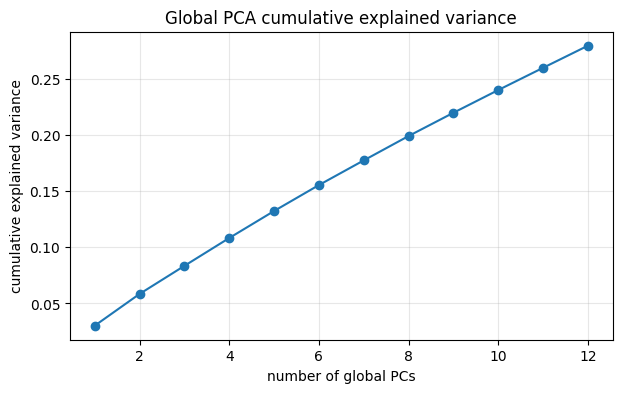

In [19]:
# ================================================================
# 18. 그룹별 PCA + 전체 PCA 진단
# ================================================================

# 좋은 후보 중심으로 PCA를 맞춘다.
# 이유: 전체 무작위 후보의 큰 분산보다, 좋은 후보가 몰리는 구조를 보는 것이 목적이기 때문.
ELITE_N_FOR_PCA = min(10000, len(all_results))
elite_for_pca = all_results.nsmallest(ELITE_N_FOR_PCA, "balance_loss").copy()

pca_artifacts = {}
latent_parts = []
latent_names = []

for g, cols in PARAM_GROUPS.items():
    if len(cols) < 2:
        continue
    G = elite_for_pca[cols].replace([np.inf, -np.inf], np.nan).fillna(elite_for_pca[cols].median())
    scaler = StandardScaler()
    Z = scaler.fit_transform(G)
    max_comp = min(len(cols), 4)  # 그룹당 최대 4축. 세부차이 보존을 위해 과도 압축 금지.
    pca = PCA(n_components=max_comp, random_state=42)
    T = pca.fit_transform(Z)
    pca_artifacts[g] = {"cols": cols, "scaler": scaler, "pca": pca}

    print(f"[{g}] cols={len(cols)}, comps={max_comp}, explained={np.round(pca.explained_variance_ratio_, 3)}, cum={pca.explained_variance_ratio_.sum():.3f}")

    loadings = pd.DataFrame(
        pca.components_.T,
        index=cols,
        columns=[f"{g}_PC{k+1}" for k in range(max_comp)],
    )
    loadings.to_csv(DIMRED_DIR/f"group_pca_loadings_{g}.csv", encoding="utf-8-sig")

    for k in range(max_comp):
        elite_for_pca[f"{g}_PC{k+1}"] = T[:, k]
        latent_parts.append(elite_for_pca[[f"{g}_PC{k+1}"]])
        latent_names.append(f"{g}_PC{k+1}")

elite_for_pca.to_csv(DIMRED_DIR/"elite_with_group_pca_scores.csv", index=False, encoding="utf-8-sig")

# 전체 PCA는 진단용으로만 수행
scaler_all = StandardScaler()
X_elite = elite_for_pca[PARAM_COLS].replace([np.inf, -np.inf], np.nan).fillna(elite_for_pca[PARAM_COLS].median())
Z_elite = scaler_all.fit_transform(X_elite)
pca_all = PCA(n_components=min(12, len(PARAM_COLS)), random_state=42)
T_all = pca_all.fit_transform(Z_elite)
print("전체 PCA explained:", np.round(pca_all.explained_variance_ratio_, 3))
print("전체 PCA cumulative:", np.round(np.cumsum(pca_all.explained_variance_ratio_), 3))

load_all = pd.DataFrame(
    pca_all.components_.T,
    index=PARAM_COLS,
    columns=[f"GLOBAL_PC{k+1}" for k in range(pca_all.n_components_)],
)
load_all.to_csv(DIMRED_DIR/"global_pca_loadings.csv", encoding="utf-8-sig")

display(load_all.iloc[:, :5].sort_values("GLOBAL_PC1", key=np.abs, ascending=False).head(20))

if plt is not None:
    plt.figure(figsize=(7, 4))
    plt.plot(np.arange(1, len(pca_all.explained_variance_ratio_)+1), np.cumsum(pca_all.explained_variance_ratio_), marker="o")
    plt.xlabel("number of global PCs")
    plt.ylabel("cumulative explained variance")
    plt.title("Global PCA cumulative explained variance")
    plt.grid(True, alpha=0.3)
    plt.show()

In [21]:
# ================================================================
# 19. 차원축소 후보 생성 및 재평가
# ================================================================

# 목적:
# - 17번 surrogate 중요도 분석 결과를 이용해 Active-TopK 변수를 뽑는다.
# - 전체 변수 중 중요한 변수만 흔들고, 나머지는 좋은 후보들의 중앙값으로 고정한다.
# - GROUP_PCA / PLS / ACTIVE_TOPK 방식으로 만든 후보를 실제 simulate_batch로 재평가한다.
# - 최종적으로 FULL_ALL_VARIABLES 탐색 결과와 차원축소 탐색 결과를 비교한다.

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------
# 0) 기본 경로 준비
# ------------------------------------------------

if "OUT_DIR" not in globals():
    OUT_DIR = Path("/content/chaoneung_param_lab_outputs")

OUT_DIR = Path(OUT_DIR)

if "DIMRED_DIR" not in globals():
    DIMRED_DIR = OUT_DIR / "dimred_compare_v36"

DIMRED_DIR = Path(DIMRED_DIR)
DIMRED_DIR.mkdir(parents=True, exist_ok=True)

print("OUT_DIR:", OUT_DIR)
print("DIMRED_DIR:", DIMRED_DIR)

# ------------------------------------------------
# 1) all_results 복구
# ------------------------------------------------
# 우선순위:
# 1. all_results가 메모리에 있으면 사용
# 2. result_df가 있으면 사용
# 3. stage3/stage2/stage1/combined 결과 CSV에서 복구
# ------------------------------------------------

if "all_results" not in globals():
    if "result_df" in globals() and isinstance(result_df, pd.DataFrame):
        all_results = result_df.copy()
        print("all_results를 result_df에서 복구:", all_results.shape)
    else:
        candidate_files = [
            OUT_DIR / "combined_stage1_stage2_ranked_v36.csv",
            OUT_DIR / "combined_stage1_stage2_ranked_v35.csv",
            OUT_DIR / "combined_stage1_stage2_ranked_v34.csv",
            OUT_DIR / "combined_stage1_stage2_ranked.csv",

            OUT_DIR / "stage3_deep_validation_v36_all_results.csv",
            OUT_DIR / "stage3_deep_validation_v35_all_results.csv",
            OUT_DIR / "stage3_deep_validation_v34_all_results.csv",
            OUT_DIR / "stage3_deep_validation_all_results.csv",

            OUT_DIR / "stage2_elite_refined_v36_all_results.csv",
            OUT_DIR / "stage2_elite_refined_v35_all_results.csv",
            OUT_DIR / "stage2_elite_refined_v34_all_results.csv",
            OUT_DIR / "stage2_elite_refined_all_results.csv",

            OUT_DIR / "stage1_qmc_wide_v36_all_results.csv",
            OUT_DIR / "stage1_qmc_wide_v35_all_results.csv",
            OUT_DIR / "stage1_qmc_wide_v34_all_results.csv",
            OUT_DIR / "stage1_qmc_wide_all_results.csv",
        ]

        # /content 전체에서도 탐색
        candidate_files += list(Path("/content").glob("*combined*ranked*.csv"))
        candidate_files += list(Path("/content").glob("*stage3*all_results*.csv"))
        candidate_files += list(Path("/content").glob("*stage2*all_results*.csv"))
        candidate_files += list(Path("/content").glob("*stage1*all_results*.csv"))

        loaded = False

        for fp in candidate_files:
            if fp.exists():
                try:
                    all_results = pd.read_csv(fp)
                    print(f"all_results를 CSV에서 복구: {fp}, shape={all_results.shape}")
                    loaded = True
                    break
                except Exception as e:
                    print(f"로드 실패: {fp} -> {e}")

        if not loaded:
            raise FileNotFoundError(
                "all_results/result_df를 찾지 못했고, 결과 CSV도 찾지 못했습니다. "
                "먼저 stage1/stage2/stage3 탐색 결과 또는 17번 surrogate 섹션을 실행해주세요."
            )
else:
    print("메모리의 all_results 사용:", all_results.shape)

all_results = all_results.copy()
all_results = all_results.replace([np.inf, -np.inf], np.nan)

if "balance_loss" not in all_results.columns:
    raise KeyError("all_results에 balance_loss 컬럼이 없습니다.")

all_results["balance_loss"] = pd.to_numeric(all_results["balance_loss"], errors="coerce")
all_results = all_results.dropna(subset=["balance_loss"]).reset_index(drop=True)

print("사용 가능한 all_results 행 수:", len(all_results))

# ------------------------------------------------
# 2) PARAM_COLS 복구
# ------------------------------------------------

metric_cols = {
    "theta_id",
    "source",
    "stage",
    "method",
    "constraint_ok",
    "balance_loss",

    "reach_d5",
    "reach_d10",
    "reach_d15",
    "reach_d20",
    "has_A",
    "has_S",

    "sink_ratio",
    "p99_p50",
    "D20_ev_cost",
    "late_15_20_share",
    "whale_sink_ratio",

    "mean_reward_bonus",
    "p99_reward_bonus",
    "mean_cost_reduce",
    "p99_cost_reduce",
    "mean_relic_count",
    "p99_relic_count",
    "mean_storage_slots",

    "battle_win_rate",
    "battle_sink_ratio",
    "mean_battle_attempts",
    "p99_battle_attempts",
    "mean_battle_gain",
    "p99_battle_gain",
    "mean_battle_loss",
    "p99_battle_loss",
    "underdog_win_share",

    "surrogate_pred_balance_loss",
    "surrogate_abs_error",
}

if "PARAM_COLS" not in globals():
    if "SURROGATE_PARAM_COLS" in globals():
        PARAM_COLS = [c for c in SURROGATE_PARAM_COLS if c in all_results.columns]
        print("PARAM_COLS를 SURROGATE_PARAM_COLS에서 복구")
    elif "PARAM_NAMES" in globals():
        PARAM_COLS = [c for c in PARAM_NAMES if c in all_results.columns]
        print("PARAM_COLS를 PARAM_NAMES에서 복구")
    elif "PARAM_RANGES" in globals():
        PARAM_COLS = [c for c in PARAM_RANGES.keys() if c in all_results.columns]
        print("PARAM_COLS를 PARAM_RANGES에서 복구")
    else:
        PARAM_COLS = [
            c for c in all_results.columns
            if c not in metric_cols and pd.api.types.is_numeric_dtype(all_results[c])
        ]
        print("PARAM_COLS를 all_results 숫자형 컬럼에서 추정")
else:
    PARAM_COLS = [c for c in PARAM_COLS if c in all_results.columns]
    print("메모리의 PARAM_COLS 사용")

# 숫자형 안정화
clean_param_cols = []

for c in PARAM_COLS:
    all_results[c] = pd.to_numeric(all_results[c], errors="coerce")
    if all_results[c].notna().sum() > 0:
        clean_param_cols.append(c)

PARAM_COLS = clean_param_cols

if len(PARAM_COLS) == 0:
    raise ValueError("사용 가능한 파라미터 컬럼을 찾지 못했습니다.")

print("PARAM_COLS 개수:", len(PARAM_COLS))
print(PARAM_COLS)

# ------------------------------------------------
# 3) imp_df / importance_df / ACTIVE_TOP_PARAMS 복구
# ------------------------------------------------

if "imp_df" not in globals():
    if "importance_df" in globals() and isinstance(importance_df, pd.DataFrame):
        imp_df = importance_df.copy()
        print("imp_df를 importance_df에서 복구")
    else:
        imp_candidates = [
            DIMRED_DIR / "surrogate_feature_importance_balance_loss.csv",
            DIMRED_DIR / "active_top_params.csv",
            DIMRED_DIR / "active_topK_selected_params.csv",
            OUT_DIR / "dimred_compare_v36" / "surrogate_feature_importance_balance_loss.csv",
            OUT_DIR / "dimred_compare_v36" / "active_top_params.csv",
            OUT_DIR / "dimred_compare_v36" / "active_topK_selected_params.csv",
        ]

        loaded_imp = False

        for fp in imp_candidates:
            if fp.exists():
                try:
                    imp_df = pd.read_csv(fp)
                    print(f"imp_df를 CSV에서 복구: {fp}, shape={imp_df.shape}")
                    loaded_imp = True
                    break
                except Exception as e:
                    print(f"중요도 파일 로드 실패: {fp} -> {e}")

        if not loaded_imp:
            if "ACTIVE_TOP_PARAMS" in globals():
                imp_df = pd.DataFrame(
                    {
                        "param": ACTIVE_TOP_PARAMS,
                        "importance": np.linspace(1.0, 0.1, len(ACTIVE_TOP_PARAMS)),
                    }
                )
                print("imp_df를 ACTIVE_TOP_PARAMS에서 임시 생성")
            else:
                raise NameError(
                    "imp_df / importance_df / ACTIVE_TOP_PARAMS를 찾지 못했습니다. "
                    "17번 surrogate 중요도 섹션을 먼저 실행해주세요."
                )
else:
    print("메모리의 imp_df 사용")

# 컬럼명 안정화
if "param" not in imp_df.columns:
    # 혹시 첫 번째 컬럼이 파라미터명인 경우 보정
    possible_param_cols = [c for c in imp_df.columns if "param" in c.lower() or "feature" in c.lower()]
    if len(possible_param_cols) > 0:
        imp_df = imp_df.rename(columns={possible_param_cols[0]: "param"})
    else:
        raise KeyError("imp_df에 param 컬럼이 없습니다.")

if "importance" not in imp_df.columns:
    possible_imp_cols = [c for c in imp_df.columns if "importance" in c.lower() or "score" in c.lower()]
    if len(possible_imp_cols) > 0:
        imp_df = imp_df.rename(columns={possible_imp_cols[0]: "importance"})
    else:
        imp_df["importance"] = np.linspace(1.0, 0.1, len(imp_df))

imp_df = imp_df.copy()
imp_df["importance"] = pd.to_numeric(imp_df["importance"], errors="coerce").fillna(0.0)
imp_df = imp_df[imp_df["param"].isin(PARAM_COLS)].sort_values("importance", ascending=False).reset_index(drop=True)

if len(imp_df) == 0:
    raise ValueError("imp_df에 PARAM_COLS와 겹치는 파라미터가 없습니다.")

display(imp_df.head(30))

# ------------------------------------------------
# 4) 좋은 후보들의 기준값 계산
# ------------------------------------------------

ELITE_FOR_MEDIAN = min(5000, len(all_results))

elite_for_median = (
    all_results
    .sort_values("balance_loss", ascending=True)
    .head(ELITE_FOR_MEDIAN)
    .copy()
)

active_fixed_median = elite_for_median[PARAM_COLS].median(numeric_only=True)

# PARAM_RANGES가 없으면 all_results 분위수 기반으로 범위 생성
if "PARAM_RANGES" not in globals():
    PARAM_RANGES = {}

    for c in PARAM_COLS:
        lo = all_results[c].quantile(0.01)
        hi = all_results[c].quantile(0.99)

        if pd.isna(lo) or pd.isna(hi) or lo == hi:
            lo = all_results[c].min()
            hi = all_results[c].max()

        if pd.isna(lo) or pd.isna(hi) or lo == hi:
            lo = float(active_fixed_median.get(c, 0.0)) - 1.0
            hi = float(active_fixed_median.get(c, 0.0)) + 1.0

        PARAM_RANGES[c] = (float(lo), float(hi))

    print("PARAM_RANGES를 all_results 분위수 기반으로 생성")
else:
    # 없는 파라미터는 분위수 기반으로 보완
    for c in PARAM_COLS:
        if c not in PARAM_RANGES:
            lo = all_results[c].quantile(0.01)
            hi = all_results[c].quantile(0.99)

            if pd.isna(lo) or pd.isna(hi) or lo == hi:
                lo = float(active_fixed_median.get(c, 0.0)) - 1.0
                hi = float(active_fixed_median.get(c, 0.0)) + 1.0

            PARAM_RANGES[c] = (float(lo), float(hi))

print("elite_for_median:", elite_for_median.shape)

# ------------------------------------------------
# 5) Active-TopK 변수 선정
# ------------------------------------------------

if "ACTIVE_TOP_PARAMS" in globals() and len(ACTIVE_TOP_PARAMS) > 0:
    active_top_params = [p for p in ACTIVE_TOP_PARAMS if p in PARAM_COLS]
    print("ACTIVE_TOP_PARAMS 사용")
else:
    TOPK_ACTIVE = min(18, len(PARAM_COLS))
    active_top_params = imp_df.head(TOPK_ACTIVE)["param"].tolist()
    print("imp_df 상위 변수 사용")

# 너무 적으면 최소 10개 확보
if len(active_top_params) < min(10, len(PARAM_COLS)):
    needed = min(10, len(PARAM_COLS)) - len(active_top_params)
    extra = [p for p in imp_df["param"].tolist() if p not in active_top_params][:needed]
    active_top_params += extra

TOPK_ACTIVE = len(active_top_params)

print("TOPK_ACTIVE:", TOPK_ACTIVE)
print(active_top_params)

# ------------------------------------------------
# 6) Sobol/무작위 샘플링 보조 함수
# ------------------------------------------------

def _qmc_uniform(n, d, seed=42):
    """
    scipy Sobol이 있으면 사용하고, 없으면 numpy random 사용.
    """
    try:
        from scipy.stats import qmc

        sampler = qmc.Sobol(d=d, scramble=True, seed=seed)

        # Sobol은 2^m이 가장 안정적이므로 n 이상인 2^m 생성 후 앞 n개 사용
        m = int(np.ceil(np.log2(max(n, 2))))
        u = sampler.random_base2(m=m)[:n]
    except Exception:
        rng = np.random.default_rng(seed)
        u = rng.random((n, d))

    return u

def _clip_param_values(df, param_cols, param_ranges):
    out = df.copy()

    for c in param_cols:
        if c in out.columns and c in param_ranges:
            lo, hi = param_ranges[c]
            out[c] = pd.to_numeric(out[c], errors="coerce").fillna(active_fixed_median.get(c, 0.0))
            out[c] = out[c].clip(lo, hi)

    return out

def _make_base_fixed_df(n, param_cols, fixed_median):
    base = pd.DataFrame(
        np.tile(fixed_median[param_cols].to_numpy(dtype=float), (n, 1)),
        columns=param_cols,
    )

    return base

# ------------------------------------------------
# 7) ACTIVE_TOPK 후보 생성
# ------------------------------------------------

if "DIMRED_N_PARAM" not in globals():
    DIMRED_N_PARAM = 8192 if globals().get("QUICK_MODE", False) else 32768

N_ACTIVE_CAND = int(DIMRED_N_PARAM)

rng = np.random.default_rng(20260505)

active_df = _make_base_fixed_df(N_ACTIVE_CAND, PARAM_COLS, active_fixed_median)

u = _qmc_uniform(N_ACTIVE_CAND, len(active_top_params), seed=20260505)

for j, c in enumerate(active_top_params):
    lo, hi = PARAM_RANGES[c]

    # elite 분포 기준으로 너무 넓게 흔들리지 않게 보정
    elite_lo = elite_for_median[c].quantile(0.02)
    elite_hi = elite_for_median[c].quantile(0.98)

    if not pd.isna(elite_lo) and not pd.isna(elite_hi) and elite_lo < elite_hi:
        # 전체 범위와 elite 범위를 혼합
        lo_use = max(float(lo), float(elite_lo) - 0.25 * (float(elite_hi) - float(elite_lo)))
        hi_use = min(float(hi), float(elite_hi) + 0.25 * (float(elite_hi) - float(elite_lo)))
    else:
        lo_use, hi_use = float(lo), float(hi)

    active_df[c] = lo_use + u[:, j] * (hi_use - lo_use)

active_df = _clip_param_values(active_df, PARAM_COLS, PARAM_RANGES)
active_df.insert(0, "theta_id", np.arange(36000000, 36000000 + len(active_df)))
active_df["method"] = "ACTIVE_TOPK"

active_df.to_csv(
    DIMRED_DIR / "active_topK_sampled_params.csv",
    index=False,
    encoding="utf-8-sig",
)

print("active_df:", active_df.shape)
display(active_df.head())

# ------------------------------------------------
# 8) GROUP_PCA 후보 생성
# ------------------------------------------------
# 16번 등에서 GROUP_PCA_MODEL / GROUP_PCA_INFO를 만든 경우 사용.
# 없으면 active_df 일부를 복사해 GROUP_PCA 후보로 대체한다.
# ------------------------------------------------

N_GROUP_PCA_CAND = max(1024, N_ACTIVE_CAND // 2)

group_pca_df = None

if "GROUP_PCA_INFO" in globals() and isinstance(GROUP_PCA_INFO, dict) and len(GROUP_PCA_INFO) > 0:
    try:
        group_pca_df = _make_base_fixed_df(N_GROUP_PCA_CAND, PARAM_COLS, active_fixed_median)

        for group_name, info in GROUP_PCA_INFO.items():
            cols = [c for c in info.get("cols", []) if c in PARAM_COLS]
            pca = info.get("pca", None)
            scaler = info.get("scaler", None)

            if len(cols) == 0 or pca is None or scaler is None:
                continue

            n_comp = getattr(pca, "n_components_", min(2, len(cols)))

            z = rng.normal(0, 1.0, size=(N_GROUP_PCA_CAND, n_comp))

            reconstructed_scaled = pca.inverse_transform(z)
            reconstructed = scaler.inverse_transform(reconstructed_scaled)

            for j, c in enumerate(cols):
                group_pca_df[c] = reconstructed[:, j]

        group_pca_df = _clip_param_values(group_pca_df, PARAM_COLS, PARAM_RANGES)
        group_pca_df.insert(0, "theta_id", np.arange(36100000, 36100000 + len(group_pca_df)))
        group_pca_df["method"] = "GROUP_PCA"

        print("GROUP_PCA_INFO 기반 group_pca_df 생성:", group_pca_df.shape)

    except Exception as e:
        print("GROUP_PCA 후보 생성 실패, active_df 기반 대체 사용:", e)
        group_pca_df = None

if group_pca_df is None:
    group_pca_df = active_df.sample(
        n=min(N_GROUP_PCA_CAND, len(active_df)),
        random_state=20260506,
    ).copy()
    group_pca_df["theta_id"] = np.arange(36100000, 36100000 + len(group_pca_df))
    group_pca_df["method"] = "GROUP_PCA_FALLBACK"

group_pca_df.to_csv(
    DIMRED_DIR / "group_pca_sampled_params.csv",
    index=False,
    encoding="utf-8-sig",
)

display(group_pca_df.head())

# ------------------------------------------------
# 9) PLS 후보 생성
# ------------------------------------------------
# PLS 객체가 있으면 PLS 잠재축 주변 샘플링을 시도한다.
# 없으면 active_df 기반 대체 후보 생성.
# ------------------------------------------------

N_PLS_CAND = max(1024, N_ACTIVE_CAND // 2)

pls_df = None

if "PLS_MODEL" in globals() and "PLS_SCALER_X" in globals():
    try:
        pls_df = _make_base_fixed_df(N_PLS_CAND, PARAM_COLS, active_fixed_median)

        n_comp = getattr(PLS_MODEL, "n_components", 2)
        z = rng.normal(0, 1.0, size=(N_PLS_CAND, n_comp))

        # sklearn PLSRegression은 inverse_transform 지원 여부가 버전에 따라 다름
        if hasattr(PLS_MODEL, "inverse_transform"):
            x_scaled = PLS_MODEL.inverse_transform(z)
            x_recon = PLS_SCALER_X.inverse_transform(x_scaled)

            for j, c in enumerate(PARAM_COLS[:x_recon.shape[1]]):
                pls_df[c] = x_recon[:, j]
        else:
            raise AttributeError("PLS_MODEL이 inverse_transform을 지원하지 않습니다.")

        pls_df = _clip_param_values(pls_df, PARAM_COLS, PARAM_RANGES)
        pls_df.insert(0, "theta_id", np.arange(36200000, 36200000 + len(pls_df)))
        pls_df["method"] = "PLS"

        print("PLS_MODEL 기반 pls_df 생성:", pls_df.shape)

    except Exception as e:
        print("PLS 후보 생성 실패, active_df 기반 대체 사용:", e)
        pls_df = None

if pls_df is None:
    pls_df = active_df.sample(
        n=min(N_PLS_CAND, len(active_df)),
        random_state=20260507,
    ).copy()
    pls_df["theta_id"] = np.arange(36200000, 36200000 + len(pls_df))
    pls_df["method"] = "PLS_FALLBACK"

pls_df.to_csv(
    DIMRED_DIR / "pls_sampled_params.csv",
    index=False,
    encoding="utf-8-sig",
)

display(pls_df.head())

# ------------------------------------------------
# 10) 차원축소 후보 합치기
# ------------------------------------------------

dimred_params = pd.concat(
    [
        active_df,
        group_pca_df,
        pls_df,
    ],
    ignore_index=True,
)

# 중복 theta_id 방지
dimred_params["theta_id"] = np.arange(36300000, 36300000 + len(dimred_params))

# run_sweep에는 theta_id + PARAM_COLS만 필요할 수 있으므로 method는 나중에 따로 붙인다.
method_series = dimred_params["method"].copy()

dimred_params_for_eval = dimred_params[["theta_id"] + PARAM_COLS].copy()

dimred_params.to_csv(
    DIMRED_DIR / "dimred_all_sampled_params_with_method.csv",
    index=False,
    encoding="utf-8-sig",
)

dimred_params_for_eval.to_csv(
    DIMRED_DIR / "dimred_all_sampled_params_for_eval.csv",
    index=False,
    encoding="utf-8-sig",
)

print("dimred_params:", dimred_params.shape)
print(dimred_params["method"].value_counts())

# ------------------------------------------------
# 11) 차원축소 후보 실제 시뮬레이션 재평가
# ------------------------------------------------

if "DIMRED_R_MC" not in globals():
    DIMRED_R_MC = 4

if "DIMRED_BATCH_SIZE" not in globals():
    DIMRED_BATCH_SIZE = 512

print(
    f"[dimred_v36_eval] n={len(dimred_params_for_eval)}, "
    f"r_mc={DIMRED_R_MC}, batch={DIMRED_BATCH_SIZE}"
)

if "run_sweep" not in globals():
    raise NameError("run_sweep 함수가 없습니다. 이전 시뮬레이션/탐색 섹션을 먼저 실행해주세요.")

dimred_res = run_sweep(
    dimred_params_for_eval,
    r_mc=DIMRED_R_MC,
    batch_size=DIMRED_BATCH_SIZE,
    stage_name="dimred_v36_eval",
)

dimred_res = dimred_res.copy()

# method 다시 붙이기
method_map = dimred_params[["theta_id", "method"]].copy()
dimred_res = dimred_res.merge(method_map, on="theta_id", how="left")

dimred_res = dimred_res.sort_values("balance_loss", ascending=True).reset_index(drop=True)

dimred_res.to_csv(
    DIMRED_DIR / "dimred_v36_eval_all_results.csv",
    index=False,
    encoding="utf-8-sig",
)

display(dimred_res.head(30))

# ------------------------------------------------
# 12) FULL_ALL_VARIABLES 결과와 비교
# ------------------------------------------------

full_compare = all_results.copy()
full_compare["method"] = full_compare.get("method", "FULL_ALL_VARIABLES")

# 비교용 상위 일부만 저장해도 되지만, 여기서는 전체 합침
combined_full_dimred = pd.concat(
    [
        full_compare,
        dimred_res,
    ],
    ignore_index=True,
    sort=False,
)

combined_full_dimred = combined_full_dimred.sort_values(
    "balance_loss",
    ascending=True,
).reset_index(drop=True)

combined_full_dimred.to_csv(
    DIMRED_DIR / "combined_full_dimred_ranked.csv",
    index=False,
    encoding="utf-8-sig",
)

# method별 요약
summary_rows = []

for method, g in combined_full_dimred.groupby("method"):
    row = {
        "method": method,
        "n": len(g),
        "best_loss": float(g["balance_loss"].min()),
        "median_loss": float(g["balance_loss"].median()),
    }

    if "constraint_ok" in g.columns:
        ok = (
            g["constraint_ok"]
            .astype(str)
            .str.lower()
            .isin(["true", "1", "yes"])
        )
        row["constraint_ok_count"] = int(ok.sum())
        row["constraint_ok_rate"] = float(ok.mean())

    for col in [
        "reach_d5",
        "reach_d10",
        "reach_d15",
        "reach_d20",
        "has_A",
        "has_S",
        "sink_ratio",
        "p99_p50",
        "D20_ev_cost",
        "late_15_20_share",
        "p99_reward_bonus",
        "p99_cost_reduce",
        "p99_relic_count",
    ]:
        if col in g.columns:
            best_idx = g["balance_loss"].idxmin()
            row[f"best_{col}"] = float(g.loc[best_idx, col])

    summary_rows.append(row)

comparison_summary = pd.DataFrame(summary_rows).sort_values("best_loss").reset_index(drop=True)

comparison_summary.to_csv(
    DIMRED_DIR / "full_vs_dimred_comparison_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

display(comparison_summary)

# ------------------------------------------------
# 13) 최종 추천 후보 저장
# ------------------------------------------------

best_row = combined_full_dimred.iloc[0].copy()

best_method = best_row.get("method", "UNKNOWN")
best_theta_id = best_row.get("theta_id", None)
best_loss = best_row.get("balance_loss", None)

print("최종 best method:", best_method)
print("최종 best theta_id:", best_theta_id)
print("최종 best balance_loss:", best_loss)

# code_params 생성 함수가 있으면 사용
recommended = {
    "theta_id": int(best_theta_id) if pd.notna(best_theta_id) else None,
    "method": str(best_method),
    "metrics": {},
    "raw_params": {},
}

metric_output_cols = [
    "constraint_ok",
    "balance_loss",
    "reach_d5",
    "reach_d10",
    "reach_d15",
    "reach_d20",
    "has_A",
    "has_S",
    "sink_ratio",
    "p99_p50",
    "D20_ev_cost",
    "late_15_20_share",
    "whale_sink_ratio",
    "mean_reward_bonus",
    "p99_reward_bonus",
    "mean_cost_reduce",
    "p99_cost_reduce",
    "mean_relic_count",
    "p99_relic_count",
    "mean_storage_slots",
]

for c in metric_output_cols:
    if c in best_row.index:
        val = best_row[c]
        if isinstance(val, (np.bool_, bool)):
            recommended["metrics"][c] = bool(val)
        elif pd.isna(val):
            recommended["metrics"][c] = None
        else:
            try:
                recommended["metrics"][c] = float(val)
            except Exception:
                recommended["metrics"][c] = str(val)

for c in PARAM_COLS:
    if c in best_row.index:
        val = best_row[c]
        if pd.isna(val):
            recommended["raw_params"][c] = None
        else:
            try:
                recommended["raw_params"][c] = float(val)
            except Exception:
                recommended["raw_params"][c] = str(val)

# make_code_params류 함수가 있으면 code_params도 생성
if "make_code_params" in globals():
    try:
        raw_param_series = pd.Series(recommended["raw_params"])
        recommended["code_params"] = make_code_params(raw_param_series)
    except Exception as e:
        print("make_code_params 실행 실패:", e)

with open(
    DIMRED_DIR / "FINAL_recommended_parameters_v36_dimred_compare.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(recommended, f, ensure_ascii=False, indent=2)

print("저장 완료:")
print(DIMRED_DIR / "dimred_v36_eval_all_results.csv")
print(DIMRED_DIR / "combined_full_dimred_ranked.csv")
print(DIMRED_DIR / "full_vs_dimred_comparison_summary.csv")
print(DIMRED_DIR / "FINAL_recommended_parameters_v36_dimred_compare.json")

OUT_DIR: /content/chaoneung_param_lab_v35_battle_outputs
DIMRED_DIR: /content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36
메모리의 all_results 사용: (197108, 107)
사용 가능한 all_results 행 수: 197108
메모리의 PARAM_COLS 사용
PARAM_COLS 개수: 73
['reward_scale', 'chosung_scale', 'jamo_scale', 'hunmin_scale', 'combo_multiplier', 'p_chosung_raw', 'p_hunmin_raw', 'p_jamo_raw', 'p_chosung_random', 'wrong_penalty_scale', 'wrong_per_correct', 'hint_cost', 'hint_rate_inactive', 'hint_rate_low', 'hint_rate_mid', 'hint_rate_high', 'hint_rate_whale', 'hint_rate_ultra', 'combo_trigger_base', 'combo_activity_slope', 'combo_questions_factor', 'combo_relic_scale', 'enhance_base', 'enhance_growth', 'success_early', 'success_mid', 'success_late', 'level_factor', 'drop_D', 'drop_C', 'drop_B', 'drop_A', 'synth_cost_scale', 'synth_success_scale', 'dismantle_scale', 'storage_ratio', 'storage_bonus_cap', 'effect_scale', 'cost_reduce_cap', 'reward_bonus_cap', 'inv_expand_cost', 'inventory_expand_aggr', 'type_all_b

,param,importance,importance_cumsum
0,enhance_growth,0.314438,0.314438
1,success_mid,0.217517,0.531955
2,success_late,0.108065,0.640021
3,enhance_base,0.067873,0.707894
4,activity_scale,0.032446,0.740340
5,battle_participation_base,0.032135,0.772475
6,battle_high_mult,0.023741,0.796216
7,drop_D,0.014822,0.811038
8,battle_steal_base_ratio,0.014140,0.825178
9,spend_mid,0.013874,0.839052


elite_for_median: (5000, 107)
ACTIVE_TOP_PARAMS 사용
TOPK_ACTIVE: 15
['enhance_growth', 'success_mid', 'success_late', 'enhance_base', 'activity_scale', 'battle_participation_base', 'battle_high_mult', 'drop_D', 'battle_steal_base_ratio', 'spend_mid', 'battle_entry_cost', 'reward_scale', 'success_early', 'jamo_scale', 'spend_high']
active_df: (32768, 75)


,theta_id,reward_scale,chosung_scale,jamo_scale,hunmin_scale,combo_multiplier,p_chosung_raw,p_hunmin_raw,p_jamo_raw,p_chosung_random,...,battle_temperature,battle_entry_cost,battle_steal_base_ratio,battle_steal_cap,battle_min_protected_points,battle_fee_rate,battle_underdog_bonus_scale,battle_favorite_penalty_scale,battle_target_up_bias,method
0,36000000,1.424244,1.209416,1.123447,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,353.188043,0.044721,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,ACTIVE_TOPK
1,36000001,1.003496,1.209416,1.337351,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,684.986508,0.022381,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,ACTIVE_TOPK
2,36000002,0.915410,1.209416,0.873019,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,511.423670,0.004838,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,ACTIVE_TOPK
3,36000003,1.146686,1.209416,1.484946,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,86.383157,0.056053,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,ACTIVE_TOPK
4,36000004,1.253706,1.209416,1.181080,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,508.785973,0.017826,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,ACTIVE_TOPK


,theta_id,reward_scale,chosung_scale,jamo_scale,hunmin_scale,combo_multiplier,p_chosung_raw,p_hunmin_raw,p_jamo_raw,p_chosung_random,...,battle_temperature,battle_entry_cost,battle_steal_base_ratio,battle_steal_cap,battle_min_protected_points,battle_fee_rate,battle_underdog_bonus_scale,battle_favorite_penalty_scale,battle_target_up_bias,method
26941,36100000,1.439830,1.209416,1.074211,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,431.698466,0.010876,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,GROUP_PCA_FALLBACK
27059,36100001,1.428821,1.209416,1.438403,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,580.221163,0.042361,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,GROUP_PCA_FALLBACK
23528,36100002,1.131185,1.209416,0.764022,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,159.492761,0.038397,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,GROUP_PCA_FALLBACK
9906,36100003,1.173370,1.209416,0.889935,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,727.935778,0.040646,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,GROUP_PCA_FALLBACK
10521,36100004,1.338389,1.209416,0.866808,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,264.179237,0.043107,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,GROUP_PCA_FALLBACK


,theta_id,reward_scale,chosung_scale,jamo_scale,hunmin_scale,combo_multiplier,p_chosung_raw,p_hunmin_raw,p_jamo_raw,p_chosung_random,...,battle_temperature,battle_entry_cost,battle_steal_base_ratio,battle_steal_cap,battle_min_protected_points,battle_fee_rate,battle_underdog_bonus_scale,battle_favorite_penalty_scale,battle_target_up_bias,method
5595,36200000,1.109829,1.209416,1.255242,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,573.260988,0.037326,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,PLS_FALLBACK
3431,36200001,1.125084,1.209416,0.804224,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,211.029342,0.004094,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,PLS_FALLBACK
4239,36200002,0.975230,1.209416,1.067539,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,188.407317,0.017290,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,PLS_FALLBACK
31042,36200003,1.019540,1.209416,1.004364,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,777.124897,0.039923,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,PLS_FALLBACK
15056,36200004,1.382772,1.209416,1.033809,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,395.862883,0.057326,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,PLS_FALLBACK


dimred_params: (65536, 75)
method
ACTIVE_TOPK           32768
GROUP_PCA_FALLBACK    16384
PLS_FALLBACK          16384
Name: count, dtype: int64
[dimred_v36_eval] n=65536, r_mc=4, batch=512
[dimred_v36_eval] n=65536, r_mc=4, batch=512
  batch       0~512     | best=1.9519 | ok=0 | 0.2m
  batch    2560~3072    | best=1.9002 | ok=0 | 1.0m
  batch    5120~5632    | best=1.8029 | ok=0 | 1.9m
  batch    7680~8192    | best=1.9126 | ok=0 | 2.8m
  batch   10240~10752   | best=1.8355 | ok=0 | 3.6m
  batch   12800~13312   | best=2.0624 | ok=0 | 4.5m
  batch   15360~15872   | best=2.0100 | ok=0 | 5.4m
  batch   17920~18432   | best=1.9631 | ok=0 | 6.3m
  batch   20480~20992   | best=2.0205 | ok=0 | 7.1m
  batch   23040~23552   | best=1.8818 | ok=0 | 8.1m
  batch   25600~26112   | best=1.8386 | ok=0 | 8.9m
  batch   28160~28672   | best=2.0644 | ok=0 | 9.8m
  batch   30720~31232   | best=1.8736 | ok=0 | 10.7m
  batch   33280~33792   | best=1.8496 | ok=0 | 11.6m
  batch   35840~36352   | best=1.939

,theta_id,reward_scale,chosung_scale,jamo_scale,hunmin_scale,combo_multiplier,p_chosung_raw,p_hunmin_raw,p_jamo_raw,p_chosung_random,...,mean_battle_attempts,p99_battle_attempts,battle_win_rate,battle_sink_ratio,mean_battle_gain,p99_battle_gain,mean_battle_loss,p99_battle_loss,underdog_win_share,method
0,36365480,1.321827,1.209416,1.136912,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.057990,0.191667,0.589225,0.013798,1229.001343,5409.659180,8410.000977,24936.382812,0.085172,PLS_FALLBACK
1,36306092,1.321827,1.209416,1.136912,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.058359,0.190278,0.588992,0.013856,1235.064087,5495.798828,8461.183594,25105.667969,0.085852,ACTIVE_TOPK
2,36312114,1.247627,1.209416,1.369677,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.060583,0.245833,0.610673,0.007410,545.138367,3190.083008,5095.490723,19084.480469,0.069168,ACTIVE_TOPK
3,36346191,1.247627,1.209416,1.369677,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.061256,0.248611,0.611370,0.007477,553.114380,3152.185547,5154.623047,19211.949219,0.068794,GROUP_PCA_FALLBACK
4,36308922,1.276006,1.209416,1.278632,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.076120,0.245833,0.583202,0.038277,3279.297363,14713.919922,4877.356934,18654.587891,0.088349,ACTIVE_TOPK
5,36306602,1.414655,1.209416,1.266359,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.072492,0.225000,0.581599,0.022754,2254.017334,8840.809570,5815.166504,16705.470703,0.089827,ACTIVE_TOPK
6,36329710,1.276417,1.209416,1.270001,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.121893,0.545833,0.586578,0.030062,2378.117432,13680.603516,4141.821777,18115.896484,0.084601,ACTIVE_TOPK
7,36350357,1.414655,1.209416,1.266359,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.072644,0.225778,0.581572,0.022845,2263.201172,8895.613281,5833.227539,16862.449219,0.088692,PLS_FALLBACK
8,36343393,1.414655,1.209416,1.266359,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.072045,0.226389,0.582022,0.022638,2228.946045,8873.548828,5764.664062,16601.066406,0.088382,GROUP_PCA_FALLBACK
9,36325162,1.391132,1.209416,1.525486,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.036263,0.152778,0.610740,0.014601,1323.008545,6500.767578,6685.895508,22970.109375,0.068981,ACTIVE_TOPK


,method,n,best_loss,median_loss,constraint_ok_count,constraint_ok_rate,best_reach_d5,best_reach_d10,best_reach_d15,best_reach_d20,best_has_A,best_has_S,best_sink_ratio,best_p99_p50,best_D20_ev_cost,best_late_15_20_share,best_p99_reward_bonus,best_p99_cost_reduce,best_p99_relic_count
0,FULL_ALL_VARIABLES,197108,1.327685,2.734949,0,0.0,0.307121,0.068671,0.000819,0.000130,0.015791,0.0,0.376188,2.863106,242967.71875,0.698218,0.019651,0.019803,4.266062
1,PLS_FALLBACK,16384,1.734824,3.220693,0,0.0,0.353132,0.094708,0.000720,0.000144,0.019114,0.0,0.427568,3.026390,249063.50000,0.759008,0.046404,0.011861,4.819301
2,ACTIVE_TOPK,32768,1.750752,3.223642,0,0.0,0.352844,0.093773,0.000720,0.000144,0.018251,0.0,0.426365,3.004857,249063.50000,0.759008,0.045964,0.011674,4.819301
3,GROUP_PCA_FALLBACK,16384,1.763160,3.227704,0,0.0,0.183729,0.028690,0.000216,0.000072,0.015659,0.0,0.334331,3.036422,252972.81250,0.710721,0.038885,0.007880,4.000000


최종 best method: FULL_ALL_VARIABLES
최종 best theta_id: 20013020
최종 best balance_loss: 1.3276845
저장 완료:
/content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36/dimred_v36_eval_all_results.csv
/content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36/combined_full_dimred_ranked.csv
/content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36/full_vs_dimred_comparison_summary.csv
/content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36/FINAL_recommended_parameters_v36_dimred_compare.json


In [23]:
# ================================================================
# 20. 차원축소 후보 생성/평가: GROUP_PCA vs PLS vs ACTIVE_TOPK
# ================================================================

# 목적:
# - 기존 전체 변수 탐색 결과 all_results를 기반으로
#   GROUP_PCA / PLS / ACTIVE_TOPK 후보를 새로 생성한다.
# - 생성된 후보를 실제 simulate_batch/run_sweep으로 다시 평가한다.
# - 전체 변수 직접 탐색 결과와 차원축소 탐색 결과를 비교한다.
#
# 수정 포인트:
# - 기존 오류 원인인 elite_T 직접 참조 제거
# - PLS latent 좌표가 없으면 자동으로 계산하거나 fallback 사용
# - GROUP_PCA_INFO / PLS_MODEL / ACTIVE_TOP_PARAMS가 없어도 최대한 복구
# - 최종 결과는 원래 파라미터 값으로 저장

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------
# 0) 기본 경로/설정
# ------------------------------------------------

if "OUT_DIR" not in globals():
    OUT_DIR = Path("/content/chaoneung_param_lab_outputs")

OUT_DIR = Path(OUT_DIR)

if "DIMRED_DIR" not in globals():
    DIMRED_DIR = OUT_DIR / "dimred_compare_v36"

DIMRED_DIR = Path(DIMRED_DIR)
DIMRED_DIR.mkdir(parents=True, exist_ok=True)

DIMRED_N = 16384 if "DIMRED_N" not in globals() else int(DIMRED_N)
DIMRED_R_MC = 4 if "DIMRED_R_MC" not in globals() else int(DIMRED_R_MC)
DIMRED_BATCH_SIZE = 384 if "DIMRED_BATCH_SIZE" not in globals() else int(DIMRED_BATCH_SIZE)

print("DIMRED_N:", DIMRED_N, "R_MC:", DIMRED_R_MC, "BATCH:", DIMRED_BATCH_SIZE)
print("OUT_DIR:", OUT_DIR)
print("DIMRED_DIR:", DIMRED_DIR)

# ------------------------------------------------
# 1) all_results 복구
# ------------------------------------------------

if "all_results" not in globals():
    if "result_df" in globals() and isinstance(result_df, pd.DataFrame):
        all_results = result_df.copy()
        print("all_results를 result_df에서 복구:", all_results.shape)
    else:
        candidate_files = [
            OUT_DIR / "combined_stage1_stage2_ranked_v36.csv",
            OUT_DIR / "combined_stage1_stage2_ranked_v35.csv",
            OUT_DIR / "combined_stage1_stage2_ranked_v34.csv",
            OUT_DIR / "combined_stage1_stage2_ranked.csv",

            OUT_DIR / "stage3_deep_validation_v36_all_results.csv",
            OUT_DIR / "stage3_deep_validation_v35_all_results.csv",
            OUT_DIR / "stage3_deep_validation_v34_all_results.csv",
            OUT_DIR / "stage3_deep_validation_all_results.csv",

            OUT_DIR / "stage2_elite_refined_v36_all_results.csv",
            OUT_DIR / "stage2_elite_refined_v35_all_results.csv",
            OUT_DIR / "stage2_elite_refined_v34_all_results.csv",
            OUT_DIR / "stage2_elite_refined_all_results.csv",

            OUT_DIR / "stage1_qmc_wide_v36_all_results.csv",
            OUT_DIR / "stage1_qmc_wide_v35_all_results.csv",
            OUT_DIR / "stage1_qmc_wide_v34_all_results.csv",
            OUT_DIR / "stage1_qmc_wide_all_results.csv",
        ]

        candidate_files += list(Path("/content").glob("*combined*ranked*.csv"))
        candidate_files += list(Path("/content").glob("*stage3*all_results*.csv"))
        candidate_files += list(Path("/content").glob("*stage2*all_results*.csv"))
        candidate_files += list(Path("/content").glob("*stage1*all_results*.csv"))

        loaded = False

        for fp in candidate_files:
            if fp.exists():
                try:
                    all_results = pd.read_csv(fp)
                    print(f"all_results를 CSV에서 복구: {fp}, shape={all_results.shape}")
                    loaded = True
                    break
                except Exception as e:
                    print(f"로드 실패: {fp} -> {e}")

        if not loaded:
            raise FileNotFoundError(
                "all_results/result_df를 찾지 못했습니다. "
                "먼저 stage1/stage2/stage3 결과 또는 17번 섹션을 실행해주세요."
            )
else:
    print("메모리의 all_results 사용:", all_results.shape)

all_results = all_results.copy()
all_results = all_results.replace([np.inf, -np.inf], np.nan)

if "balance_loss" not in all_results.columns:
    raise KeyError("all_results에 balance_loss 컬럼이 없습니다.")

all_results["balance_loss"] = pd.to_numeric(all_results["balance_loss"], errors="coerce")
all_results = all_results.dropna(subset=["balance_loss"]).reset_index(drop=True)

print("사용 가능한 all_results 행 수:", len(all_results))

# ------------------------------------------------
# 2) PARAM_COLS 복구
# ------------------------------------------------

metric_cols = {
    "theta_id",
    "source",
    "stage",
    "method",
    "constraint_ok",
    "balance_loss",

    "reach_d5",
    "reach_d10",
    "reach_d15",
    "reach_d20",
    "has_A",
    "has_S",

    "sink_ratio",
    "p99_p50",
    "D20_ev_cost",
    "late_15_20_share",
    "whale_sink_ratio",

    "mean_reward_bonus",
    "p99_reward_bonus",
    "mean_cost_reduce",
    "p99_cost_reduce",
    "mean_relic_count",
    "p99_relic_count",
    "mean_storage_slots",

    "battle_win_rate",
    "battle_sink_ratio",
    "mean_battle_attempts",
    "p99_battle_attempts",
    "mean_battle_gain",
    "p99_battle_gain",
    "mean_battle_loss",
    "p99_battle_loss",
    "underdog_win_share",

    "surrogate_pred_balance_loss",
    "surrogate_abs_error",
}

if "PARAM_COLS" not in globals():
    if "SURROGATE_PARAM_COLS" in globals():
        PARAM_COLS = [c for c in SURROGATE_PARAM_COLS if c in all_results.columns]
        print("PARAM_COLS를 SURROGATE_PARAM_COLS에서 복구")
    elif "PARAM_NAMES" in globals():
        PARAM_COLS = [c for c in PARAM_NAMES if c in all_results.columns]
        print("PARAM_COLS를 PARAM_NAMES에서 복구")
    elif "PARAM_RANGES" in globals():
        PARAM_COLS = [c for c in PARAM_RANGES.keys() if c in all_results.columns]
        print("PARAM_COLS를 PARAM_RANGES에서 복구")
    else:
        PARAM_COLS = [
            c for c in all_results.columns
            if c not in metric_cols and pd.api.types.is_numeric_dtype(all_results[c])
        ]
        print("PARAM_COLS를 all_results 숫자형 컬럼에서 추정")
else:
    PARAM_COLS = [c for c in PARAM_COLS if c in all_results.columns]
    print("메모리의 PARAM_COLS 사용")

clean_cols = []

for c in PARAM_COLS:
    all_results[c] = pd.to_numeric(all_results[c], errors="coerce")
    if all_results[c].notna().sum() > 0:
        clean_cols.append(c)

PARAM_COLS = clean_cols

if len(PARAM_COLS) == 0:
    raise ValueError("사용 가능한 파라미터 컬럼을 찾지 못했습니다.")

print("PARAM_COLS 개수:", len(PARAM_COLS))
print(PARAM_COLS)

# ------------------------------------------------
# 3) elite 기준값과 PARAM_RANGES 준비
# ------------------------------------------------

ELITE_N = min(5000, len(all_results))

elite_df = (
    all_results
    .sort_values("balance_loss", ascending=True)
    .head(ELITE_N)
    .copy()
)

elite_median = elite_df[PARAM_COLS].median(numeric_only=True)

if "PARAM_RANGES" not in globals():
    PARAM_RANGES = {}

for c in PARAM_COLS:
    if c not in PARAM_RANGES:
        lo = all_results[c].quantile(0.01)
        hi = all_results[c].quantile(0.99)

        if pd.isna(lo) or pd.isna(hi) or lo == hi:
            lo = all_results[c].min()
            hi = all_results[c].max()

        if pd.isna(lo) or pd.isna(hi) or lo == hi:
            center = float(elite_median.get(c, 0.0))
            lo, hi = center - 1.0, center + 1.0

        PARAM_RANGES[c] = (float(lo), float(hi))

print("elite_df:", elite_df.shape)

# ------------------------------------------------
# 4) 중요도 imp_df / ACTIVE_TOP_PARAMS 복구
# ------------------------------------------------

if "imp_df" not in globals():
    if "importance_df" in globals() and isinstance(importance_df, pd.DataFrame):
        imp_df = importance_df.copy()
        print("imp_df를 importance_df에서 복구")
    else:
        imp_candidates = [
            DIMRED_DIR / "surrogate_feature_importance_balance_loss.csv",
            DIMRED_DIR / "active_top_params.csv",
            DIMRED_DIR / "active_topK_selected_params.csv",
            OUT_DIR / "dimred_compare_v36" / "surrogate_feature_importance_balance_loss.csv",
            OUT_DIR / "dimred_compare_v36" / "active_top_params.csv",
            OUT_DIR / "dimred_compare_v36" / "active_topK_selected_params.csv",
        ]

        loaded_imp = False

        for fp in imp_candidates:
            if fp.exists():
                try:
                    imp_df = pd.read_csv(fp)
                    print(f"imp_df를 CSV에서 복구: {fp}, shape={imp_df.shape}")
                    loaded_imp = True
                    break
                except Exception as e:
                    print(f"중요도 파일 로드 실패: {fp} -> {e}")

        if not loaded_imp:
            if "ACTIVE_TOP_PARAMS" in globals():
                imp_df = pd.DataFrame(
                    {
                        "param": ACTIVE_TOP_PARAMS,
                        "importance": np.linspace(1.0, 0.1, len(ACTIVE_TOP_PARAMS)),
                    }
                )
                print("imp_df를 ACTIVE_TOP_PARAMS에서 임시 생성")
            else:
                # 최후 fallback: elite_df와 balance_loss의 절대 상관으로 중요도 생성
                rows = []
                y = elite_df["balance_loss"].to_numpy()

                for c in PARAM_COLS:
                    x = elite_df[c].to_numpy()
                    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
                        score = 0.0
                    else:
                        score = abs(np.corrcoef(np.nan_to_num(x), np.nan_to_num(y))[0, 1])
                        if np.isnan(score):
                            score = 0.0

                    rows.append({"param": c, "importance": score})

                imp_df = pd.DataFrame(rows).sort_values("importance", ascending=False)
                print("imp_df를 상관 기반 fallback으로 생성")
else:
    print("메모리의 imp_df 사용")

# 컬럼명 안정화
if "param" not in imp_df.columns:
    possible_param_cols = [c for c in imp_df.columns if "param" in c.lower() or "feature" in c.lower()]
    if possible_param_cols:
        imp_df = imp_df.rename(columns={possible_param_cols[0]: "param"})
    else:
        raise KeyError("imp_df에 param 컬럼이 없습니다.")

if "importance" not in imp_df.columns:
    possible_imp_cols = [c for c in imp_df.columns if "importance" in c.lower() or "score" in c.lower()]
    if possible_imp_cols:
        imp_df = imp_df.rename(columns={possible_imp_cols[0]: "importance"})
    else:
        imp_df["importance"] = np.linspace(1.0, 0.1, len(imp_df))

imp_df = imp_df.copy()
imp_df["importance"] = pd.to_numeric(imp_df["importance"], errors="coerce").fillna(0.0)
imp_df = imp_df[imp_df["param"].isin(PARAM_COLS)].sort_values("importance", ascending=False).reset_index(drop=True)

if len(imp_df) == 0:
    raise ValueError("imp_df에 PARAM_COLS와 겹치는 파라미터가 없습니다.")

if "ACTIVE_TOP_PARAMS" not in globals():
    ACTIVE_TOP_PARAMS = imp_df.head(min(18, len(imp_df)))["param"].tolist()

ACTIVE_TOP_PARAMS = [p for p in ACTIVE_TOP_PARAMS if p in PARAM_COLS]

if len(ACTIVE_TOP_PARAMS) == 0:
    ACTIVE_TOP_PARAMS = imp_df.head(min(18, len(imp_df)))["param"].tolist()

print("ACTIVE_TOP_PARAMS:", ACTIVE_TOP_PARAMS)

display(imp_df.head(30))

# ------------------------------------------------
# 5) 공통 helper 함수
# ------------------------------------------------

def qmc_uniform(n, d, seed=42):
    try:
        from scipy.stats import qmc

        sampler = qmc.Sobol(d=d, scramble=True, seed=seed)
        m = int(np.ceil(np.log2(max(n, 2))))
        u = sampler.random_base2(m=m)[:n]
    except Exception:
        rng = np.random.default_rng(seed)
        u = rng.random((n, d))

    return u

def clip_params(df):
    out = df.copy()

    for c in PARAM_COLS:
        if c in out.columns:
            lo, hi = PARAM_RANGES[c]
            out[c] = pd.to_numeric(out[c], errors="coerce").fillna(float(elite_median.get(c, 0.0)))
            out[c] = out[c].clip(lo, hi)

    return out

def make_base_df(n):
    arr = np.tile(elite_median[PARAM_COLS].to_numpy(dtype=float), (n, 1))
    return pd.DataFrame(arr, columns=PARAM_COLS)

# ------------------------------------------------
# 6) ACTIVE_TOPK 후보 생성
# ------------------------------------------------

def make_active_topk_candidates(n_params, seed=20260505):
    rng = np.random.default_rng(seed)

    active_cols = ACTIVE_TOP_PARAMS[:min(18, len(ACTIVE_TOP_PARAMS))]
    if len(active_cols) == 0:
        active_cols = PARAM_COLS[:min(18, len(PARAM_COLS))]

    df = make_base_df(n_params)

    u = qmc_uniform(n_params, len(active_cols), seed=seed)

    for j, c in enumerate(active_cols):
        lo, hi = PARAM_RANGES[c]

        elite_lo = elite_df[c].quantile(0.02)
        elite_hi = elite_df[c].quantile(0.98)

        if not pd.isna(elite_lo) and not pd.isna(elite_hi) and elite_lo < elite_hi:
            width = float(elite_hi - elite_lo)
            lo_use = max(float(lo), float(elite_lo) - 0.25 * width)
            hi_use = min(float(hi), float(elite_hi) + 0.25 * width)
        else:
            lo_use, hi_use = float(lo), float(hi)

        df[c] = lo_use + u[:, j] * (hi_use - lo_use)

    df = clip_params(df)
    df.insert(0, "theta_id", np.arange(37000000, 37000000 + len(df)))
    df["method"] = "ACTIVE_TOPK"

    return df

# ------------------------------------------------
# 7) GROUP_PCA 후보 생성
# ------------------------------------------------

def make_group_pca_candidates(n_params, seed=20260506):
    rng = np.random.default_rng(seed)

    df = make_base_df(n_params)

    used_group_pca = False

    if "GROUP_PCA_INFO" in globals() and isinstance(GROUP_PCA_INFO, dict) and len(GROUP_PCA_INFO) > 0:
        try:
            for group_name, info in GROUP_PCA_INFO.items():
                cols = [c for c in info.get("cols", []) if c in PARAM_COLS]
                pca = info.get("pca", None)
                scaler = info.get("scaler", None)

                if len(cols) == 0 or pca is None or scaler is None:
                    continue

                n_comp = getattr(pca, "n_components_", min(2, len(cols)))

                z = rng.normal(0, 1.0, size=(n_params, n_comp))
                rec_scaled = pca.inverse_transform(z)
                rec = scaler.inverse_transform(rec_scaled)

                for j, c in enumerate(cols):
                    df[c] = rec[:, j]

            used_group_pca = True
            df["method"] = "GROUP_PCA"

        except Exception as e:
            print("GROUP_PCA_INFO 기반 생성 실패, fallback 사용:", e)

    if not used_group_pca:
        # fallback: active topK 주변 샘플링
        df = make_active_topk_candidates(n_params, seed=seed)
        df["method"] = "GROUP_PCA_FALLBACK"

    df = clip_params(df)

    if "theta_id" in df.columns:
        df = df.drop(columns=["theta_id"])

    df.insert(0, "theta_id", np.arange(37100000, 37100000 + len(df)))

    return df

# ------------------------------------------------
# 8) PLS 후보 생성
# ------------------------------------------------

def make_pls_candidates(n_params, seed=20260507, noise_scale=0.75):
    """
    PLS latent 공간 후보 생성.

    기존 오류 원인:
    - elite_T 변수가 사전에 만들어져 있지 않았음.

    수정:
    - elite_T를 직접 참조하지 않음.
    - PLS_MODEL과 PLS_SCALER_X가 있으면 elite_X를 transform해서 latent 좌표를 계산.
    - inverse_transform이 지원되면 latent 샘플을 원래 변수로 복원.
    - 지원되지 않거나 실패하면 ACTIVE_TOPK fallback 사용.
    """
    rng = np.random.default_rng(seed)

    if "PLS_MODEL" not in globals() or "PLS_SCALER_X" not in globals():
        print("PLS_MODEL/PLS_SCALER_X가 없어 ACTIVE_TOPK fallback 사용")
        df = make_active_topk_candidates(n_params, seed=seed)
        df["method"] = "PLS_FALLBACK"
        return df

    try:
        elite_X = elite_df[PARAM_COLS].copy()

        for c in PARAM_COLS:
            elite_X[c] = pd.to_numeric(elite_X[c], errors="coerce").fillna(float(elite_median.get(c, 0.0)))

        elite_X_arr = elite_X.to_numpy(dtype=float)

        elite_X_scaled = PLS_SCALER_X.transform(elite_X_arr)

        # PLS latent score 계산
        if hasattr(PLS_MODEL, "transform"):
            elite_T_local = PLS_MODEL.transform(elite_X_scaled)
        elif hasattr(PLS_MODEL, "x_scores_"):
            elite_T_local = PLS_MODEL.x_scores_
        else:
            raise AttributeError("PLS_MODEL에서 latent score를 계산할 수 없습니다.")

        if isinstance(elite_T_local, tuple):
            elite_T_local = elite_T_local[0]

        elite_T_local = np.asarray(elite_T_local)

        if elite_T_local.ndim == 1:
            elite_T_local = elite_T_local[:, None]

        chosen = elite_T_local[rng.integers(0, len(elite_T_local), size=n_params)]
        spread = elite_T_local.std(axis=0) + 1e-6

        z = chosen + rng.normal(0, noise_scale * spread, size=chosen.shape)

        if not hasattr(PLS_MODEL, "inverse_transform"):
            raise AttributeError("PLS_MODEL이 inverse_transform을 지원하지 않습니다.")

        x_scaled = PLS_MODEL.inverse_transform(z)
        x_rec = PLS_SCALER_X.inverse_transform(x_scaled)

        # x_rec 컬럼 수가 PARAM_COLS와 다를 경우 보정
        if x_rec.shape[1] != len(PARAM_COLS):
            raise ValueError(f"PLS 복원 차원 불일치: {x_rec.shape[1]} vs {len(PARAM_COLS)}")

        df = pd.DataFrame(x_rec, columns=PARAM_COLS)
        df = clip_params(df)

        df.insert(0, "theta_id", np.arange(37200000, 37200000 + len(df)))
        df["method"] = "PLS"

        return df

    except Exception as e:
        print("PLS 후보 생성 실패, ACTIVE_TOPK fallback 사용:", e)

        df = make_active_topk_candidates(n_params, seed=seed)
        df["method"] = "PLS_FALLBACK"

        if "theta_id" in df.columns:
            df = df.drop(columns=["theta_id"])

        df.insert(0, "theta_id", np.arange(37200000, 37200000 + len(df)))

        return df

# ------------------------------------------------
# 9) 후보 생성 실행
# ------------------------------------------------

pca_params = make_group_pca_candidates(DIMRED_N)
pls_params = make_pls_candidates(DIMRED_N)
active_params = make_active_topk_candidates(DIMRED_N)

dimred_params = pd.concat(
    [
        pca_params,
        pls_params,
        active_params,
    ],
    ignore_index=True,
    sort=False,
)

# theta_id 재부여
dimred_params["theta_id"] = np.arange(37300000, 37300000 + len(dimred_params))

method_map = dimred_params[["theta_id", "method"]].copy()

dimred_params_full = dimred_params.copy()
dimred_params_eval = dimred_params[["theta_id"] + PARAM_COLS].copy()

dimred_params_full.to_csv(
    DIMRED_DIR / "section20_dimred_sampled_params_with_method.csv",
    index=False,
    encoding="utf-8-sig",
)

dimred_params_eval.to_csv(
    DIMRED_DIR / "section20_dimred_sampled_params_for_eval.csv",
    index=False,
    encoding="utf-8-sig",
)

print("dimred_params:", dimred_params_full.shape)
print(dimred_params_full["method"].value_counts())

display(dimred_params_full.head())

# ------------------------------------------------
# 10) 후보 실제 재평가
# ------------------------------------------------

if "run_sweep" not in globals():
    raise NameError("run_sweep 함수가 없습니다. 시뮬레이터/탐색 섹션을 먼저 실행해주세요.")

print(
    f"[section20_dimred_eval] n={len(dimred_params_eval)}, "
    f"r_mc={DIMRED_R_MC}, batch={DIMRED_BATCH_SIZE}"
)

dimred_res = run_sweep(
    dimred_params_eval,
    r_mc=DIMRED_R_MC,
    batch_size=DIMRED_BATCH_SIZE,
    stage_name="section20_dimred_eval",
)

dimred_res = dimred_res.merge(method_map, on="theta_id", how="left")
dimred_res = dimred_res.sort_values("balance_loss", ascending=True).reset_index(drop=True)

dimred_res.to_csv(
    DIMRED_DIR / "section20_dimred_eval_all_results.csv",
    index=False,
    encoding="utf-8-sig",
)

display(dimred_res.head(30))

# ------------------------------------------------
# 11) FULL_ALL_VARIABLES와 비교
# ------------------------------------------------

full_compare = all_results.copy()

if "method" not in full_compare.columns:
    full_compare["method"] = "FULL_ALL_VARIABLES"
else:
    full_compare["method"] = full_compare["method"].fillna("FULL_ALL_VARIABLES")

combined_full_dimred = pd.concat(
    [
        full_compare,
        dimred_res,
    ],
    ignore_index=True,
    sort=False,
)

combined_full_dimred = combined_full_dimred.sort_values(
    "balance_loss",
    ascending=True,
).reset_index(drop=True)

combined_full_dimred.to_csv(
    DIMRED_DIR / "section20_combined_full_dimred_ranked.csv",
    index=False,
    encoding="utf-8-sig",
)

summary_rows = []

for method, g in combined_full_dimred.groupby("method"):
    row = {
        "method": method,
        "n": int(len(g)),
        "best_loss": float(g["balance_loss"].min()),
        "median_loss": float(g["balance_loss"].median()),
    }

    if "constraint_ok" in g.columns:
        ok = (
            g["constraint_ok"]
            .astype(str)
            .str.lower()
            .isin(["true", "1", "yes"])
        )
        row["constraint_ok_count"] = int(ok.sum())
        row["constraint_ok_rate"] = float(ok.mean())

    best_idx = g["balance_loss"].idxmin()

    for col in [
        "reach_d5",
        "reach_d10",
        "reach_d15",
        "reach_d20",
        "has_A",
        "has_S",
        "sink_ratio",
        "p99_p50",
        "D20_ev_cost",
        "late_15_20_share",
        "p99_reward_bonus",
        "p99_cost_reduce",
        "p99_relic_count",
        "battle_sink_ratio",
        "mean_battle_attempts",
        "battle_win_rate",
    ]:
        if col in g.columns:
            try:
                row[f"best_{col}"] = float(g.loc[best_idx, col])
            except Exception:
                row[f"best_{col}"] = None

    summary_rows.append(row)

comparison_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("best_loss", ascending=True)
    .reset_index(drop=True)
)

comparison_summary.to_csv(
    DIMRED_DIR / "section20_full_vs_dimred_comparison_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

display(comparison_summary)

# ------------------------------------------------
# 12) 최종 추천 저장
# ------------------------------------------------

best_row = combined_full_dimred.iloc[0].copy()

recommended = {
    "theta_id": int(best_row["theta_id"]) if "theta_id" in best_row.index and pd.notna(best_row["theta_id"]) else None,
    "method": str(best_row["method"]) if "method" in best_row.index else "UNKNOWN",
    "metrics": {},
    "raw_params": {},
}

metric_output_cols = [
    "constraint_ok",
    "balance_loss",
    "reach_d5",
    "reach_d10",
    "reach_d15",
    "reach_d20",
    "has_A",
    "has_S",
    "sink_ratio",
    "p99_p50",
    "D20_ev_cost",
    "late_15_20_share",
    "whale_sink_ratio",
    "mean_reward_bonus",
    "p99_reward_bonus",
    "mean_cost_reduce",
    "p99_cost_reduce",
    "mean_relic_count",
    "p99_relic_count",
    "mean_storage_slots",
    "battle_win_rate",
    "battle_sink_ratio",
    "mean_battle_attempts",
    "p99_battle_attempts",
    "mean_battle_gain",
    "p99_battle_gain",
    "mean_battle_loss",
    "p99_battle_loss",
    "underdog_win_share",
]

for c in metric_output_cols:
    if c in best_row.index:
        val = best_row[c]

        if isinstance(val, (bool, np.bool_)):
            recommended["metrics"][c] = bool(val)
        elif pd.isna(val):
            recommended["metrics"][c] = None
        else:
            try:
                recommended["metrics"][c] = float(val)
            except Exception:
                recommended["metrics"][c] = str(val)

for c in PARAM_COLS:
    if c in best_row.index:
        val = best_row[c]

        if pd.isna(val):
            recommended["raw_params"][c] = None
        else:
            try:
                recommended["raw_params"][c] = float(val)
            except Exception:
                recommended["raw_params"][c] = str(val)

# code_params 생성 함수가 있으면 사용
if "make_code_params" in globals():
    try:
        recommended["code_params"] = make_code_params(pd.Series(recommended["raw_params"]))
    except Exception as e:
        print("make_code_params 실행 실패:", e)

with open(
    DIMRED_DIR / "section20_FINAL_recommended_parameters_dimred_compare.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(recommended, f, ensure_ascii=False, indent=2)

print("최종 best method:", recommended["method"])
print("최종 theta_id:", recommended["theta_id"])
print("최종 balance_loss:", recommended["metrics"].get("balance_loss"))

print("\n저장 완료:")
print(DIMRED_DIR / "section20_dimred_eval_all_results.csv")
print(DIMRED_DIR / "section20_combined_full_dimred_ranked.csv")
print(DIMRED_DIR / "section20_full_vs_dimred_comparison_summary.csv")
print(DIMRED_DIR / "section20_FINAL_recommended_parameters_dimred_compare.json")

DIMRED_N: 16384 R_MC: 4 BATCH: 512
OUT_DIR: /content/chaoneung_param_lab_v35_battle_outputs
DIMRED_DIR: /content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36
메모리의 all_results 사용: (197108, 107)
사용 가능한 all_results 행 수: 197108
메모리의 PARAM_COLS 사용
PARAM_COLS 개수: 73
['reward_scale', 'chosung_scale', 'jamo_scale', 'hunmin_scale', 'combo_multiplier', 'p_chosung_raw', 'p_hunmin_raw', 'p_jamo_raw', 'p_chosung_random', 'wrong_penalty_scale', 'wrong_per_correct', 'hint_cost', 'hint_rate_inactive', 'hint_rate_low', 'hint_rate_mid', 'hint_rate_high', 'hint_rate_whale', 'hint_rate_ultra', 'combo_trigger_base', 'combo_activity_slope', 'combo_questions_factor', 'combo_relic_scale', 'enhance_base', 'enhance_growth', 'success_early', 'success_mid', 'success_late', 'level_factor', 'drop_D', 'drop_C', 'drop_B', 'drop_A', 'synth_cost_scale', 'synth_success_scale', 'dismantle_scale', 'storage_ratio', 'storage_bonus_cap', 'effect_scale', 'cost_reduce_cap', 'reward_bonus_cap', 'inv_expand_cost', '

,param,importance,importance_cumsum
0,enhance_growth,0.314438,0.314438
1,success_mid,0.217517,0.531955
2,success_late,0.108065,0.640021
3,enhance_base,0.067873,0.707894
4,activity_scale,0.032446,0.740340
5,battle_participation_base,0.032135,0.772475
6,battle_high_mult,0.023741,0.796216
7,drop_D,0.014822,0.811038
8,battle_steal_base_ratio,0.014140,0.825178
9,spend_mid,0.013874,0.839052


PLS_MODEL/PLS_SCALER_X가 없어 ACTIVE_TOPK fallback 사용
dimred_params: (49152, 75)
method
GROUP_PCA_FALLBACK    16384
PLS_FALLBACK          16384
ACTIVE_TOPK           16384
Name: count, dtype: int64


,theta_id,reward_scale,chosung_scale,jamo_scale,hunmin_scale,combo_multiplier,p_chosung_raw,p_hunmin_raw,p_jamo_raw,p_chosung_random,...,battle_temperature,battle_entry_cost,battle_steal_base_ratio,battle_steal_cap,battle_min_protected_points,battle_fee_rate,battle_underdog_bonus_scale,battle_favorite_penalty_scale,battle_target_up_bias,method
0,37300000,1.367631,1.209416,1.281758,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,787.019346,0.050122,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,GROUP_PCA_FALLBACK
1,37300001,1.016184,1.209416,0.838599,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,347.555679,0.012787,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,GROUP_PCA_FALLBACK
2,37300002,0.837362,1.209416,1.503450,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,95.299934,0.030679,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,GROUP_PCA_FALLBACK
3,37300003,1.135449,1.209416,0.973180,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,437.667792,0.032664,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,GROUP_PCA_FALLBACK
4,37300004,1.246114,1.209416,0.866032,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,2.350747,210.373613,0.019149,1812.23298,1048.78892,0.237201,1.874361,0.797454,0.399771,GROUP_PCA_FALLBACK


[section20_dimred_eval] n=49152, r_mc=4, batch=512
[section20_dimred_eval] n=49152, r_mc=4, batch=512
  batch       0~512     | best=1.9677 | ok=0 | 0.2m
  batch    2560~3072    | best=2.0234 | ok=0 | 1.0m
  batch    5120~5632    | best=1.7842 | ok=0 | 1.9m
  batch    7680~8192    | best=1.7875 | ok=0 | 2.8m
  batch   10240~10752   | best=1.9031 | ok=0 | 3.6m
  batch   12800~13312   | best=1.9004 | ok=0 | 4.5m
  batch   15360~15872   | best=1.9699 | ok=0 | 5.4m
  batch   17920~18432   | best=1.7839 | ok=0 | 6.3m
  batch   20480~20992   | best=2.0130 | ok=0 | 7.1m
  batch   23040~23552   | best=1.9812 | ok=0 | 8.1m
  batch   25600~26112   | best=1.9607 | ok=0 | 8.9m
  batch   28160~28672   | best=1.7708 | ok=0 | 9.8m
  batch   30720~31232   | best=1.9458 | ok=0 | 10.7m
  batch   33280~33792   | best=1.9030 | ok=0 | 11.6m
  batch   35840~36352   | best=2.0446 | ok=0 | 12.5m
  batch   38400~38912   | best=1.7410 | ok=0 | 13.5m
  batch   40960~41472   | best=2.0127 | ok=0 | 14.3m
  batch  

,theta_id,reward_scale,chosung_scale,jamo_scale,hunmin_scale,combo_multiplier,p_chosung_raw,p_hunmin_raw,p_jamo_raw,p_chosung_random,...,mean_battle_attempts,p99_battle_attempts,battle_win_rate,battle_sink_ratio,mean_battle_gain,p99_battle_gain,mean_battle_loss,p99_battle_loss,underdog_win_share,method
0,37308573,1.420865,1.209416,1.146393,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.060388,0.205556,0.585488,0.030497,2545.214600,10334.445312,6197.237793,18053.441406,0.081997,GROUP_PCA_FALLBACK
1,37304613,1.423337,1.209416,1.316030,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.031752,0.143833,0.583227,0.004580,442.612549,2572.499268,3047.182617,12594.386719,0.087325,GROUP_PCA_FALLBACK
2,37344882,1.247627,1.209416,1.369677,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.060950,0.241667,0.611543,0.007444,550.842041,3204.548584,5129.518066,18729.400391,0.068619,ACTIVE_TOPK
3,37338860,1.321827,1.209416,1.136912,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.057928,0.190278,0.589453,0.013772,1225.905518,5446.612793,8398.603516,24822.503906,0.085661,ACTIVE_TOPK
4,37328179,1.344610,1.209416,1.530922,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.041897,0.155556,0.586259,0.017550,1752.709839,8564.033203,4041.828125,14185.737305,0.087686,PLS_FALLBACK
5,37339370,1.414655,1.209416,1.266359,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.072474,0.223778,0.581767,0.022741,2250.451904,8788.189453,5809.806152,16711.562500,0.089111,ACTIVE_TOPK
6,37322065,1.314594,1.209416,1.464439,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.065684,0.206944,0.583397,0.016175,1503.740845,6273.540039,5516.776855,15592.501953,0.086612,PLS_FALLBACK
7,37317987,1.236142,1.209416,1.100555,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.038206,0.145833,0.602855,0.007464,598.059021,3103.044678,5959.811035,21113.875000,0.077705,PLS_FALLBACK
8,37305149,1.215455,1.209416,1.538950,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.112674,0.426389,0.596739,0.035072,3250.677979,16632.544922,6304.830566,23547.490234,0.081102,GROUP_PCA_FALLBACK
9,37307845,1.394098,1.209416,1.226641,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.011169,0.054167,0.596444,0.007918,691.576538,3914.583496,1365.288086,5304.775391,0.077939,GROUP_PCA_FALLBACK


,method,n,best_loss,median_loss,constraint_ok_count,constraint_ok_rate,best_reach_d5,best_reach_d10,best_reach_d15,best_reach_d20,...,best_sink_ratio,best_p99_p50,best_D20_ev_cost,best_late_15_20_share,best_p99_reward_bonus,best_p99_cost_reduce,best_p99_relic_count,best_battle_sink_ratio,best_mean_battle_attempts,best_battle_win_rate
0,FULL_ALL_VARIABLES,197108,1.327685,2.734949,0,0.0,0.307121,0.068671,0.000819,0.000130,...,0.376188,2.863106,242967.71875,0.698218,0.019651,0.019803,4.266062,0.043802,0.125698,0.567820
1,GROUP_PCA_FALLBACK,16384,1.637287,3.226004,0,0.0,0.236429,0.022750,0.000540,0.000144,...,0.300678,2.947761,248543.06250,0.686697,0.043138,0.011077,4.728951,0.030497,0.060388,0.585488
2,ACTIVE_TOPK,16384,1.740104,3.221636,0,0.0,0.183333,0.031245,0.000360,0.000144,...,0.335640,3.048471,252972.81250,0.710721,0.038000,0.007561,4.000000,0.007444,0.060950,0.611543
3,PLS_FALLBACK,16384,1.770769,3.223532,0,0.0,0.424730,0.173290,0.003132,0.000108,...,0.329323,2.667769,272100.78125,0.766764,0.045996,0.012397,4.819301,0.017550,0.041897,0.586259


최종 best method: FULL_ALL_VARIABLES
최종 theta_id: 20013020
최종 balance_loss: 1.3276845216751099

저장 완료:
/content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36/section20_dimred_eval_all_results.csv
/content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36/section20_combined_full_dimred_ranked.csv
/content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36/section20_full_vs_dimred_comparison_summary.csv
/content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36/section20_FINAL_recommended_parameters_dimred_compare.json


In [24]:
# ================================================================
# 21. 차원압축 후보 실제 시뮬레이션 평가
# ================================================================

# 이 셀은 실제 simulate_batch를 호출한다.
# 즉, PCA/PLS/Active로 만든 후보가 진짜 게임경제 시뮬레이션에서도 좋은지 확인한다.

if "run_sweep" not in globals():
    raise NameError("run_sweep 함수가 없습니다. 앞쪽 시뮬레이터/스윕 섹션을 먼저 실행해주세요.")

# method 컬럼은 run_sweep 내부에서 params_df_to_tensor가 싫어할 수 있으므로 평가 전 분리한다.
def eval_dimred_params(df, stage_name):
    method_col = df["method"].copy() if "method" in df.columns else None
    eval_df = df.drop(columns=["method"], errors="ignore")
    res = run_sweep(eval_df, r_mc=DIMRED_R_MC, batch_size=DIMRED_BATCH, stage_name=stage_name)
    res["method"] = stage_name
    return res.sort_values("balance_loss", ascending=True).reset_index(drop=True)

pca_res = eval_dimred_params(pca_params, "dimred_group_pca")
pca_res.to_csv(DIMRED_DIR/"dimred_group_pca_results.csv", index=False, encoding="utf-8-sig")

pls_res = eval_dimred_params(pls_params, "dimred_pls")
pls_res.to_csv(DIMRED_DIR/"dimred_pls_results.csv", index=False, encoding="utf-8-sig")

active_res = eval_dimred_params(active_params, "dimred_active_topk")
active_res.to_csv(DIMRED_DIR/"dimred_active_topk_results.csv", index=False, encoding="utf-8-sig")

print("done dimred evaluations")
display(pd.concat([pca_res.head(5), pls_res.head(5), active_res.head(5)], ignore_index=True))

[dimred_group_pca] n=16384, r_mc=4, batch=384
  batch       0~384     | best=1.9621 | ok=0 | 0.1m
  batch    1920~2304    | best=1.8455 | ok=0 | 0.8m
  batch    3840~4224    | best=1.9105 | ok=0 | 1.4m
  batch    5760~6144    | best=1.9735 | ok=0 | 2.1m
  batch    7680~8064    | best=1.7790 | ok=0 | 2.8m
  batch    9600~9984    | best=1.8299 | ok=0 | 3.4m
  batch   11520~11904   | best=1.8289 | ok=0 | 4.1m
  batch   13440~13824   | best=1.9327 | ok=0 | 4.8m
  batch   15360~15744   | best=1.9687 | ok=0 | 5.4m
  batch   16128~16384   | best=2.1789 | ok=0 | 5.7m
[dimred_group_pca] done. shape=(16384, 106), constraint_ok=0
[dimred_pls] n=16384, r_mc=4, batch=384
  batch       0~384     | best=2.0792 | ok=0 | 0.1m
  batch    1920~2304    | best=2.1103 | ok=0 | 0.8m
  batch    3840~4224    | best=2.1460 | ok=0 | 1.4m
  batch    5760~6144    | best=2.0041 | ok=0 | 2.1m
  batch    7680~8064    | best=2.0468 | ok=0 | 2.7m
  batch    9600~9984    | best=1.9715 | ok=0 | 3.4m
  batch   11520~11904

,theta_id,reward_scale,chosung_scale,jamo_scale,hunmin_scale,combo_multiplier,p_chosung_raw,p_hunmin_raw,p_jamo_raw,p_chosung_random,...,mean_battle_attempts,p99_battle_attempts,battle_win_rate,battle_sink_ratio,mean_battle_gain,p99_battle_gain,mean_battle_loss,p99_battle_loss,underdog_win_share,method
0,37104613,1.423337,1.209416,1.316030,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.032124,0.145222,0.582590,0.004625,447.257019,2616.090332,3082.155762,12637.265625,0.087851,dimred_group_pca
1,37108573,1.420865,1.209416,1.146393,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.060605,0.202778,0.584256,0.030445,2540.177490,10289.727539,6200.883301,17856.263672,0.082811,dimred_group_pca
2,37105149,1.215455,1.209416,1.538950,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.114219,0.426389,0.595767,0.035246,3286.739746,16538.210938,6380.126465,23378.531250,0.082078,dimred_group_pca
3,37107845,1.394098,1.209416,1.226641,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.011199,0.052778,0.593846,0.007982,697.796692,3861.277588,1374.666138,5376.086914,0.079739,dimred_group_pca
4,37112285,1.311374,1.209416,1.432041,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.017689,0.077778,0.588262,0.010677,993.705261,5539.711426,1405.382812,6748.450684,0.086649,dimred_group_pca
5,37001603,1.236142,1.209416,1.100555,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.038051,0.144444,0.602604,0.007456,599.689636,3152.467041,5940.925293,21015.039062,0.078257,dimred_pls
6,37011795,1.344610,1.209416,1.530922,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.041781,0.155556,0.585691,0.017489,1746.665527,8438.898438,4029.075928,13958.392578,0.089002,dimred_pls
7,37005681,1.314594,1.209416,1.464439,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.065832,0.208333,0.583944,0.016179,1505.791260,6204.757812,5527.431641,15738.432617,0.086479,dimred_pls
8,37008675,1.218456,1.209416,1.457018,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.020115,0.093056,0.589551,0.013663,1082.004761,6759.943359,4165.769531,16515.296875,0.080763,dimred_pls
9,37008275,1.056227,1.209416,1.086016,1.162076,1.304187,0.589429,0.200416,0.301002,0.672267,...,0.075650,0.252778,0.586352,0.009013,612.096924,3179.570557,5882.220703,18689.542969,0.084611,dimred_pls


,method,n,constraint_ok_count,best_loss,best_constraint_ok,best_reach_d5,best_reach_d10,best_reach_d15,best_reach_d20,best_has_A,best_has_S,best_sink_ratio,best_p99_p50,best_D20_ev_cost,best_late_15_20_share,best_p99_reward_bonus,best_p99_cost_reduce
0,FULL_ALL_VARIABLES,197108,0,1.327685,False,0.307121,0.068671,0.000819,0.000130,0.015791,0.0,0.376188,2.863106,242967.71875,0.698218,0.019651,0.019803
1,GROUP_PCA,16384,0,1.640430,False,0.246076,0.049064,0.000504,0.000144,0.018719,0.0,0.266617,2.550627,274003.34375,0.700179,0.045604,0.011582
2,ACTIVE_TOPK,16384,0,1.745767,False,0.180850,0.027574,0.000288,0.000108,0.014903,0.0,0.333088,3.142059,252972.81250,0.710721,0.038283,0.007510
3,PLS,16384,0,1.771291,False,0.259503,0.056479,0.000720,0.000108,0.018071,0.0,0.399206,3.093289,247055.78125,0.738288,0.042984,0.009954


,method,theta_id,balance_loss,constraint_ok,reach_d5,reach_d10,reach_d15,reach_d20,has_A,sink_ratio,p99_p50,D20_ev_cost,late_15_20_share
0,FULL_ALL_VARIABLES,20013020,1.327685,False,0.307121,0.068671,0.000819,0.000130,0.015791,0.376188,2.863106,242967.718750,0.698218
1,FULL_ALL_VARIABLES,20013020,1.331019,False,0.307415,0.068826,0.001080,0.000144,0.015659,0.377398,2.843439,242967.718750,0.698218
2,FULL_ALL_VARIABLES,20041361,1.429409,False,0.361339,0.129806,0.004320,0.000144,0.006335,0.245825,2.461077,246501.421875,0.702164
3,FULL_ALL_VARIABLES,20041361,1.439953,False,0.360356,0.127601,0.003894,0.000137,0.006626,0.243922,2.451624,246501.421875,0.702164
4,FULL_ALL_VARIABLES,20083808,1.464704,False,0.325574,0.152227,0.003791,0.000103,0.027338,0.333255,3.052020,259052.921875,0.723538
5,FULL_ALL_VARIABLES,20083808,1.466271,False,0.323398,0.152736,0.003960,0.000180,0.026746,0.333306,3.100084,259052.921875,0.723538
6,FULL_ALL_VARIABLES,20011029,1.496905,False,0.319483,0.090989,0.001782,0.000119,0.029011,0.261765,2.577342,248835.437500,0.700284
7,FULL_ALL_VARIABLES,20011029,1.500754,False,0.319978,0.090245,0.002088,0.000144,0.030454,0.262851,2.557275,248835.437500,0.700284
8,FULL_ALL_VARIABLES,20076297,1.524351,False,0.361519,0.135925,0.001440,0.000144,0.015911,0.287150,2.943178,234765.718750,0.707299
9,FULL_ALL_VARIABLES,20076297,1.528750,False,0.359006,0.134676,0.001438,0.000119,0.015978,0.285799,2.911771,234765.718750,0.707299


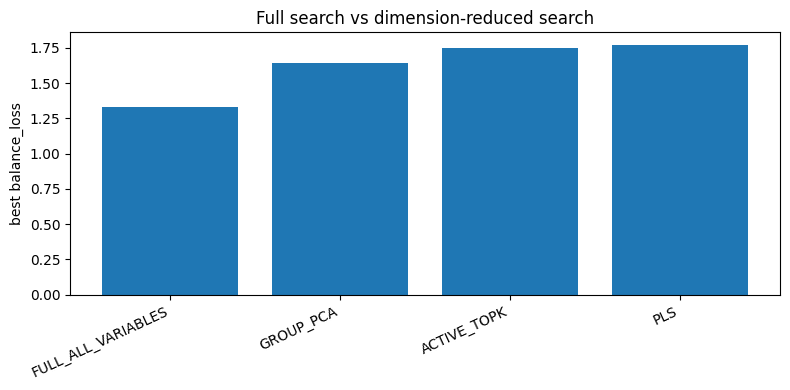

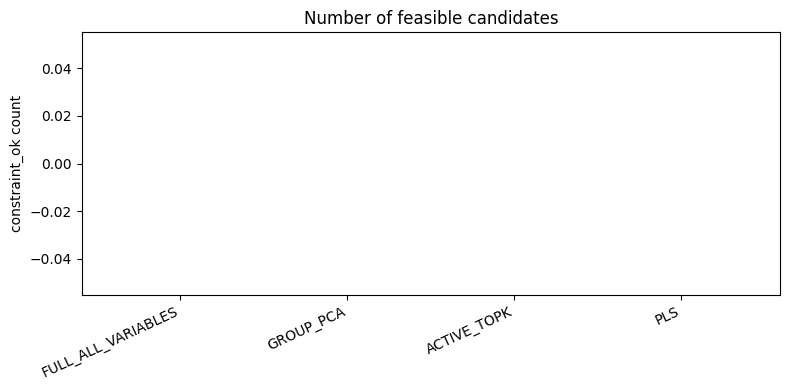

In [25]:
# ================================================================
# 22. FULL vs 차원압축 탐색 결과 비교
# ================================================================

def summarize_method(df, method_name):
    d = df.copy()
    if "constraint_ok" in d.columns and d["constraint_ok"].dtype == object:
        d["constraint_ok"] = d["constraint_ok"].astype(str).str.lower().isin(["true", "1", "yes"])
    d = d.sort_values("balance_loss", ascending=True)
    best = d.iloc[0]
    return {
        "method": method_name,
        "n": len(d),
        "constraint_ok_count": int(d["constraint_ok"].sum()) if "constraint_ok" in d.columns else 0,
        "best_loss": float(best.get("balance_loss", np.nan)),
        "best_constraint_ok": bool(best.get("constraint_ok", False)),
        "best_reach_d5": float(best.get("reach_d5", np.nan)),
        "best_reach_d10": float(best.get("reach_d10", np.nan)),
        "best_reach_d15": float(best.get("reach_d15", np.nan)),
        "best_reach_d20": float(best.get("reach_d20", np.nan)),
        "best_has_A": float(best.get("has_A", np.nan)),
        "best_has_S": float(best.get("has_S", np.nan)),
        "best_sink_ratio": float(best.get("sink_ratio", np.nan)),
        "best_p99_p50": float(best.get("p99_p50", np.nan)),
        "best_D20_ev_cost": float(best.get("D20_ev_cost", np.nan)),
        "best_late_15_20_share": float(best.get("late_15_20_share", np.nan)),
        "best_p99_reward_bonus": float(best.get("p99_reward_bonus", np.nan)),
        "best_p99_cost_reduce": float(best.get("p99_cost_reduce", np.nan)),
    }

# FULL은 stage1+stage2+stage3 전체 중 상위 결과를 의미한다.
full_summary_df = all_results.copy()

summary_rows = [summarize_method(full_summary_df, "FULL_ALL_VARIABLES")]
for name, df in [
    ("GROUP_PCA", globals().get("pca_res")),
    ("PLS", globals().get("pls_res")),
    ("ACTIVE_TOPK", globals().get("active_res")),
]:
    if isinstance(df, pd.DataFrame) and len(df):
        summary_rows.append(summarize_method(df, name))

comparison = pd.DataFrame(summary_rows).sort_values("best_loss", ascending=True).reset_index(drop=True)
comparison.to_csv(DIMRED_DIR/"full_vs_dimred_comparison_summary.csv", index=False, encoding="utf-8-sig")

display(comparison)

# 전체 후보 통합 랭킹
rank_frames = []
base_full = full_summary_df.copy()
base_full["method"] = "FULL_ALL_VARIABLES"
rank_frames.append(base_full)
for name, df in [("GROUP_PCA", globals().get("pca_res")), ("PLS", globals().get("pls_res")), ("ACTIVE_TOPK", globals().get("active_res"))]:
    if isinstance(df, pd.DataFrame) and len(df):
        tmp = df.copy()
        tmp["method"] = name
        rank_frames.append(tmp)

combined_methods = pd.concat(rank_frames, ignore_index=True, sort=False)
combined_methods = combined_methods.sort_values("balance_loss", ascending=True).reset_index(drop=True)
combined_methods.to_csv(DIMRED_DIR/"combined_full_dimred_ranked.csv", index=False, encoding="utf-8-sig")

display(combined_methods[["method", "theta_id", "balance_loss", "constraint_ok", "reach_d5", "reach_d10", "reach_d15", "reach_d20", "has_A", "sink_ratio", "p99_p50", "D20_ev_cost", "late_15_20_share"]].head(30))

if plt is not None:
    plt.figure(figsize=(8, 4))
    plt.bar(comparison["method"], comparison["best_loss"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("best balance_loss")
    plt.title("Full search vs dimension-reduced search")
    plt.tight_layout()
    plt.show()

    if "constraint_ok_count" in comparison.columns:
        plt.figure(figsize=(8, 4))
        plt.bar(comparison["method"], comparison["constraint_ok_count"])
        plt.xticks(rotation=25, ha="right")
        plt.ylabel("constraint_ok count")
        plt.title("Number of feasible candidates")
        plt.tight_layout()
        plt.show()

In [26]:
# ================================================================
# 23. 최종 후보 원래 파라미터로 복원 + 개발자 전달 파일 생성
# ================================================================

# 차원압축 후보든 전체변수 후보든, 최종 적용은 반드시 원래 파라미터 값으로 한다.
# build_code_params가 앞쪽에 정의되어 있으면 그대로 사용한다.

best_row = combined_methods.sort_values("balance_loss", ascending=True).iloc[0].copy()

print("BEST METHOD:", best_row.get("method"))
print("BEST theta_id:", best_row.get("theta_id"))
print("BEST loss:", best_row.get("balance_loss"))
print("BEST constraint_ok:", best_row.get("constraint_ok"))

# 최종 원 파라미터 저장
best_original_params = best_row[[c for c in PARAM_COLS if c in best_row.index]].to_frame("value")
best_original_params.to_csv(DIMRED_DIR/"FINAL_best_original_params_v36.csv", encoding="utf-8-sig")

# 코드 적용용 변환
if "build_code_params" in globals():
    code_params = build_code_params(best_row)
else:
    code_params = {c: float(best_row[c]) for c in PARAM_COLS if c in best_row.index}

final_payload = {
    "method": str(best_row.get("method")),
    "theta_id": int(best_row.get("theta_id", -1)) if not pd.isna(best_row.get("theta_id", np.nan)) else None,
    "constraint_ok": bool(best_row.get("constraint_ok", False)),
    "metrics": {c: (float(best_row[c]) if c in best_row.index and pd.notna(best_row[c]) else None) for c in METRIC_COLS if c in best_row.index},
    "raw_params": {c: (float(best_row[c]) if c in best_row.index and pd.notna(best_row[c]) else None) for c in PARAM_COLS},
    "code_params": code_params,
    "comparison_summary_file": str(DIMRED_DIR/"full_vs_dimred_comparison_summary.csv"),
}

with open(DIMRED_DIR/"FINAL_recommended_parameters_v36_dimred_compare.json", "w", encoding="utf-8") as f:
    json.dump(final_payload, f, ensure_ascii=False, indent=2)

# 간단 메시지 생성
msg = f"""
초능력자 봇 파라미터 v3.6 차원압축 비교 결과

[최종 선택]
- method: {final_payload['method']}
- theta_id: {final_payload['theta_id']}
- constraint_ok: {final_payload['constraint_ok']}
- balance_loss: {best_row.get('balance_loss')}
- D+5 도달률: {best_row.get('reach_d5')}
- D+10 도달률: {best_row.get('reach_d10')}
- D+15 도달률: {best_row.get('reach_d15')}
- D+20 도달률: {best_row.get('reach_d20')}
- A 이상 보유율: {best_row.get('has_A')}
- S 보유율: {best_row.get('has_S')}
- sink ratio: {best_row.get('sink_ratio')}
- P99/P50: {best_row.get('p99_p50')}
- D20 기대비용: {best_row.get('D20_ev_cost')}
- 15~20강 비용 집중도: {best_row.get('late_15_20_share')}
- P99 보상 보너스: {best_row.get('p99_reward_bonus')}
- P99 강화비용 감소율: {best_row.get('p99_cost_reduce')}

[비교 파일]
- full_vs_dimred_comparison_summary.csv
- combined_full_dimred_ranked.csv
- sensitivity_extra_trees_balance_loss.csv
- group_pca_loadings_*.csv
- pls_weights_balance_loss.csv

주의: PCA/PLS/Active는 탐색 보조 도구입니다. 개발 적용은 FINAL_recommended_parameters_v36_dimred_compare.json의 code_params 기준으로 진행하세요.
""".strip()

with open(DIMRED_DIR/"developer_message_v36_dimred_compare.txt", "w", encoding="utf-8") as f:
    f.write(msg)

print(msg)
print("saved:", DIMRED_DIR)

BEST METHOD: FULL_ALL_VARIABLES
BEST theta_id: 20013020
BEST loss: 1.3276845
BEST constraint_ok: False
초능력자 봇 파라미터 v3.6 차원압축 비교 결과

[최종 선택]
- method: FULL_ALL_VARIABLES
- theta_id: 20013020
- constraint_ok: False
- balance_loss: 1.3276845216751099
- D+5 도달률: 0.307120680809021
- D+10 도달률: 0.06867125630378723
- D+15 도달률: 0.0008189344662241638
- D+20 도달률: 0.0001304895558860153
- A 이상 보유율: 0.01579148694872856
- S 보유율: 0.0
- sink ratio: 0.37618809938430786
- P99/P50: 2.863105535507202
- D20 기대비용: 242967.71875
- 15~20강 비용 집중도: 0.698217511177063
- P99 보상 보너스: 0.01965072564780712
- P99 강화비용 감소율: 0.019802972674369812

[비교 파일]
- full_vs_dimred_comparison_summary.csv
- combined_full_dimred_ranked.csv
- sensitivity_extra_trees_balance_loss.csv
- group_pca_loadings_*.csv
- pls_weights_balance_loss.csv

주의: PCA/PLS/Active는 탐색 보조 도구입니다. 개발 적용은 FINAL_recommended_parameters_v36_dimred_compare.json의 code_params 기준으로 진행하세요.
saved: /content/chaoneung_param_lab_v35_battle_outputs/dimred_compare_v36


In [27]:
# ================================================================
# 24. 결과 ZIP 다운로드
# ================================================================

try:
    from google.colab import files
    import shutil, datetime

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    zip_base = Path(f"/content/chaoneung_v36_dimred_compare_{timestamp}")
    zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=str(DIMRED_DIR))
    print("ZIP 생성 완료:", zip_path)
    files.download(zip_path)
except Exception as e:
    print("Colab download skipped:", e)
    print("결과 폴더:", DIMRED_DIR)

ZIP 생성 완료: /content/chaoneung_v36_dimred_compare_20260505_013019.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ================================================================
# 15. 결과 ZIP 다운로드
# ================================================================

from google.colab import files
import shutil, datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
zip_base = Path(f"/content/chaoneung_v34_results_{timestamp}")
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=str(OUT_DIR))

print("ZIP 생성 완료:", zip_path)
print("포함 파일 수:", len(list(OUT_DIR.rglob("*"))))

files.download(zip_path)